First, we explore whether there are any correlations in the performance of the models we tested in the original ToM training project on any of the original datasets we had (non-neutralized).

So we explore all pairwise correlations between all ToM datasets and all Hu & Floyd datasets.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from os import listdir
import os
import numpy as np
import scipy
sns.set(style="ticks", font_scale=1.2)

In [4]:
sorted(listdir(os.path.join("../behavioral_eval_output", "original")))

['.DS_Store',
 'bigtom_backward',
 'bigtom_forward',
 'blimp',
 'emobench_application',
 'emobench_understanding_cause',
 'emobench_understanding_emotion',
 'entity_tracking',
 'epitome_fb',
 'epitome_rm',
 'epitome_si',
 'ewok_agent-properties',
 'ewok_social-interactions',
 'ewok_social-properties',
 'fauxpas_eai_q1_and_q4',
 'hufloyd_coherence',
 'hufloyd_deceits',
 'hufloyd_humour',
 'hufloyd_indirectspeech',
 'hufloyd_irony',
 'hufloyd_maxims',
 'hufloyd_metaphor',
 'imppres_implicature',
 'imppres_presupposition',
 'ludwig',
 'opentom_attitude',
 'opentom_location_cg_fo',
 'opentom_location_cg_fo_long',
 'opentom_location_cg_so',
 'opentom_location_cg_so_long',
 'opentom_location_fg_fo_new',
 'opentom_location_fg_so_new',
 'opentom_multihop_fo',
 'opentom_multihop_so',
 'pub_agreement',
 'pub_deictic_qa',
 'pub_indirectness_classification',
 'pub_indirectness_interpretation',
 'pub_sarcasm',
 'sarcv2',
 'simpletom_behavior',
 'snli',
 'social_iqa',
 'story_analogies',
 'tinytom-v

Code below is mostly ported over from the tom-training repo.

In [3]:
DATA_DIR = "../behavioral_eval_output"
DATASETS = sorted([f for f in listdir(os.path.join(DATA_DIR, "original")) if (f != ".DS_Store")])
print("datasets:", len(DATASETS))
DATASETS_PRAGMATICS = [d for d in DATASETS if ("hufloyd" in d) or ("epitome_si" in d) or (d == "ludwig") or ("imppres" in d) or ("pub" in d) or ("sarcv2" == d) and ("blimp" != d)]
DATASETS_SYNTAX = ["blimp", "snli"]
DATASETS_GENERAL = ["entity_tracking", "verbal_analogies", "story_analogies"]
DATASETS_TOM = [d for d in DATASETS if (d not in DATASETS_PRAGMATICS) and (d not in DATASETS_SYNTAX) and (d not in DATASETS_GENERAL)]


print("Num ToM datasets:", len(DATASETS_TOM))
print("Num Pragmatics datasets:", len(DATASETS_PRAGMATICS))
print("Num Syntax datasets:", len(DATASETS_SYNTAX))
print("Num General datasets:", len(DATASETS_GENERAL))

# MODELS = ["gpt2", "gpt2-medium", "gpt2-xl", "allenai/OLMo-1B-0724-hf", "allenai/OLMo-7B-0724-hf", "allenai/OLMo-2-1124-13B", "meta-llama/Llama-3.2-1B", "meta-llama/Llama-3.2-3B", "meta-llama/Llama-3.1-8B", "meta-llama/Llama-2-7b-hf", "meta-llama/Llama-2-7b-chat-hf", "EleutherAI/pythia-2.8b-deduped"]

MODEL_MAP = {
    "allenai/OLMo-1B-0724-hf": "OLMo-1B",
    "allenai/OLMo-7B-0724-hf": "OLMo-7B", 
    "allenai/OLMo-7B-0724-Instruct-hf": "OLMo-7B-0724-Instruct", 
    "allenai/OLMo-2-1124-13B": "OLMo-2-1124-13B", 
    "meta-llama/Llama-3.2-1B": "Llama-3.2-1B",
    "meta-llama/Llama-3.2-3B": "Llama-3.2-3B",
    "meta-llama/Llama-3.1-8B": "Llama-3.1-8B", 
    "meta-llama/Llama-3.1-8B-Instruct": "Llama-3.1-8B-Instruct",
    "meta-llama/Llama-3.1-70B": "Llama-3.1-70B",
    "meta-llama/Llama-3.3-70B-Instruct": "Llama-3.3-70B-Instruct",
    "meta-llama/Llama-2-7b-hf": "Llama-2-7b",
    "meta-llama/Llama-2-7b-chat-hf": "Llama-2-7b-chat",
    "meta-llama/Llama-2-13b-hf": "Llama-2-13b",
    "meta-llama/Llama-2-13b-chat-hf": "Llama-2-13b-chat",
    "meta-llama/Llama-2-70b-hf": "Llama-2-70b",
    "meta-llama/Llama-2-70b-chat-hf": "Llama-2-70b-chat",
    "EleutherAI/pythia-2.8b-deduped": "pythia-2.8b",
    "EleutherAI/pythia-1.4b-deduped": "pythia-1.4b",
    "EleutherAI/pythia-1b-deduped": "pythia-1b",
    "EleutherAI/pythia-6.9b-deduped": "pythia-6.9b",
    "EleutherAI/pythia-12b-deduped": "pythia-12b",
    "tiiuae/Falcon3-1B-Base":"Falcon3-1B",
    "tiiuae/Falcon3-1B-Instruct":"Falcon3-1B-Instruct",
    "tiiuae/Falcon3-3B-Base":"Falcon3-3B",
    "tiiuae/Falcon3-3B-Instruct":"Falcon3-3B-Instruct",
    "tiiuae/Falcon3-7B-Base":"Falcon3-7B",
    "tiiuae/Falcon3-7B-Instruct":"Falcon3-7B-Instruct",
    "tiiuae/Falcon3-10B-Base":"Falcon3-10B",
    "tiiuae/Falcon3-10B-Instruct":"Falcon3-10B-Instruct",
    # "google/gemma-3-1b-pt": "gemma-3-1b",
    # "google/gemma-3-1b-it": "gemma-3-1b-it",
    # "google/gemma-3-4b-pt": "gemma-3-4b",
    # "google/gemma-3-4b-it": "gemma-3-4b-it",
    # "google/gemma-3-270m": "gemma-3-270m",
    # "google/gemma-3-270m-it": "gemma-3-270m-it",
    # "google/gemma-3-12b-pt": "gemma-3-12b",
    # "google/gemma-3-12b-it": "gemma-3-12b-it",
    # "google/gemma-3-27b-pt": "gemma-3-27b",
    # "google/gemma-3-27b-it": "gemma-3-27b-it",
    "google/gemma-2-2b": "gemma-2-2b",
    "google/gemma-2-2b-it": "gemma-2-2b-it",
    "google/gemma-2-9b": "gemma-2-9b",
    "google/gemma-2-9b-it": "gemma-2-9b-it",
    "google/gemma-2-27b": "gemma-2-27b",
    "google/gemma-2-27b-it": "gemma-2-27b-it",
    "Qwen/Qwen2.5-0.5B": "Qwen2.5-0.5B",
    "Qwen/Qwen2.5-0.5B-Instruct": "Qwen2.5-0.5B-Instruct",
    "Qwen/Qwen2.5-1.5B": "Qwen2.5-1.5B",
    "Qwen/Qwen2.5-1.5B-Instruct": "Qwen2.5-1.5B-Instruct",
    "Qwen/Qwen2.5-3B": "Qwen2.5-3B",
    "Qwen/Qwen2.5-3B-Instruct": "Qwen2.5-3B-Instruct",
    "Qwen/Qwen2.5-7B": "Qwen2.5-7B",
    "Qwen/Qwen2.5-7B-Instruct": "Qwen2.5-7B-Instruct",
    "Qwen/Qwen2.5-14B": "Qwen2.5-14B",
    "Qwen/Qwen2.5-14B-Instruct": "Qwen2.5-14B-Instruct",
    "Qwen/Qwen2.5-32B": "Qwen2.5-32B",
    "Qwen/Qwen2.5-32B-Instruct": "Qwen2.5-32B-Instruct",
    "Qwen/Qwen2.5-72B": "Qwen2.5-72B",
    "Qwen/Qwen2.5-72B-Instruct": "Qwen2.5-72B-Instruct",
    "mistralai/Mistral-7B-Instruct-v0.3": "Mistral-7B-Instruct"
}

blues = sns.color_palette("Blues")
reds = sns.color_palette("Reds")
greens = sns.color_palette("Greens")
oranges = sns.color_palette("Oranges")
purples = sns.color_palette("Purples")
yellows = sns.color_palette("YlOrBr")
light_blues = sns.color_palette("light:b")

MODEL_PAL = {
    "allenai/OLMo-1B-0724-hf": oranges[0],
    "allenai/OLMo-7B-0724-hf": oranges[1],
    "allenai/OLMo-7B-0724-Instruct-hf": oranges[1],
    # "allenai/OLMo-2-1124-13B": oranges[2],

    "meta-llama/Llama-3.2-1B": greens[0],
    "meta-llama/Llama-3.2-3B": greens[1],
    # "meta-llama/Llama-3.2-3B-Instruct": greens[1],
    "meta-llama/Llama-2-7b-hf": greens[2],
    "meta-llama/Llama-2-7b-chat-hf": greens[2],
    "meta-llama/Llama-3.1-8B": greens[3],
    "meta-llama/Llama-3.1-8B-Instruct": greens[3],
    "meta-llama/Llama-2-13b-hf": greens[4],
    "meta-llama/Llama-2-13b-chat-hf": greens[4],
    "meta-llama/Llama-3.1-70B": greens[5],
    "meta-llama/Llama-3.3-70B-Instruct": greens[5],
    "meta-llama/Llama-2-70b-hf": greens[5],
    "meta-llama/Llama-2-70b-chat-hf": greens[5],

    "EleutherAI/pythia-1b-deduped": reds[0],
    "EleutherAI/pythia-1.4b-deduped": reds[1],
    "EleutherAI/pythia-2.8b-deduped": reds[2],
    "EleutherAI/pythia-6.9b-deduped": reds[3],
    "EleutherAI/pythia-12b-deduped": reds[4],

    "tiiuae/Falcon3-1B-Base": yellows[0],
    "tiiuae/Falcon3-1B-Instruct": yellows[0],
    "tiiuae/Falcon3-3B-Base": yellows[1],
    "tiiuae/Falcon3-3B-Instruct": yellows[1],
    "tiiuae/Falcon3-7B-Base": yellows[2],
    "tiiuae/Falcon3-7B-Instruct": yellows[2],
    "tiiuae/Falcon3-10B-Base": yellows[3],
    "tiiuae/Falcon3-10B-Instruct": yellows[3],

    "google/gemma-2-2b": purples[0],
    "google/gemma-2-9b": purples[1],
    "google/gemma-2-9b-it": purples[1],
    "google/gemma-2-27b": purples[2],
    "google/gemma-2-27b-it": purples[2],
    #"google/gemma-3-270m": purples[0],
    #"google/gemma-3-270m-it": purples[0],
    #"google/gemma-3-1b-pt": purples[1],
    #"google/gemma-3-1b-it": purples[1],
    #"google/gemma-3-4b-pt": purples[2],
    #"google/gemma-3-4b-it": purples[2],
    #"google/gemma-3-12b-pt": purples[3],
    #"google/gemma-3-12b-it": purples[3],
    #"google/gemma-3-27b-pt": purples[4],
    #"google/gemma-3-27b-it": purples[4],

    "Qwen/Qwen2.5-0.5B": blues[0],
    "Qwen/Qwen2.5-0.5B-Instruct": blues[0],
    "Qwen/Qwen2.5-1.5B": blues[0],
    "Qwen/Qwen2.5-1.5B-Instruct": blues[0],
    "Qwen/Qwen2.5-3B": blues[1],
    "Qwen/Qwen2.5-3B-Instruct": blues[1],
    "Qwen/Qwen2.5-7B": blues[2],
    "Qwen/Qwen2.5-7B-Instruct": blues[2],
    "Qwen/Qwen2.5-14B": blues[3],
    "Qwen/Qwen2.5-14B-Instruct": blues[3],
    "Qwen/Qwen2.5-32B": blues[4],
    "Qwen/Qwen2.5-32B-Instruct": blues[4],
    "Qwen/Qwen2.5-72B": blues[5],
    "Qwen/Qwen2.5-72B-Instruct": blues[5],
    
    "mistralai/Mistral-7B-Instruct-v0.3": light_blues[0]
}

datasets: 54
Num ToM datasets: 32
Num Pragmatics datasets: 17
Num Syntax datasets: 2
Num General datasets: 3


In [5]:
len(list(MODEL_PAL.keys()))

48

In [ ]:
def aggregate_over_items(df, id_col="qid"):
    print("======== num rows before aggregation: ===========", len(df))
    df_aggregated = df.groupby(["model", id_col]).apply(
        lambda r: 
        pd.DataFrame({
            "model_correct_mean_logprob": r["model_correct_mean_logprob"].all(),
            "model_correct_sum_logprob": r["model_correct_sum_logprob"].all()
        }, index=[0])                                                
    ).reset_index()[["model", id_col, "model_correct_mean_logprob", "model_correct_sum_logprob"]]
    print("======== num rows after aggregation: ===========", len(df_aggregated))
    return df_aggregated

def read_data(data_dir, datasets=DATASETS_TOM):
    results = {}
    for dataset in datasets:
        # NOTE: this is a hotfix due to error in the data
        if dataset == "pub_indirectness_interpretation":
            print("Skipping pun indirectness interpretation")
            continue
        cur_dir = Path(data_dir, dataset)
        print(cur_dir)
        if not cur_dir.exists():
            print(f"No data found ({cur_dir}); skipping...")
            continue
        dfs = []
        for f in listdir(Path(cur_dir)):
            if not any([m in f for m in list(MODEL_MAP.values())]):
                print(f"Uknown model in {f}")
                continue

            d = pd.read_csv(Path(cur_dir, f))

            dfs.append(d)
        df = pd.concat(dfs).reset_index()
        
        # handle datasets in long format, which need grouping by item ID
        # only correct prediction if all item-level pairwise predictions are correct (therefore, these tasks have a lower chance level performance)
        # these datasets are: opentom_attitude, pub_indirectness_interpretation, social_iqa, imppres_presupposition, imppres_implicature
        
        if (dataset == "opentom_attitude") or (dataset == "social_iqa") or (dataset.startswith("imppres")): 
            df = aggregate_over_items(df, id_col="id")
            df["chance"] = 1/3 
        # elif (dataset == "pub_indirectness_interpretation"): 
        #     df = aggregate_over_items(df, id_col="pretext")
        #     df["chance"] = 0.25 (in the corrected version: 1/6?)
        
        elif (dataset == "emobench_understanding_emotion"):
            df = aggregate_over_items(df, id_col="qid")
            df["chance"] = 1/6 


        elif (dataset.startswith("emobench")):
            df = aggregate_over_items(df, id_col="qid")
            df["chance"] = 1/5 

        # Process datasets with 2x2 scoring.
        elif dataset.startswith("ewok"):
            for metric in ["mean_logprob", "sum_logprob"]:
                if f"context1_correct_option_{metric}" in df.columns:
                    df[f"model_correct_{metric}"] = (
                        (df[f"context1_correct_option_{metric}"] > df[f"context2_incorrect_option_{metric}"]) & \
                        (df[f"context2_correct_option_{metric}"] > df[f"context1_incorrect_option_{metric}"])
                    )
                # See Section 4.1 of the EWOK paper about scoring criterion
                else:
                    df[f"model_correct_{metric}"] = (
                        (df[f"Context1_correct_option_{metric}"] > df[f"Context2_incorrect_option_{metric}"]) & \
                        (df[f"Context2_correct_option_{metric}"] > df[f"Context1_incorrect_option_{metric}"])
                    )
            df["chance"] = 0.25
        elif dataset.startswith("tinytom") or dataset.startswith("bigtom") or dataset == "epitome_fb":
            for metric in ["mean_logprob", "sum_logprob"]:
                df[f"model_correct_{metric}"] = (
                    (df[f"fb_correct_option_{metric}"] > df[f"tb_incorrect_option_{metric}"]) & \
                    (df[f"tb_correct_option_{metric}"] > df[f"fb_incorrect_option_{metric}"])
                )
            df["chance"] = 0.25
        elif (dataset == "fauxpas_eai_q1_and_q4"):
            # pivot to long format, so that q1_ and q4_ columns are separate rows and accuracy will be averaged across these two conditions
            fauxpas_q1 = df[[
                "id", "type", "story", 'question_1', 'correct_1', 'incorrect_1', 'q1_correct_option_mean_logprob', 'q1_incorrect_option_mean_logprob',
                'q1_model_correct_mean_logprob', 'q1_correct_option_sum_logprob',
                'q1_incorrect_option_sum_logprob', 'q1_model_correct_sum_logprob',
                'q1_scored_condition', 'model'
            ]].rename({
                'question_1': 'question', 
                'correct_1': 'correct', 
                'incorrect_1': 'incorrect', 
                'q1_correct_option_mean_logprob': 'correct_option_mean_logprob', 
                'q1_incorrect_option_mean_logprob': 'incorrect_option_mean_logprob',
                'q1_model_correct_mean_logprob': 'model_correct_mean_logprob', 
                'q1_correct_option_sum_logprob': 'correct_option_sum_logprob',
                'q1_incorrect_option_sum_logprob': 'incorrect_option_sum_logprob', 
                'q1_model_correct_sum_logprob': 'model_correct_sum_logprob',
                'q1_scored_condition': 'scored_condition'
            }, axis = 1)

            fauxpas_q4 = df[[
                "id", "type", "story", 'question_4', 'correct_4', 'incorrect_4', 'q4_correct_option_mean_logprob', 'q4_incorrect_option_mean_logprob',
                'q4_model_correct_mean_logprob', 'q4_correct_option_sum_logprob',
                'q4_incorrect_option_sum_logprob', 'q4_model_correct_sum_logprob',
                'q4_scored_condition', 'model'
            ]].rename({
                'question_4': 'question', 
                'correct_4': 'correct', 
                'incorrect_4': 'incorrect', 
                'q4_correct_option_mean_logprob': 'correct_option_mean_logprob', 
                'q4_incorrect_option_mean_logprob': 'incorrect_option_mean_logprob',
                'q4_model_correct_mean_logprob': 'model_correct_mean_logprob', 
                'q4_correct_option_sum_logprob': 'correct_option_sum_logprob',
                'q4_incorrect_option_sum_logprob': 'incorrect_option_sum_logprob', 
                'q4_model_correct_sum_logprob': 'model_correct_sum_logprob',
                'q4_scored_condition': 'scored_condition'
            }, axis = 1)

            df = pd.concat([fauxpas_q1, fauxpas_q4])
            df["chance"] = 0.5
        elif (dataset.startswith("entity_tracking")):
                df[f"model_correct_mean_logprob"] = (
                    (df[f"correct_option_mean_logprob"].astype(float) > df[f"incorrect_option_mean_logprob"].astype(float)) 
                )
                df[f"model_correct_sum_logprob"] = (
                    (df[f"correct_option_sum_logprob"].astype(float) > df[f"incorrect_option_sum_logprob"].astype(float)) 
                )
                df = aggregate_over_items(df, id_col="id")
                df["chance"] = 1/6
        elif (dataset.startswith("snli")):
            # assign qid by grouping by the pretext
            df["qid"] = df.groupby("pretext").ngroup()
            df[f"model_correct_mean_logprob"] = (
                (df[f"correct_option_mean_logprob"].astype(float) > df[f"incorrect_option_mean_logprob"].astype(float)) 
            )
            df[f"model_correct_sum_logprob"] = (
                (df[f"correct_option_sum_logprob"].astype(float) > df[f"incorrect_option_sum_logprob"].astype(float)) 
            )
            df = aggregate_over_items(df, id_col="qid")
            df["chance"] = 1/3
        else:
            df["chance"] = 0.5
        
        print(f"{dataset}: {len(df.index)} rows")

        df["dataset"] = dataset
        df["item_id"] = list(range(len(df)))
        results[dataset] = df

    return results

data_tom = read_data(data_dir="../behavioral_eval_output/original", datasets=DATASETS_TOM)
data_pragmatics = read_data(data_dir="../behavioral_eval_output/original", datasets=DATASETS_PRAGMATICS)

../behavioral_eval_output/original/bigtom_backward
Uknown model in gemma-3-27b-pt.csv
Uknown model in gemma-3-4b-it.csv
Uknown model in gemma-3-4b-pt.csv
Uknown model in gemma-3-270m-it.csv
Uknown model in gemma-3-27b-it.csv
Uknown model in gemma-3-12b-pt.csv
Uknown model in gemma-3-12b-it.csv
Uknown model in gemma-3-270m.csv
Uknown model in gemma-3-1b-pt.csv
Uknown model in gemma-3-1b-it.csv
bigtom_backward: 9552 rows
../behavioral_eval_output/original/bigtom_forward
Uknown model in gemma-3-27b-pt.csv
Uknown model in gemma-3-4b-it.csv
Uknown model in gemma-3-4b-pt.csv
Uknown model in gemma-3-270m-it.csv
Uknown model in gemma-3-27b-it.csv
Uknown model in .DS_Store
Uknown model in gemma-3-12b-pt.csv
Uknown model in gemma-3-12b-it.csv
Uknown model in gemma-3-270m.csv
Uknown model in gemma-3-1b-pt.csv
Uknown model in gemma-3-1b-it.csv
bigtom_forward: 9648 rows
../behavioral_eval_output/original/emobench_application
Uknown model in gemma-3-27b-pt.csv
Uknown model in gemma-3-4b-it.csv
Uknow

/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_39569/512311158.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_aggregated = df.groupby(["model", id_col]).apply(


======== num rows after aggregation: =========== 9600
emobench_application: 9600 rows
../behavioral_eval_output/original/emobench_understanding_cause
Uknown model in gemma-3-27b-pt.csv
Uknown model in gemma-3-4b-it.csv
Uknown model in gemma-3-4b-pt.csv
Uknown model in gemma-3-270m-it.csv
Uknown model in gemma-3-27b-it.csv
Uknown model in gemma-3-12b-pt.csv
Uknown model in gemma-3-12b-it.csv
Uknown model in gemma-3-270m.csv
Uknown model in gemma-3-1b-pt.csv
Uknown model in gemma-3-1b-it.csv
======== num rows before aggregation: =========== 28800


/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_39569/512311158.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_aggregated = df.groupby(["model", id_col]).apply(


======== num rows after aggregation: =========== 9600
emobench_understanding_cause: 9600 rows
../behavioral_eval_output/original/emobench_understanding_emotion
Uknown model in gemma-3-27b-pt.csv
Uknown model in gemma-3-4b-it.csv
Uknown model in gemma-3-4b-pt.csv
Uknown model in gemma-3-270m-it.csv
Uknown model in gemma-3-27b-it.csv
Uknown model in gemma-3-12b-pt.csv
Uknown model in gemma-3-12b-it.csv
Uknown model in gemma-3-270m.csv
Uknown model in gemma-3-1b-pt.csv
Uknown model in gemma-3-1b-it.csv
======== num rows before aggregation: =========== 48000


...

/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_39569/512311158.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_aggregated = df.groupby(["model", id_col]).apply(


======== num rows after aggregation: =========== 86400
imppres_presupposition: 86400 rows
../behavioral_eval_output/original/ludwig
Uknown model in gemma-3-27b-pt.csv
Uknown model in gemma-3-4b-it.csv
Uknown model in gemma-3-4b-pt.csv
Uknown model in gemma-3-270m-it.csv
Uknown model in gemma-3-27b-it.csv
Uknown model in .DS_Store
Uknown model in gemma-3-12b-pt.csv
Uknown model in gemma-3-12b-it.csv
Uknown model in gemma-3-270m.csv
Uknown model in gemma-3-1b-pt.csv
Uknown model in gemma-3-1b-it.csv
ludwig: 28800 rows
../behavioral_eval_output/original/pub_agreement
Uknown model in gemma-3-27b-pt.csv
Uknown model in gemma-3-4b-it.csv
Uknown model in gemma-3-4b-pt.csv
Uknown model in gemma-3-270m-it.csv
Uknown model in gemma-3-27b-it.csv
Uknown model in gemma-3-12b-pt.csv
Uknown model in gemma-3-12b-it.csv
Uknown model in gemma-3-270m.csv
Uknown model in gemma-3-1b-pt.csv
Uknown model in gemma-3-1b-it.csv
pub_agreement: 96000 rows
../behavioral_eval_output/original/pub_deictic_qa
Uknown m

/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_39569/512311158.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_aggregated = df.groupby(["model", id_col]).apply(


======== num rows after aggregation: =========== 14740
snli: 14740 rows
../behavioral_eval_output/original/entity_tracking
======== num rows before aggregation: =========== 74955
======== num rows after aggregation: =========== 12730
entity_tracking: 12730 rows
../behavioral_eval_output/original/verbal_analogies
verbal_analogies: 1600 rows
../behavioral_eval_output/original/story_analogies
story_analogies: 360 rows


/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_39569/512311158.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_aggregated = df.groupby(["model", id_col]).apply(


In [98]:
data_syntax = read_data(data_dir="../behavioral_eval_output/original", datasets=DATASETS_SYNTAX)
data_general = read_data(data_dir="../behavioral_eval_output/original", datasets=DATASETS_GENERAL)

../behavioral_eval_output/original/blimp
Uknown model in gemma-1.1-7b-it.csv
blimp: 32160 rows
../behavioral_eval_output/original/snli
======== num rows before aggregation: =========== 64320


/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_39569/512311158.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_aggregated = df.groupby(["model", id_col]).apply(


======== num rows after aggregation: =========== 32160
snli: 32160 rows
../behavioral_eval_output/original/entity_tracking
======== num rows before aggregation: =========== 74955
======== num rows after aggregation: =========== 12730
entity_tracking: 12730 rows
../behavioral_eval_output/original/verbal_analogies
verbal_analogies: 1600 rows
../behavioral_eval_output/original/story_analogies
story_analogies: 360 rows


/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_39569/512311158.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_aggregated = df.groupby(["model", id_col]).apply(


In [ ]:
data_tom_df = pd.concat([df[["item_id", "model", "dataset", "chance", "model_correct_mean_logprob", "model_correct_sum_logprob"]] for df in data_tom.values()]).reset_index().dropna()
data_pragmatics_df = pd.concat([df[["item_id", "model", "dataset", "chance", "model_correct_mean_logprob", "model_correct_sum_logprob"]] for df in data_pragmatics.values()]).reset_index().dropna()
# exclude models for which not all datasets were gathered: 
data_tom_df = data_tom_df[~data_tom_df["model"].isin(["allenai/OLMo-2-1124-13B"])]
data_pragmatics_df = data_pragmatics_df[~data_pragmatics_df["model"].isin(["allenai/OLMo-2-1124-13B"])]

In [99]:
data_syntax_df = pd.concat([df[["item_id", "model", "dataset", "chance", "model_correct_mean_logprob", "model_correct_sum_logprob"]] for df in data_syntax.values()]).reset_index().dropna()
data_general_df = pd.concat([df[["item_id", "model", "dataset", "chance", "model_correct_mean_logprob", "model_correct_sum_logprob"]] for df in data_general.values()]).reset_index().dropna()
data_syntax_df = data_syntax_df[~data_syntax_df["model"].isin(["allenai/OLMo-2-1124-13B"])]
data_general_df = data_general_df[~data_general_df["model"].isin(["allenai/OLMo-2-1124-13B"])]

In [ ]:
data_tom_df["model_type"] = data_tom_df["model"].apply(lambda s: "instruct" if ("instruct" in s.lower()) or ("chat" in s.lower()) or ("-it" in s.lower()) else "base")
data_pragmatics_df["model_type"] = data_pragmatics_df["model"].apply(lambda s: "instruct" if ("instruct" in s.lower()) or ("chat" in s.lower()) or ("-it" in s.lower()) else "base")

In [100]:
data_syntax_df["model_type"] = data_syntax_df["model"].apply(lambda s: "instruct" if ("instruct" in s.lower()) or ("chat" in s.lower()) or ("-it" in s.lower()) else "base")
data_general_df["model_type"] = data_general_df["model"].apply(lambda s: "instruct" if ("instruct" in s.lower()) or ("chat" in s.lower()) or ("-it" in s.lower()) else "base")

In [101]:
data_syntax_summary = data_syntax_df.groupby(["model", "model_type", "dataset"]).agg({"model_correct_mean_logprob": "mean", "model_correct_sum_logprob": "mean", "chance": "mean"}).reset_index()
data_general_summary = data_general_df.groupby(["model", "model_type", "dataset"]).agg({"model_correct_mean_logprob": "mean", "model_correct_sum_logprob": "mean", "chance": "mean"}).reset_index()


In [ ]:
data_tom_df["dataset"].unique()
data_syntax_df["model_correct"] = data_syntax_df["model_correct_mean_logprob"].astype(int)
len(data_syntax_df)
# data_syntax_df.to_csv("syntax_model_accuracy_wSNLI.csv", index=False)

In [97]:
data_syntax_df.value_counts(["dataset", "model"])

dataset  model                           
blimp    EleutherAI/pythia-1.4b-deduped      670
snli     Qwen/Qwen2.5-32B-Instruct           670
         allenai/OLMo-7B-0724-hf             670
         allenai/OLMo-7B-0724-Instruct-hf    670
         allenai/OLMo-1B-0724-hf             670
                                            ... 
blimp    meta-llama/Llama-2-70b-chat-hf      670
         meta-llama/Llama-2-13b-hf           670
         meta-llama/Llama-2-13b-chat-hf      670
         google/gemma-2-9b-it                670
snli     tiiuae/Falcon3-7B-Instruct          670
Name: count, Length: 95, dtype: int64

In [86]:
# explore the accuracies per model & per dataset
def plot_accuracy(data, metric="mean_logprob", dataset_list=DATASETS_TOM, pretty_names=None):
    model_order = [m for m in MODEL_PAL.keys() if m in data["model"].unique()]
    print(model_order)
    g = sns.catplot(
        data=data, 
        x="model",
        y=f"model_correct_{metric}",
        # order=model_order, 
        hue="model",
        order=MODEL_PAL.keys(),
        hue_order=MODEL_PAL.keys(),
        palette=MODEL_PAL,
        col="dataset",
        col_wrap=2,
        kind="bar",
        height=5, # 5 for pragmatics plots, 5.5 for tom
        aspect=2.5, # 2.5 for pragmatics plots, 2.2 for tom
        err_kws={"lw": 1}
    )
    g.set_titles("{col_name}")
    # g.set_yticklabels(fontsize=20)
    g.set_xticklabels([MODEL_MAP[m] for m in model_order], rotation=90, fontsize=20) # MODEL_MAP.values() , ha="right" [MODEL_MAP[m] for m in MODELS]
    g.set_ylabels("")
    g.set_xlabels("")
    plt.subplots_adjust(wspace=0.2) # for pragmatics plots
#     g.fig.subplots_adjust(
#     hspace=0.1,   # ⬅️ vertical spacing (reduce)
#     wspace=0.1,    # ⬅️ horizontal spacing (reduce)
#     bottom=0.15    # ⬅️ give room for rotated labels
# )
    line_styles = {
        "base": (0, ()),          # solid
        "instruct": (0, (5, 5))      # dashed
    }

    # Ensure data includes "model_type"
    if "model_type" not in data.columns:
        raise ValueError("Data must include a 'model_type' column")

    # # Loop through facets
    # for ax in g.axes.flat:
    for j, ax in enumerate(g.axes.flat):
        for i, bar in enumerate(ax.patches): # for bar, model_name in zip(ax.patches, data_all_pd["model"].unique()):
            # Get the model_type for this model
            model_name = model_order[i % len(model_order)]    # cycle through hue order
            # Get the model_type for this model
            model_type = data.loc[data["model"] == model_name, "model_type"].iloc[0]
            ls = line_styles.get(model_type, (0, ()))  # default solid
            bar.set_edgecolor("black")
            bar.set_linewidth(1.5)
            bar.set_linestyle(ls)
    # for i, ax in enumerate(g.axes):
    #     for bar, model_name in zip(ax.patches, data["model"].unique()):
    #         # Get the model_type for this model
    #         model_type = data.loc[data["model"] == model_name, "model_type"].iloc[0]
    #         print(model_name, model_type)
    #         ls = line_styles.get(model_type, (0, ()))  # default solid
    #         bar.set_edgecolor("black")
    #         bar.set_linewidth(1.5)
    #         bar.set_linestyle(ls)

        if dataset_list[j] == "pub_indirectness_interpretation":
            continue
        chance = data[data["dataset"] == dataset_list[j]]["chance"].tolist()[0] 
        ax.axhline(chance, linestyle="--", color="k", alpha=0.5)
        ax.tick_params(axis="y", labelsize=20)

    if pretty_names is not None:
        for ax, dataset in zip(g.axes.flat, g.col_names):
            ax.set_title(pretty_names.get(dataset, dataset), fontsize=28)
    g.fig.supylabel(f"Accuracy ({metric.replace('_', ' ')})", x=0.01, fontsize=28)

    # g.set_ylabels(..., fontsize=14)

    plt.tight_layout()

In [12]:
len(DATASETS_PRAGMATICS)

17

/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_84618/1683432549.py:18: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


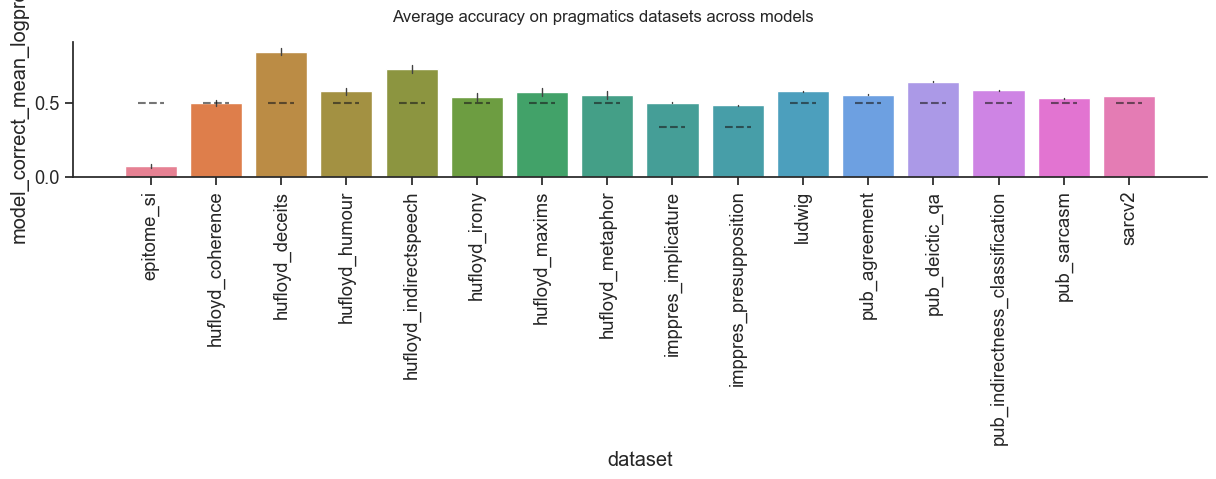

In [9]:
g_prag_byDataset = sns.catplot(
    data=data_pragmatics_df, 
    x="dataset",
    y=f"model_correct_mean_logprob",
    hue="dataset",
    kind="bar",
    height=2.5,
    aspect=5,
    err_kws={"lw": 1}
)
ax = g_prag_byDataset.axes[0, 0]
# Rotate x ticks
g_prag_byDataset.set_xticklabels(rotation=90)
# Add a descriptive title
g_prag_byDataset.fig.suptitle("Average accuracy on pragmatics datasets across models", fontsize=12)

# Adjust layout so the title doesn't overlap
plt.tight_layout()
plt.subplots_adjust(top=0.85)
# Add individual chance lines for each bar
x_coords = [p.get_x() + p.get_width() / 2 for p in ax.patches]
datasets = data_pragmatics_df["dataset"].unique()

for x, dataset in zip(x_coords, datasets):
    chance = data_pragmatics_df[data_pragmatics_df["dataset"] == dataset]["chance"].iloc[0]
    # draw a short horizontal line across the width of one bar
    ax.hlines(y=chance, xmin=x - 0.2, xmax=x + 0.2, colors="k", linestyles="--", alpha=0.6)
    # ax.text(x, chance, f"{chance:.2f}", ha="center", va="bottom", fontsize=8, color="gray")

plt.show()

/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_84618/3033250481.py:18: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


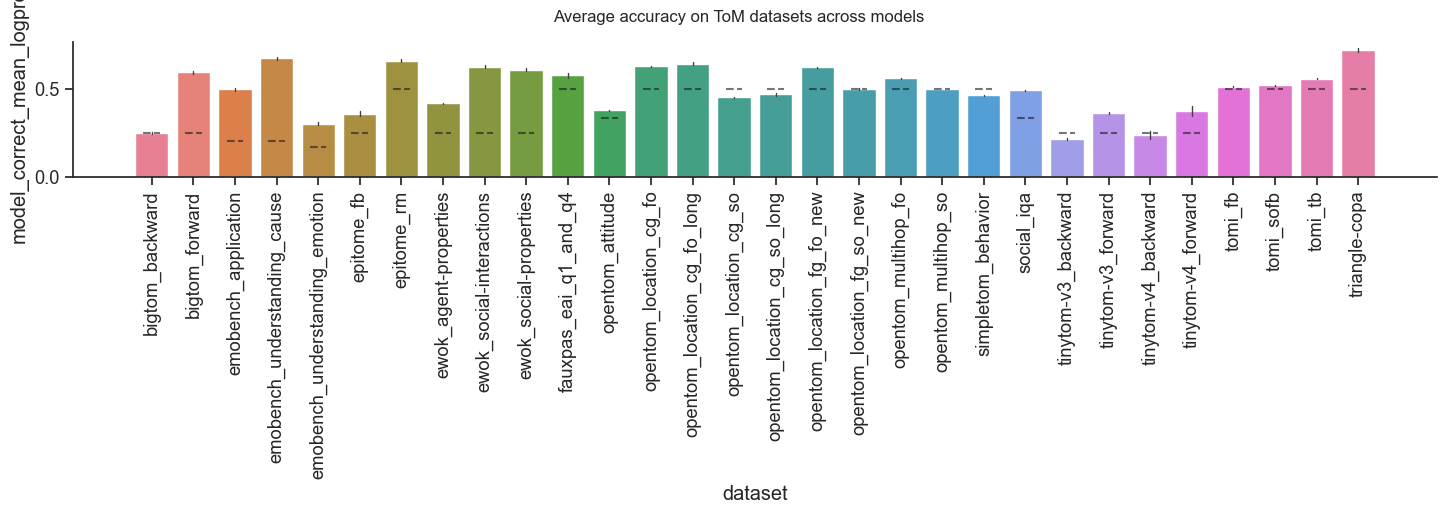

In [10]:
g_tom_byDataset = sns.catplot(
    data=data_tom_df, 
    x="dataset",
    y=f"model_correct_mean_logprob",
    hue="dataset",
    kind="bar",
    height=2.5,
    aspect=6,
    err_kws={"lw": 1}
)
ax = g_tom_byDataset.axes[0, 0]
# Rotate x ticks
g_tom_byDataset.set_xticklabels(rotation=90)
# Add a descriptive title
g_tom_byDataset.fig.suptitle("Average accuracy on ToM datasets across models", fontsize=12)

# Adjust layout so the title doesn't overlap
plt.tight_layout()
plt.subplots_adjust(top=0.85)
# Add individual chance lines for each bar
x_coords = [p.get_x() + p.get_width() / 2 for p in ax.patches]
datasets = data_tom_df["dataset"].unique()

for x, dataset in zip(x_coords, datasets):
    chance = data_tom_df[data_tom_df["dataset"] == dataset]["chance"].iloc[0]
    # draw a short horizontal line across the width of one bar
    ax.hlines(y=chance, xmin=x - 0.2, xmax=x + 0.2, colors="k", linestyles="--", alpha=0.6)
    
plt.show()

In [13]:
data_all_pd = pd.concat([data_pragmatics_df, data_tom_df]).reset_index()

/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_84618/2205142988.py:20: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


allenai/OLMo-1B-0724-hf base
allenai/OLMo-7B-0724-hf base
allenai/OLMo-7B-0724-Instruct-hf instruct
meta-llama/Llama-3.2-1B base
meta-llama/Llama-3.2-3B base
meta-llama/Llama-2-7b-hf base
meta-llama/Llama-2-7b-chat-hf instruct
meta-llama/Llama-3.1-8B base
meta-llama/Llama-3.1-8B-Instruct instruct
meta-llama/Llama-2-13b-hf base
meta-llama/Llama-2-13b-chat-hf instruct
meta-llama/Llama-3.1-70B base
meta-llama/Llama-3.3-70B-Instruct instruct
meta-llama/Llama-2-70b-hf base
meta-llama/Llama-2-70b-chat-hf instruct
EleutherAI/pythia-1b-deduped base
EleutherAI/pythia-1.4b-deduped base
EleutherAI/pythia-2.8b-deduped base
EleutherAI/pythia-6.9b-deduped base
EleutherAI/pythia-12b-deduped base
tiiuae/Falcon3-1B-Base base
tiiuae/Falcon3-1B-Instruct instruct
tiiuae/Falcon3-3B-Base base
tiiuae/Falcon3-3B-Instruct instruct
tiiuae/Falcon3-7B-Base base
tiiuae/Falcon3-7B-Instruct instruct
tiiuae/Falcon3-10B-Base base
tiiuae/Falcon3-10B-Instruct instruct
google/gemma-3-270m base
google/gemma-3-270m-it inst

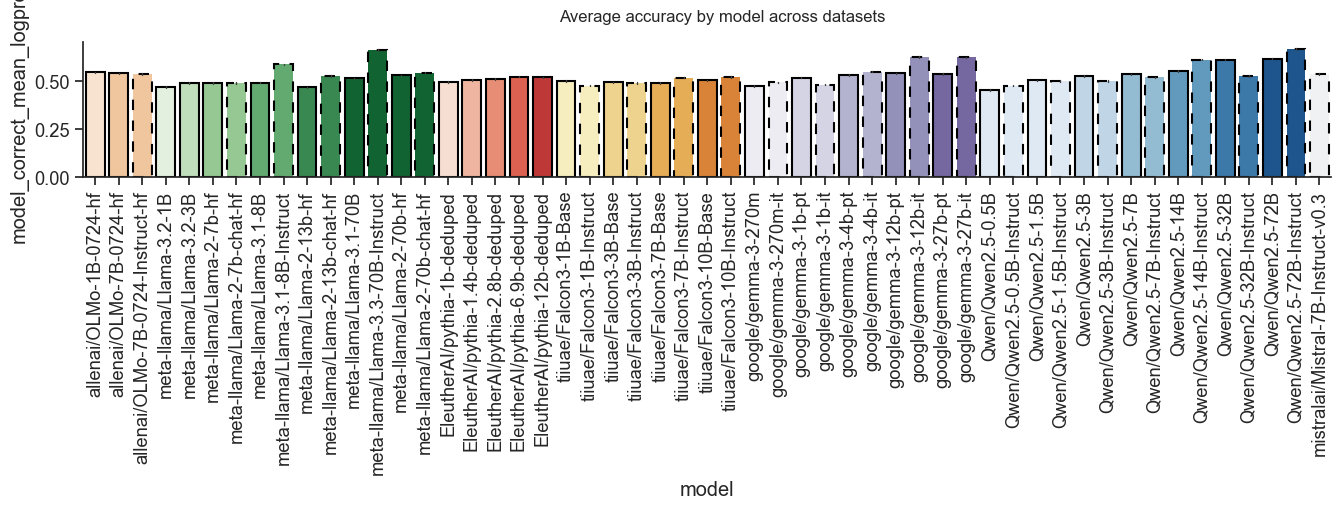

In [15]:
# average over models
g_byModel = sns.catplot(
    data=data_all_pd, 
    x="model",
    y=f"model_correct_mean_logprob",
    hue="model",
    kind="bar",
    height=2.5,
    aspect=6,
    order=MODEL_PAL.keys(),
    hue_order=MODEL_PAL.keys(),
    palette=MODEL_PAL,
    err_kws={"lw": 1}
)
# Rotate x ticks
g_byModel.set_xticklabels(rotation=90)

g_byModel.fig.suptitle("Average accuracy by model across datasets", fontsize=12)

plt.tight_layout()
plt.subplots_adjust(top=0.85)
line_styles = {
    "base": (0, ()),          # solid
    "instruct": (0, (5, 5))      # dashed
}

# Ensure data includes "model_type"
if "model_type" not in data_all_pd.columns:
    raise ValueError("Data must include a 'model_type' column")

# Loop through facets
model_order = list(MODEL_PAL.keys())
for ax in g_byModel.axes.flat:
    for i, bar in enumerate(ax.patches): # for bar, model_name in zip(ax.patches, data_all_pd["model"].unique()):
        # Get the model_type for this model
        model_name = model_order[i % len(model_order)]    # cycle through hue order
        model_type = data_all_pd.loc[data_all_pd["model"] == model_name, "model_type"].iloc[0]
        ls = line_styles.get(model_type, (0, ()))  # default solid
        bar.set_edgecolor("black")
        bar.set_linewidth(1.5)
        bar.set_linestyle(ls)

plt.show()

/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_84618/1994447405.py:20: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


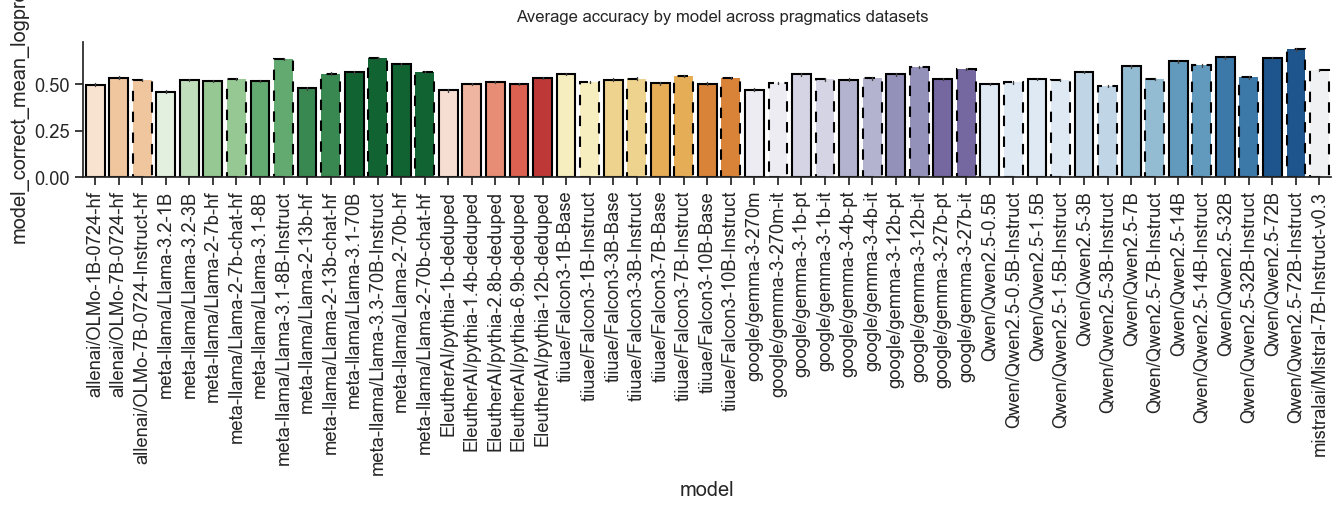

In [16]:
# average over models
g_prag_byModel = sns.catplot(
    data=data_pragmatics_df, 
    x="model",
    y=f"model_correct_mean_logprob",
    hue="model",
    kind="bar",
    height=2.5,
    aspect=6,
    order=MODEL_PAL.keys(),
    hue_order=MODEL_PAL.keys(),
    palette=MODEL_PAL,
    err_kws={"lw": 1}
)
# Rotate x ticks
g_prag_byModel.set_xticklabels(rotation=90)

g_prag_byModel.fig.suptitle("Average accuracy by model across pragmatics datasets", fontsize=12)

plt.tight_layout()
plt.subplots_adjust(top=0.85)
# Ensure data includes "model_type"
if "model_type" not in data_all_pd.columns:
    raise ValueError("Data must include a 'model_type' column")

# Loop through facets
for ax in g_prag_byModel.axes.flat:
    for i, bar in enumerate(ax.patches): # for bar, model_name in zip(ax.patches, data_all_pd["model"].unique()):
        # Get the model_type for this model
        model_name = model_order[i % len(model_order)]    # cycle through hue order
        # Get the model_type for this model
        model_type = data_pragmatics_df.loc[data_pragmatics_df["model"] == model_name, "model_type"].iloc[0]
        ls = line_styles.get(model_type, (0, ()))  # default solid
        bar.set_edgecolor("black")
        bar.set_linewidth(1.5)
        bar.set_linestyle(ls)

plt.show()

/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_84618/4255096707.py:20: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


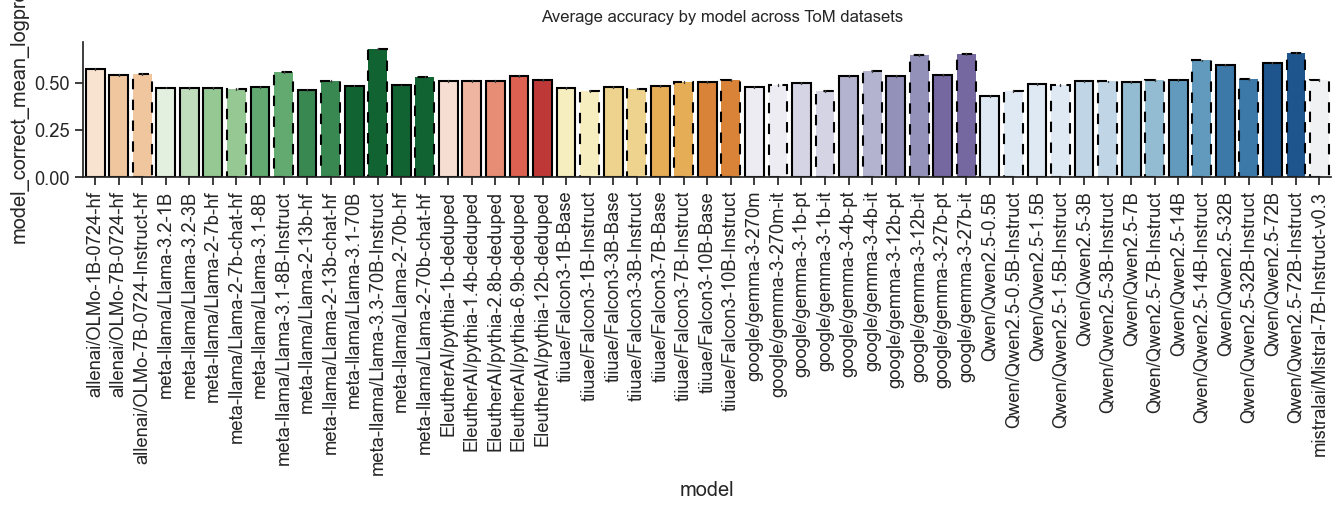

In [17]:
# average over models
g_tom_byModel = sns.catplot(
    data=data_tom_df, 
    x="model",
    y=f"model_correct_mean_logprob",
    hue="model",
    kind="bar",
    height=2.5,
    aspect=6,
    order=MODEL_PAL.keys(),
    hue_order=MODEL_PAL.keys(),
    palette=MODEL_PAL,
    err_kws={"lw": 1}
)
# Rotate x ticks
g_tom_byModel.set_xticklabels(rotation=90)

g_tom_byModel.fig.suptitle("Average accuracy by model across ToM datasets", fontsize=12)

plt.tight_layout()
plt.subplots_adjust(top=0.85)
# Loop through facets
for ax in g_tom_byModel.axes.flat:
    for i, bar in enumerate(ax.patches): # for bar, model_name in zip(ax.patches, data_all_pd["model"].unique()):
        # Get the model_type for this model
        model_name = model_order[i % len(model_order)]    # cycle through hue order
        # Get the model_type for this model
        model_type = data_tom_df.loc[data_tom_df["model"] == model_name, "model_type"].iloc[0]
        ls = line_styles.get(model_type, (0, ()))  # default solid
        bar.set_edgecolor("black")
        bar.set_linewidth(1.5)
        bar.set_linestyle(ls)


plt.show()

In [103]:
data_syntax_summary = data_syntax_df.groupby(["model", "model_type"]).agg({"model_correct_mean_logprob": "mean"}).reset_index()
data_syntax_summary
data_summary_synt = pd.merge(
    data_pragmatics_summary,
    # data_tom_summary,
    data_syntax_summary,
    on=["model", "model_type"],
    how="inner",
    suffixes=["_pragmatics", "_syntax"]
).reset_index()
data_summary_synt

,index,model,model_type,model_correct_mean_logprob_pragmatics,model_correct_mean_logprob_syntax
0,0,EleutherAI/pythia-1.4b-deduped,base,0.500510,0.571642
1,1,EleutherAI/pythia-12b-deduped,base,0.531823,0.576119
2,2,EleutherAI/pythia-1b-deduped,base,0.465907,0.567164
3,3,EleutherAI/pythia-2.8b-deduped,base,0.510422,0.573881
4,4,EleutherAI/pythia-6.9b-deduped,base,0.500093,0.576866
5,5,Qwen/Qwen2.5-0.5B,base,0.500695,0.694776
6,6,Qwen/Qwen2.5-0.5B-Instruct,instruct,0.509496,0.642537
7,7,Qwen/Qwen2.5-1.5B,base,0.526265,0.720149
8,8,Qwen/Qwen2.5-1.5B-Instruct,instruct,0.520984,0.705224
9,9,Qwen/Qwen2.5-14B,base,0.622522,0.709701


In [104]:
# print the models with best performance on pragmatics
data_pragmatics_summary = data_pragmatics_df.groupby(["model", "model_type"]).agg({"model_correct_mean_logprob": "mean"})
print(data_pragmatics_summary.sort_values(by="model_correct_mean_logprob", ascending=False)[:7])

# print the models with best performance on ToM
data_tom_summary = data_tom_df.groupby(["model", "model_type"]).agg({"model_correct_mean_logprob": "mean"})
print(data_tom_summary.sort_values(by="model_correct_mean_logprob", ascending=False)[:7])

                                              model_correct_mean_logprob
model                             model_type                            
Qwen/Qwen2.5-72B-Instruct         instruct                      0.686909
Qwen/Qwen2.5-32B                  base                          0.643506
Qwen/Qwen2.5-72B                  base                          0.641051
meta-llama/Llama-3.3-70B-Instruct instruct                      0.638596
meta-llama/Llama-3.1-8B-Instruct  instruct                      0.634427
Qwen/Qwen2.5-14B                  base                          0.622522
meta-llama/Llama-2-70b-hf         base                          0.605846
                                             model_correct_mean_logprob
model                             model_type                           
meta-llama/Llama-3.3-70B-Instruct instruct                     0.676512
Qwen/Qwen2.5-72B-Instruct         instruct                     0.655964
google/gemma-2-27b-it             instruct             

In [105]:
# get models with highest performance on both
data_summary = pd.merge(
    data_pragmatics_summary,
    data_tom_summary,
    on=["model", "model_type"],
    how="inner",
    suffixes=["_pragmatics", "_tom"]
).reset_index()
data_summary["avg_acc"] = data_summary[["model_correct_mean_logprob_tom", "model_correct_mean_logprob_pragmatics"]].mean(axis=1)

data_summary["model_correct_mean_logprob_pragmatics"] = pd.to_numeric(
    data_summary["model_correct_mean_logprob_pragmatics"], errors="coerce"
)
data_summary["model_correct_mean_logprob_tom"] = pd.to_numeric(
    data_summary["model_correct_mean_logprob_tom"], errors="coerce"
)
data_summary = data_summary.dropna(subset=[
    "model_correct_mean_logprob_pragmatics",
    "model_correct_mean_logprob_tom"
])

data_summary.sort_values(by=["avg_acc"], ascending=False)[:7]

,model,model_type,model_correct_mean_logprob_pragmatics,model_correct_mean_logprob_tom,avg_acc
16,Qwen/Qwen2.5-72B-Instruct,instruct,0.686909,0.655964,0.671437
38,meta-llama/Llama-3.3-70B-Instruct,instruct,0.638596,0.676512,0.657554
15,Qwen/Qwen2.5-72B,base,0.641051,0.600845,0.620948
11,Qwen/Qwen2.5-32B,base,0.643506,0.595430,0.619468
23,google/gemma-2-27b-it,instruct,0.602928,0.626509,0.614718
10,Qwen/Qwen2.5-14B-Instruct,instruct,0.600380,0.618388,0.609384
35,meta-llama/Llama-3.1-8B-Instruct,instruct,0.634427,0.560220,0.597323


In [106]:
data_summary_filtered = data_summary[~data_summary["model"].str.startswith("google/gemma-3")]
len(data_summary_filtered["model"].unique())

48

In [107]:
data_all_dict = {}
data_all_summary = data_all_pd.groupby(["model", "model_type", "dataset"]).agg({"model_correct_mean_logprob": "mean", "chance": "mean"}).reset_index()
data_all_summary

,model,model_type,dataset,model_correct_mean_logprob,chance
0,EleutherAI/pythia-1.4b-deduped,base,bigtom_backward,0.190955,0.250000
1,EleutherAI/pythia-1.4b-deduped,base,bigtom_forward,0.38806,0.250000
2,EleutherAI/pythia-1.4b-deduped,base,emobench_application,0.295,0.200000
3,EleutherAI/pythia-1.4b-deduped,base,emobench_understanding_cause,0.36,0.200000
4,EleutherAI/pythia-1.4b-deduped,base,emobench_understanding_emotion,0.145,0.166667
...,...,...,...,...,...
2255,tiiuae/Falcon3-7B-Instruct,instruct,tomi_fb,0.496154,0.500000
2256,tiiuae/Falcon3-7B-Instruct,instruct,tomi_sapEtAl_first_order,0.785484,0.500000
2257,tiiuae/Falcon3-7B-Instruct,instruct,tomi_sofb,0.502089,0.500000
2258,tiiuae/Falcon3-7B-Instruct,instruct,tomi_tb,0.537708,0.500000


In [108]:
data_all_summary["is_above_chance"] = data_all_summary["model_correct_mean_logprob"] > data_all_summary["chance"]
data_all_summary_above_chance = data_all_summary[data_all_summary["is_above_chance"] == True]

In [328]:
big_models_selection =[
    "meta-llama/Llama-3.1-8B", 
    "meta-llama/Llama-3.1-8B-Instruct", 
    "meta-llama/Llama-2-13b-hf",
    "meta-llama/Llama-2-13b-chat-hf",
    "meta-llama/Llama-3.1-70B",
    "meta-llama/Llama-3.3-70B-Instruct",
    "tiiuae/Falcon3-7B-Base",
    "tiiuae/Falcon3-7B-Instruct",
    "tiiuae/Falcon3-10B-Base",
    "tiiuae/Falcon3-10B-Instruct",
    "Qwen/Qwen2.5-7B",
    "Qwen/Qwen2.5-7B-Instruct",
    "Qwen/Qwen2.5-32B",
    "Qwen/Qwen2.5-32B-Instruct",
    "Qwen/Qwen2.5-72B",
    "Qwen/Qwen2.5-72B-Instruct",
    "google/gemma-2-9b-it",
    "google/gemma-2-9b",
    "google/gemma-2-27b-it",
    "google/gemma-2-27b"
]
data_all_summary_above_chance_selected_models = data_all_summary_above_chance[data_all_summary_above_chance["model"].isin(big_models_selection)]
data_all_summary_above_chance_selected_models

,model,model_type,dataset,model_correct_mean_logprob,chance,is_above_chance
506,Qwen/Qwen2.5-32B,base,bigtom_backward,0.311558,0.250000,True
507,Qwen/Qwen2.5-32B,base,bigtom_forward,0.641791,0.250000,True
508,Qwen/Qwen2.5-32B,base,emobench_application,0.5,0.200000,True
509,Qwen/Qwen2.5-32B,base,emobench_understanding_cause,0.795,0.200000,True
510,Qwen/Qwen2.5-32B,base,emobench_understanding_emotion,0.45,0.166667,True
...,...,...,...,...,...,...
2439,tiiuae/Falcon3-7B-Instruct,instruct,tinytom-v3_forward,0.382582,0.250000,True
2441,tiiuae/Falcon3-7B-Instruct,instruct,tinytom-v4_forward,0.45,0.250000,True
2443,tiiuae/Falcon3-7B-Instruct,instruct,tomi_sofb,0.502089,0.500000,True
2444,tiiuae/Falcon3-7B-Instruct,instruct,tomi_tb,0.537708,0.500000,True


In [365]:
# most datasets: more than 10 models are above chance on them
print(data_all_summary_above_chance_selected_models.value_counts("dataset").reset_index()["count"].tolist())
data_all_summary_above_chance_selected_models.value_counts("dataset").reset_index()

[16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 15, 15, 15, 15, 15, 15, 15, 14, 14, 14, 14, 14, 13, 13, 13, 13, 12, 12, 12, 12, 12, 11, 8, 8, 8, 7, 7, 6, 4, 3, 3, 3, 2, 1, 1]


,dataset,count
0,triangle-copa,16
1,ewok_agent-properties,16
2,hufloyd_indirectspeech,16
3,hufloyd_deceits,16
4,bigtom_forward,16
5,ewok_social-properties,16
6,ewok_social-interactions,16
7,social_iqa,16
8,epitome_rm,16
9,emobench_understanding_cause,16


In [109]:
# selected datasets: 
selected_datasets = [
    "tomi_sapEtAl_first_order", 
    "pub_agreement",
    "pub_indirectness_classification", 
    "fauxpas_eai_q1_and_q4",
    "ludwig",
    "opentom_attitude", # the only tom_desires dataset
    "hufloyd_irony",
    "imppres_presupposition",
    # "opentom_location_cg_fo",
    "pub_sarcasm",
    "pub_deictic_qa", # the only prag_discourse dataset
    "hufloyd_maxims",
    "hufloyd_metaphor",
    "imppres_implicature",
    "emobench_understanding_emotion",
    "triangle-copa",
    "ewok_agent-properties",
    "hufloyd_indirectspeech",
    "hufloyd_deceits",
    "bigtom_forward",
    "ewok_social-interactions",
    "social_iqa",
    "epitome_rm",
    "emobench_application"
]
len(selected_datasets)

23

In [339]:
atoms_dimensions = pd.read_csv("../behavioral_eval_stimuli/atoms_coarse_annotations.csv")
atoms_dimensions = atoms_dimensions.rename({"Dataset": "dataset"}, axis=1)
atoms_dimensions

,dataset,Domain,tom_belief,tom_intentions,tom_desires,tom_emotions,tom_knowledge,tom_perception,tom_nonliteral-communication,prag_reasoning_interlocutor,prag_type,prag_meaning_dim,prag_social_conventions,prag_intonation,prag_causal_inferences,prag_discourse
0,epitome_rm,ToM,yes,no,no,no,no,no,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,epitome_fb,ToM,yes,no,no,no,no,no,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,social_iqa,ToM,no,yes,no,yes,no,no,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,simpletom_behavior,ToM,no,yes,no,no,no,no,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ewok_agent-properties,ToM,yes,no,no,no,yes,yes,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,ewok_social-properties,ToM,no,no,no,yes,no,no,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,ewok_social-interactions,ToM,no,yes,no,yes,no,no,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,bigtom_forward,ToM,yes,no,no,no,no,yes,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,bigtom_backward,ToM,yes,no,no,no,no,yes,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,tinytom-v3_forward,ToM,yes,no,no,no,no,yes,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [340]:
data_all_summary_above_chance_selected_models_annotated = pd.merge(
    data_all_summary_above_chance_selected_models,
    atoms_dimensions,
    on="dataset",
    how="left"
)
data_all_summary_above_chance_selected_models_annotated

,model,model_type,dataset,model_correct_mean_logprob,chance,is_above_chance,Domain,tom_belief,tom_intentions,tom_desires,...,tom_knowledge,tom_perception,tom_nonliteral-communication,prag_reasoning_interlocutor,prag_type,prag_meaning_dim,prag_social_conventions,prag_intonation,prag_causal_inferences,prag_discourse
0,Qwen/Qwen2.5-32B,base,bigtom_backward,0.311558,0.250000,True,ToM,yes,no,no,...,no,yes,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Qwen/Qwen2.5-32B,base,bigtom_forward,0.641791,0.250000,True,ToM,yes,no,no,...,no,yes,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Qwen/Qwen2.5-32B,base,emobench_application,0.5,0.200000,True,ToM,yes,no,no,...,no,no,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Qwen/Qwen2.5-32B,base,emobench_understanding_cause,0.795,0.200000,True,ToM,yes,no,no,...,no,no,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Qwen/Qwen2.5-32B,base,emobench_understanding_emotion,0.45,0.166667,True,ToM,yes,no,no,...,no,no,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
546,tiiuae/Falcon3-7B-Instruct,instruct,tinytom-v3_forward,0.382582,0.250000,True,ToM,yes,no,no,...,no,yes,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN
547,tiiuae/Falcon3-7B-Instruct,instruct,tinytom-v4_forward,0.45,0.250000,True,ToM,yes,no,no,...,no,yes,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN
548,tiiuae/Falcon3-7B-Instruct,instruct,tomi_sofb,0.502089,0.500000,True,ToM,yes,no,no,...,no,no,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN
549,tiiuae/Falcon3-7B-Instruct,instruct,tomi_tb,0.537708,0.500000,True,ToM,yes,no,no,...,no,no,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [357]:
# note: for all ToM dimensions, at least some models are above chance
# for prag_meaning_dim, only one model above chance, for rest more; also other dimensions are covered in the results at least by some models
data_all_summary_above_chance_selected_models_annotated["prag_discourse"].value_counts()
all_dimensions = [c for c in atoms_dimensions.columns if (c != "dataset") and (c != "Domain")]
all_dimensions

['tom_belief',
 'tom_intentions',
 'tom_desires',
 'tom_emotions',
 'tom_knowledge',
 'tom_perception',
 'tom_nonliteral-communication',
 'prag_reasoning_interlocutor',
 'prag_type',
 'prag_meaning_dim',
 'prag_social_conventions',
 'prag_intonation',
 'prag_causal_inferences',
 'prag_discourse']

In [376]:

for model in data_all_summary_above_chance_selected_models_annotated["model"].unique():
    df_model = data_all_summary_above_chance_selected_models_annotated[data_all_summary_above_chance_selected_models_annotated["model"] == model]
    df_model = df_model[df_model["dataset"].isin(selected_datasets)]
    datasets_covered = df_model["dataset"].tolist()
    covered_dimensions = set()
    for dim in all_dimensions:
        if len(df_model[df_model[dim]=="yes"]) > 0:
            covered_dimensions.add(dim)
    data_all_dict[model] = {
        "datasets": datasets_covered,
        # "missing_tom_dimensions": list(set(all_dimensions) - covered_dimensions)
    }
    print(f"Model: {model}, Num datasets: {len(datasets_covered)}")

Model: Qwen/Qwen2.5-32B, Num datasets: 22
Model: Qwen/Qwen2.5-32B-Instruct, Num datasets: 18
Model: Qwen/Qwen2.5-72B, Num datasets: 22
Model: Qwen/Qwen2.5-72B-Instruct, Num datasets: 22
Model: Qwen/Qwen2.5-7B, Num datasets: 20
Model: Qwen/Qwen2.5-7B-Instruct, Num datasets: 18
Model: meta-llama/Llama-2-13b-chat-hf, Num datasets: 19
Model: meta-llama/Llama-2-13b-hf, Num datasets: 19
Model: meta-llama/Llama-3.1-70B, Num datasets: 19
Model: meta-llama/Llama-3.1-8B, Num datasets: 22
Model: meta-llama/Llama-3.1-8B-Instruct, Num datasets: 21
Model: meta-llama/Llama-3.3-70B-Instruct, Num datasets: 22
Model: tiiuae/Falcon3-10B-Base, Num datasets: 22
Model: tiiuae/Falcon3-10B-Instruct, Num datasets: 20
Model: tiiuae/Falcon3-7B-Base, Num datasets: 22
Model: tiiuae/Falcon3-7B-Instruct, Num datasets: 19


In [377]:
data_all_dict

{'Qwen/Qwen2.5-32B': {'datasets': ['bigtom_forward',
   'emobench_application',
   'emobench_understanding_emotion',
   'epitome_rm',
   'ewok_agent-properties',
   'ewok_social-interactions',
   'fauxpas_eai_q1_and_q4',
   'hufloyd_deceits',
   'hufloyd_indirectspeech',
   'hufloyd_irony',
   'hufloyd_maxims',
   'hufloyd_metaphor',
   'imppres_implicature',
   'imppres_presupposition',
   'ludwig',
   'opentom_attitude',
   'pub_agreement',
   'pub_deictic_qa',
   'pub_indirectness_classification',
   'pub_sarcasm',
   'social_iqa',
   'triangle-copa']},
 'Qwen/Qwen2.5-32B-Instruct': {'datasets': ['bigtom_forward',
   'emobench_application',
   'emobench_understanding_emotion',
   'epitome_rm',
   'ewok_agent-properties',
   'ewok_social-interactions',
   'fauxpas_eai_q1_and_q4',
   'hufloyd_deceits',
   'hufloyd_indirectspeech',
   'hufloyd_irony',
   'hufloyd_maxims',
   'hufloyd_metaphor',
   'imppres_implicature',
   'imppres_presupposition',
   'ludwig',
   'pub_deictic_qa',
   

In [ ]:
import json
# with open("models_selected_datasets_covered_above_chance.json", "w") as f:
    # json.dump(data_all_dict, f, indent=4)

In [ ]:
# data_summary.to_csv("model_behavioral_performance_summary.csv", index=False)

In [110]:
data_summary_filtered["model_family"] = data_summary_filtered["model"].apply(lambda s: s.split("/")[1].split("-")[0])
data_summary_filtered["model_family"] = data_summary_filtered["model"].apply(lambda s: s.split("/")[1].split("-")[0])

MODEL_PAL_FAMILY = {
    "OLMo": oranges[3],
    # "allenai/OLMo-2-1124-13B": oranges[2],
    "Llama": greens[3],
    "pythia": reds[3],
    "Falcon3": yellows[3],
    "gemma": purples[3],
    "Qwen2.5": blues[3],    
    "Mistral": light_blues[3]
}
data_summary_filtered

,model,model_type,model_correct_mean_logprob_pragmatics,model_correct_mean_logprob_tom,avg_acc,model_family
0,EleutherAI/pythia-1.4b-deduped,base,0.500510,0.508659,0.504584,pythia
1,EleutherAI/pythia-12b-deduped,base,0.531823,0.511101,0.521462,pythia
2,EleutherAI/pythia-1b-deduped,base,0.465907,0.509078,0.487492,pythia
3,EleutherAI/pythia-2.8b-deduped,base,0.510422,0.509917,0.51017,pythia
4,EleutherAI/pythia-6.9b-deduped,base,0.500093,0.535596,0.517844,pythia
5,Qwen/Qwen2.5-0.5B,base,0.500695,0.430066,0.46538,Qwen2.5
6,Qwen/Qwen2.5-0.5B-Instruct,instruct,0.509496,0.457415,0.483456,Qwen2.5
7,Qwen/Qwen2.5-1.5B,base,0.526265,0.491884,0.509074,Qwen2.5
8,Qwen/Qwen2.5-1.5B-Instruct,instruct,0.520984,0.488982,0.504983,Qwen2.5
9,Qwen/Qwen2.5-14B,base,0.622522,0.519093,0.570807,Qwen2.5


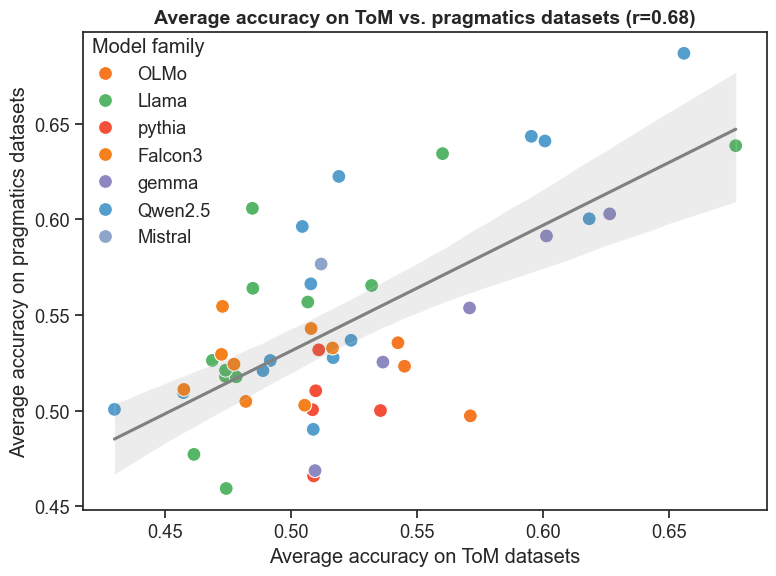

In [547]:
plt.figure(figsize=(8, 6))

g_prag_vs_tom = sns.scatterplot(
    data=data_summary_filtered, 
    x="model_correct_mean_logprob_tom", 
    y="model_correct_mean_logprob_pragmatics", 
    hue="model_family",
    hue_order=MODEL_PAL_FAMILY.keys(),
    palette=MODEL_PAL_FAMILY,
    s=100
)

# Add regression line
sns.regplot(
    data=data_summary_filtered, 
    x="model_correct_mean_logprob_tom", 
    y="model_correct_mean_logprob_pragmatics", 
    scatter=False, 
    ax=g_prag_vs_tom,
    color="gray"
)
# add correlation coefficient to title
corr = data_summary_filtered["model_correct_mean_logprob_tom"].corr(data_summary_filtered["model_correct_mean_logprob_pragmatics"])

# Move legend outside the main plot
sns.move_legend(
    g_prag_vs_tom,
    "center left",
    bbox_to_anchor=(-0.02, 0.77),  # (x, y) offset relative to axes
    frameon=False,
    title="Model family"
)

# Add title and adjust layout
# g_prag_vs_tom.set_title("Average accuracy on pragmatics vs. ToM datasets", fontsize=14, weight="bold")
g_prag_vs_tom.set_title(f"Average accuracy on ToM vs. pragmatics datasets (r={corr:.2f})", fontsize=14, weight="bold")
plt.xlabel("Average accuracy on ToM datasets")
plt.ylabel("Average accuracy on pragmatics datasets")
# plt.ylim(0, 1)
# plt.xlim(0, 1)
plt.tight_layout()  # leaves space for legend on the right
plt.show()


In [23]:
scipy.stats.pearsonr(data_summary["model_correct_mean_logprob_pragmatics"], data_summary["model_correct_mean_logprob_tom"])

PearsonRResult(statistic=0.6537034345849743, pvalue=1.113935848533658e-07)

In [476]:
scipy.stats.pearsonr(data_summary_filtered["model_correct_mean_logprob_tom"], data_summary_filtered["model_correct_mean_logprob_pragmatics"])

PearsonRResult(statistic=0.6774471156096954, pvalue=1.2358527385312556e-07)

In [22]:
data_summary["size"] = data_summary["model"].apply(lambda s: [i for i in s.split("-") if (len(i) < 5 and ("b" in i.lower() or "m" in i.lower()) and i[0].isdigit())][0])

def transform_m_to_b(size_str):
    if "m" in size_str.lower():
        return str(float(size_str.replace("m", "").replace("M", "")) / 1000)
    else:
        return size_str

data_summary["size_num"] = data_summary["size"].apply(lambda s: float(transform_m_to_b(s).replace("b", "").replace("B", "").replace("m", "")) if s else 0)
data_summary

,model,model_type,model_correct_mean_logprob_pragmatics,model_correct_mean_logprob_tom,avg_acc,size,size_num
0,EleutherAI/pythia-1.4b-deduped,base,0.500510,0.508659,0.504584,1.4b,1.4
1,EleutherAI/pythia-12b-deduped,base,0.531823,0.511101,0.521462,12b,12.0
2,EleutherAI/pythia-1b-deduped,base,0.465907,0.509078,0.487492,1b,1.0
3,EleutherAI/pythia-2.8b-deduped,base,0.510422,0.509917,0.51017,2.8b,2.8
4,EleutherAI/pythia-6.9b-deduped,base,0.500093,0.535596,0.517844,6.9b,6.9
5,Qwen/Qwen2.5-0.5B,base,0.500695,0.430066,0.46538,0.5B,0.5
6,Qwen/Qwen2.5-0.5B-Instruct,instruct,0.509496,0.457415,0.483456,0.5B,0.5
7,Qwen/Qwen2.5-1.5B,base,0.526265,0.491884,0.509074,1.5B,1.5
8,Qwen/Qwen2.5-1.5B-Instruct,instruct,0.520984,0.488982,0.504983,1.5B,1.5
9,Qwen/Qwen2.5-14B,base,0.622522,0.519093,0.570807,14B,14.0


In [ ]:
# data_summary.to_csv("model_size_mapping.csv", index=False)

In [55]:
# correlate size and average accuracy
print(scipy.stats.pearsonr(data_summary["size_num"], data_summary["avg_acc"]))
print(scipy.stats.pearsonr(data_summary["size_num"], data_summary["model_correct_mean_logprob_pragmatics"]))
print(scipy.stats.pearsonr(data_summary["size_num"], data_summary["model_correct_mean_logprob_tom"]))

PearsonRResult(statistic=0.621312613115732, pvalue=6.89087512784261e-07)
PearsonRResult(statistic=0.647652341953168, pvalue=1.591553876725222e-07)
PearsonRResult(statistic=0.4911934133524634, pvalue=0.00018799346529116146)


In [23]:
# calculate average accuracy and std of accuracy per size

avg_acc_bySize = (
    data_summary
    .groupby("size_num")
    .agg({
        "avg_acc": ["mean", "std"],
        "model_correct_mean_logprob_pragmatics": ["mean", "std"],
        "model_correct_mean_logprob_tom": ["mean", "std"],
        "model": "count"
    })
    .reset_index()
)
avg_acc_bySize.columns = [
    "size_num",
    "avg_acc_mean", "avg_acc_std",
    "pragmatics_mean", "pragmatics_std",
    "tom_mean", "tom_std",
    "count"
]
avg_acc_bySize = avg_acc_bySize.fillna(0)
avg_acc_bySize

/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_39569/2622875483.py:21: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  avg_acc_bySize = avg_acc_bySize.fillna(0)


,size_num,avg_acc_mean,avg_acc_std,pragmatics_mean,pragmatics_std,tom_mean,tom_std,count
0,0.5,0.474418,0.012781,0.505095,0.006223,0.443740,0.019339,2
1,1.0,0.497349,0.026590,0.497647,0.038396,0.497052,0.045551,5
2,1.4,0.504584,0.000000,0.500510,0.000000,0.508659,0.000000,1
3,1.5,0.507029,0.002893,0.523624,0.003734,0.490433,0.002052,2
4,2.0,0.489161,0.000000,0.468686,0.000000,0.509635,0.000000,1
5,2.8,0.510170,0.000000,0.510422,0.000000,0.509917,0.000000,1
6,3.0,0.507260,0.016763,0.526311,0.027115,0.488210,0.018567,5
7,6.9,0.517844,0.000000,0.500093,0.000000,0.535596,0.000000,1
8,7.0,0.522560,0.021908,0.539075,0.029334,0.506045,0.027347,9
9,8.0,0.547682,0.070203,0.576084,0.082509,0.519281,0.057897,2


In [24]:
data_summary_long = pd.melt(
    data_summary,
    id_vars=["model", "model_type", "size", "size_num"],
    value_vars=["model_correct_mean_logprob_pragmatics", "model_correct_mean_logprob_tom"],
    var_name="dataset_type",
    value_name="accuracy"
)
data_summary_long["dataset_type"] = data_summary_long["dataset_type"].apply(lambda s: s.replace("model_correct_mean_logprob_", ""))

avg_acc_bySize_long = pd.melt(
    avg_acc_bySize,
    id_vars=["size_num", "count"],
    value_vars=["pragmatics_mean", "tom_mean"],
    var_name="dataset_type",
    value_name="accuracy_mean"
)
avg_acc_bySize_long["dataset_type"] = avg_acc_bySize_long["dataset_type"].apply(lambda s: s.replace("_mean", ""))

In [111]:
data_summary_filtered["size"] = data_summary_filtered["model"].apply(lambda s: [i for i in s.split("-") if (len(i) < 5 and ("b" in i.lower() or "m" in i.lower()) and i[0].isdigit())][0])

# align with data_syntax_summary
data_summary_filtered = pd.merge(
    data_summary_filtered,
    data_syntax_summary[["model", "model_correct_mean_logprob"]].rename({"model_correct_mean_logprob": "model_correct_mean_logprob_syntax"}, axis=1),
    on="model",
    how="inner"
)

def transform_m_to_b(size_str):
    if "m" in size_str.lower():
        return str(float(size_str.replace("m", "").replace("M", "")) / 1000)
    else:
        return size_str

data_summary_filtered["size_num"] = data_summary_filtered["size"].apply(lambda s: float(transform_m_to_b(s).replace("b", "").replace("B", "").replace("m", "")) if s else 0)
print(data_summary_filtered.head())

data_summary_filtered_long = pd.melt(
    data_summary_filtered,
    id_vars=["model", "model_type", "size", "size_num", "model_family"],
    value_vars=["model_correct_mean_logprob_pragmatics", "model_correct_mean_logprob_tom", "model_correct_mean_logprob_syntax"],
    var_name="dataset_type",
    value_name="accuracy"
)
data_summary_filtered_long["dataset_type"] = data_summary_filtered_long["dataset_type"].apply(lambda s: s.replace("model_correct_mean_logprob_", ""))


                            model model_type  \
0  EleutherAI/pythia-1.4b-deduped       base   
1   EleutherAI/pythia-12b-deduped       base   
2    EleutherAI/pythia-1b-deduped       base   
3  EleutherAI/pythia-2.8b-deduped       base   
4  EleutherAI/pythia-6.9b-deduped       base   

   model_correct_mean_logprob_pragmatics  model_correct_mean_logprob_tom  \
0                               0.500510                        0.508659   
1                               0.531823                        0.511101   
2                               0.465907                        0.509078   
3                               0.510422                        0.509917   
4                               0.500093                        0.535596   

    avg_acc model_family  size  model_correct_mean_logprob_syntax  size_num  
0  0.504584       pythia  1.4b                           0.571642       1.4  
1  0.521462       pythia   12b                           0.576119      12.0  
2  0.487492       py

['pragmatics', 'tom', 'syntax']


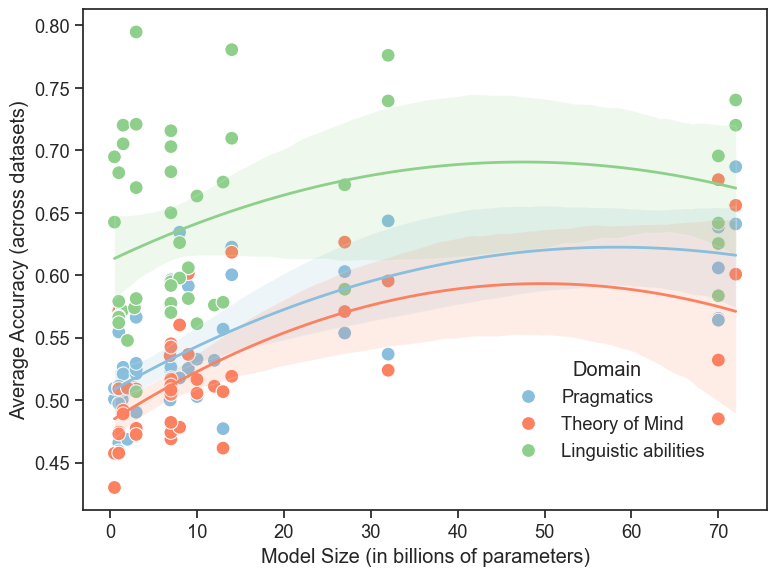

In [115]:
plt.figure(figsize=(8, 6))
data_summary_filtered_woSyntax = data_summary_filtered_long[data_summary_filtered_long["dataset_type"] != "syntax"]
# scatter
g_acc_bySize = sns.scatterplot(
    data=data_summary_filtered_long,#data_summary_filtered_woSyntax,
    x="size_num",
    y="accuracy",
    hue="dataset_type",
    hue_order=["pragmatics", "tom", "syntax"],
    palette={
        "pragmatics": blues[2],
        "tom": reds[2],
        "syntax": greens[2],
    },
    s=100
)

# regression lines (one per dataset_type)
for dataset, color in zip(
    ["pragmatics", "tom", "syntax"],
    [blues[2], reds[2], greens[2]]
):
    sns.regplot(
        data=data_summary_filtered_long.query("dataset_type == @dataset"), # data_summary_filtered_woSyntax
        ax = g_acc_bySize,
        x="size_num",
        y="accuracy",
        scatter=False,      # critical: do not duplicate points
        ci=95,              # or None if you don’t want uncertainty bands
        color=color,
        line_kws={"linewidth": 2},
        order=2
    )
handles, labels = g_acc_bySize.get_legend_handles_labels()
print(labels)
label_map = {
    "pragmatics": "Pragmatics",
    "tom": "Theory of Mind",
    "syntax": "Linguistic abilities"
}

new_labels = [label_map.get(l, l) for l in labels]

g_acc_bySize.legend(handles=handles, labels=new_labels, title="Domain")

sns.move_legend(
    g_acc_bySize,
    "center left",
    bbox_to_anchor=(0.6, 0.2),  # (x, y) offset relative to axes
    frameon=False,
    title="Domain"
)
plt.xlabel("Model Size (in billions of parameters)")
plt.ylabel("Average Accuracy (across datasets)")
plt.tight_layout()

/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_84618/3500435802.py:40: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(rect=[0, 0, 0.85, 1])  # leaves space for legend on the right


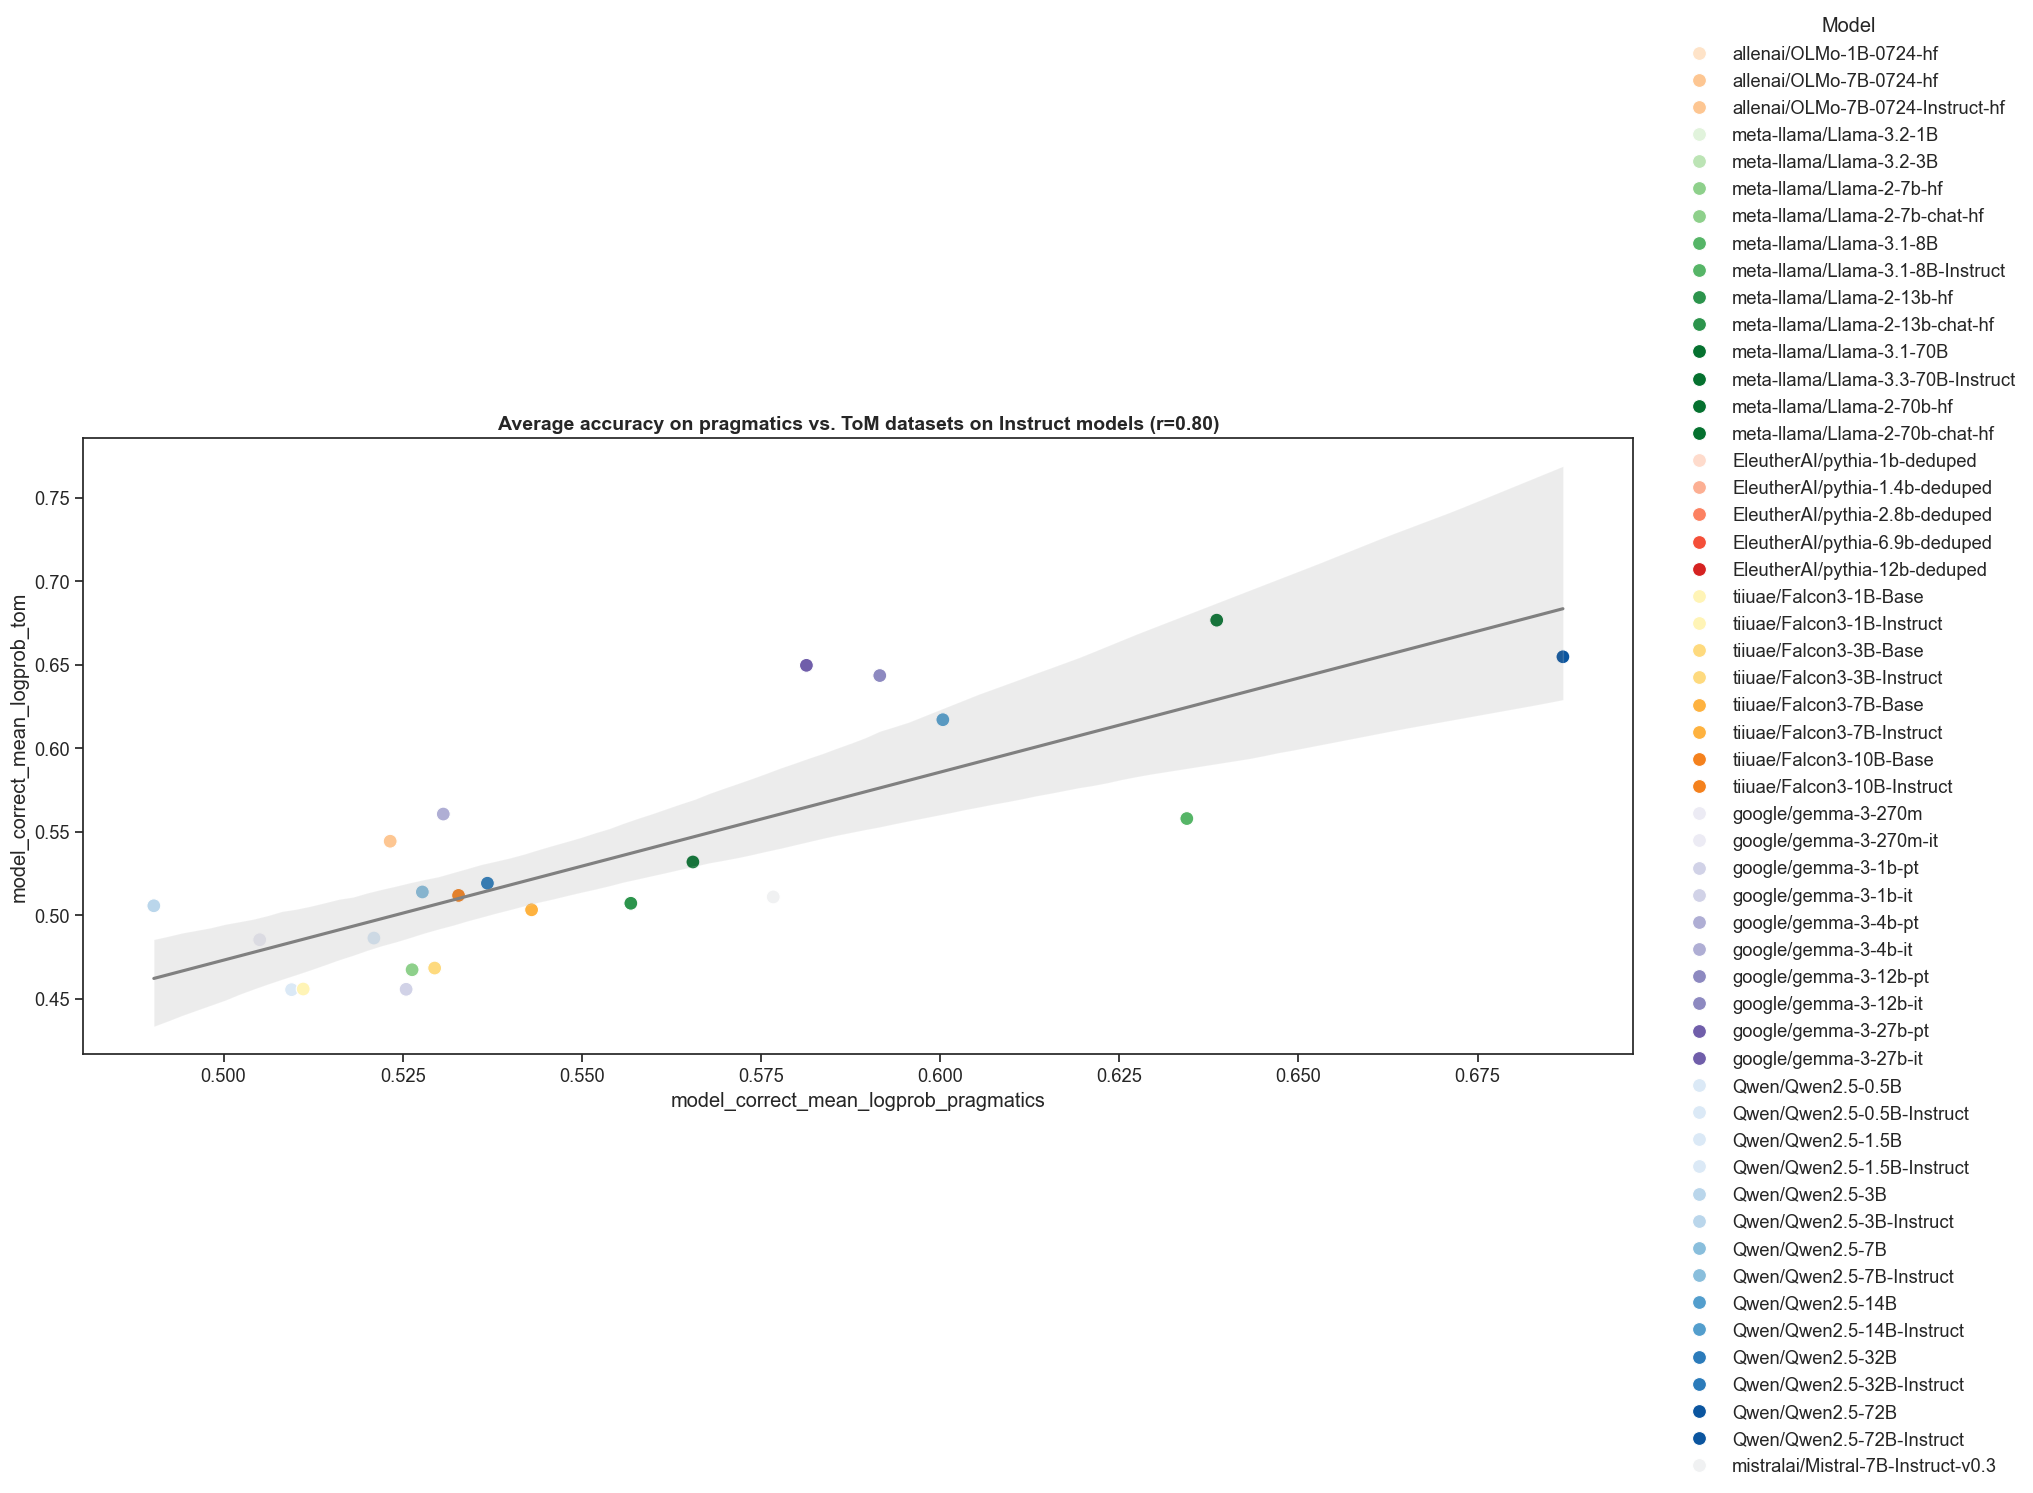

In [21]:
# only on instruct models
instruct_summary = data_summary[data_summary["model_type"] == "instruct"]
plt.figure(figsize=(20, 8))

g_prag_vs_tom_instruct = sns.scatterplot(
    data=instruct_summary, 
    x="model_correct_mean_logprob_pragmatics", 
    y="model_correct_mean_logprob_tom", 
    hue="model",
    hue_order=MODEL_PAL.keys(),
    palette=MODEL_PAL,
    s=100
)

# Add regression line
sns.regplot(
    data=instruct_summary, 
    x="model_correct_mean_logprob_pragmatics", 
    y="model_correct_mean_logprob_tom", 
    scatter=False, 
    ax=g_prag_vs_tom_instruct,
    color="gray"
)
# add correlation coefficient to title
corr = instruct_summary["model_correct_mean_logprob_pragmatics"].corr(instruct_summary["model_correct_mean_logprob_tom"])

# Move legend outside the main plot
sns.move_legend(
    g_prag_vs_tom_instruct,
    "center left",
    bbox_to_anchor=(1.02, 0.5),  # (x, y) offset relative to axes
    frameon=False,
    title="Model"
)

# Add title and adjust layout
# g_prag_vs_tom.set_title("Average accuracy on pragmatics vs. ToM datasets", fontsize=14, weight="bold")
g_prag_vs_tom_instruct.set_title(f"Average accuracy on pragmatics vs. ToM datasets on Instruct models (r={corr:.2f})", fontsize=14, weight="bold")

plt.tight_layout(rect=[0, 0, 0.85, 1])  # leaves space for legend on the right
plt.show()


In [22]:
scipy.stats.pearsonr(instruct_summary["model_correct_mean_logprob_pragmatics"], instruct_summary["model_correct_mean_logprob_tom"])

PearsonRResult(statistic=0.8005734203747206, pvalue=4.484854333869613e-06)

In [26]:
print("Length of data_pragmatics_df ", len(data_pragmatics_df))
data_pragmatics_df_filtered = data_pragmatics_df[
  (data_pragmatics_df["dataset"] != "tomi_fb") &
  (data_pragmatics_df["dataset"] != "tomi_sofb") &
  (data_pragmatics_df["dataset"] != "tomi_tb") &
  (data_pragmatics_df["dataset"] != "tom_localizer") &
  (~data_pragmatics_df["dataset"].str.startswith("tinytom")) &
  (data_pragmatics_df["dataset"] != "opentom_location_cg_fo_long") &
  (data_pragmatics_df["dataset"] != "opentom_location_cg_so_long")
].reset_index().dropna()
data_pragmatics_df_filtered = data_pragmatics_df_filtered[~data_pragmatics_df_filtered["model"].str.startswith("google/gemma-3")]
print("Length of data_pragmatics_df_filtered ", len(data_pragmatics_df_filtered))

Length of data_pragmatics_df  1036224
Length of data_pragmatics_df_filtered  1036224


In [27]:
len(data_pragmatics_df_filtered["model"].unique())

48

In [28]:
print("Length of data_tom_df ", len(data_tom_df))
data_tom_df_filtered = data_tom_df[
  (data_tom_df["dataset"] != "tomi_fb") &
  (data_tom_df["dataset"] != "tomi_sofb") &
  (data_tom_df["dataset"] != "tomi_tb") &
  (data_tom_df["dataset"] != "tom_localizer") &
  (~data_tom_df["dataset"].str.startswith("tinytom")) &
  (data_tom_df["dataset"] != "opentom_location_cg_fo_long") &
  (data_tom_df["dataset"] != "opentom_location_cg_so_long")
].reset_index().dropna()
data_tom_df_filtered = data_tom_df_filtered[~data_tom_df_filtered["model"].str.startswith("google/gemma-3")]
# data_tom_df_filtered = data_tom_df_filtered[~data_tom_df_filtered["model"].str.startswith("meta-llama/Llama-3.1-3B")]
print("Length of data_tom_df_filtered ", len(data_tom_df_filtered))

Length of data_tom_df  1844990
Length of data_tom_df_filtered  1287552


In [29]:
dataset_name_mapping = {
    "epitome_si": "Scalar implicature",
    "hufloyd_deceits": "Deceits (Hu et al)",
    "hufloyd_indirectspeech": "Indirect speech (Hu et al)",
    "hufloyd_maxims": "Conversational implicatures (Hu et al)",
    "hufloyd_metaphor": "Metaphors (Hu et al)",
    "hufloyd_irony": "Irony (Hu et al)",
    "hufloyd_coherence": "Coherence (Hu et al)",
    "hufloyd_humour": "Humor (Hu et al)",
    "imppres_implicature": "Implicatures (Imppres)",
    "imppres_presupposition": "Presuppositions (Imppres)",
    "ludwig": "Conversational implicatures (Ludwig)",
    "pub_agreement": "Agreement understanding(PUB)",
    "pub_deictic_qa": "Deictic QA (PUB)",
    "pub_indirectness_classification": "Indirect speech (PUB)",
    "pub_sarcasm": "Sarcasm (PUB)",
    "sarcv2": "Sarcasm",
}

In [540]:
data_tom_df_filtered[data_tom_df_filtered["model"].str.startswith("meta-llama/Llama-3.1-3B")].groupby("dataset").agg({"model_correct_mean_logprob": "mean"})
print(sorted(data_pragmatics_df_filtered["model"].unique()))
# data_pragmatics_df_filtered["dataset"] = data_pragmatics_df_filtered["dataset"].apply(lambda s: dataset_name_mapping[s] if s in dataset_name_mapping else s)
data_pragmatics_df_filtered

['EleutherAI/pythia-1.4b-deduped', 'EleutherAI/pythia-12b-deduped', 'EleutherAI/pythia-1b-deduped', 'EleutherAI/pythia-2.8b-deduped', 'EleutherAI/pythia-6.9b-deduped', 'Qwen/Qwen2.5-0.5B', 'Qwen/Qwen2.5-0.5B-Instruct', 'Qwen/Qwen2.5-1.5B', 'Qwen/Qwen2.5-1.5B-Instruct', 'Qwen/Qwen2.5-14B', 'Qwen/Qwen2.5-14B-Instruct', 'Qwen/Qwen2.5-32B', 'Qwen/Qwen2.5-32B-Instruct', 'Qwen/Qwen2.5-3B', 'Qwen/Qwen2.5-3B-Instruct', 'Qwen/Qwen2.5-72B', 'Qwen/Qwen2.5-72B-Instruct', 'Qwen/Qwen2.5-7B', 'Qwen/Qwen2.5-7B-Instruct', 'allenai/OLMo-1B-0724-hf', 'allenai/OLMo-7B-0724-Instruct-hf', 'allenai/OLMo-7B-0724-hf', 'google/gemma-2-27b', 'google/gemma-2-27b-it', 'google/gemma-2-2b', 'google/gemma-2-9b', 'google/gemma-2-9b-it', 'meta-llama/Llama-2-13b-chat-hf', 'meta-llama/Llama-2-13b-hf', 'meta-llama/Llama-2-70b-chat-hf', 'meta-llama/Llama-2-70b-hf', 'meta-llama/Llama-2-7b-chat-hf', 'meta-llama/Llama-2-7b-hf', 'meta-llama/Llama-3.1-70B', 'meta-llama/Llama-3.1-8B', 'meta-llama/Llama-3.1-8B-Instruct', 'meta-ll

,level_0,index,item_id,model,dataset,chance,model_correct_mean_logprob,model_correct_sum_logprob,model_type,domain,model_correct
0,0,0,0,meta-llama/Llama-2-7b-hf,epitome_si,0.5,False,False,base,pragmatics,0
1,1,1,1,meta-llama/Llama-2-7b-hf,epitome_si,0.5,False,False,base,pragmatics,0
2,2,2,2,meta-llama/Llama-2-7b-hf,epitome_si,0.5,False,False,base,pragmatics,0
3,3,3,3,meta-llama/Llama-2-7b-hf,epitome_si,0.5,False,False,base,pragmatics,0
4,4,4,4,meta-llama/Llama-2-7b-hf,epitome_si,0.5,False,False,base,pragmatics,0
...,...,...,...,...,...,...,...,...,...,...,...
1252099,1252133,544383,544383,meta-llama/Llama-2-70b-hf,sarcv2,0.5,False,False,base,pragmatics,0
1252100,1252134,544384,544384,meta-llama/Llama-2-70b-hf,sarcv2,0.5,True,True,base,pragmatics,1
1252101,1252135,544385,544385,meta-llama/Llama-2-70b-hf,sarcv2,0.5,True,True,base,pragmatics,1
1252102,1252136,544386,544386,meta-llama/Llama-2-70b-hf,sarcv2,0.5,False,False,base,pragmatics,0


In [31]:
DATASETS_PRAGMATICS1 = DATASETS_PRAGMATICS[:8]
DATASETS_PRAGMATICS2 = DATASETS_PRAGMATICS[8:]

In [35]:
print(DATASETS_PRAGMATICS1)
print(DATASETS_PRAGMATICS2)
data_pragmatics_df_filtered_part1 = data_pragmatics_df_filtered[data_pragmatics_df_filtered["dataset"].isin(DATASETS_PRAGMATICS1)]
data_pragmatics_df_filtered_part2 = data_pragmatics_df_filtered[data_pragmatics_df_filtered["dataset"].isin(DATASETS_PRAGMATICS2)]

['epitome_si', 'hufloyd_coherence', 'hufloyd_deceits', 'hufloyd_humour', 'hufloyd_indirectspeech', 'hufloyd_irony', 'hufloyd_maxims', 'hufloyd_metaphor']
['imppres_implicature', 'imppres_presupposition', 'ludwig', 'pub_agreement', 'pub_deictic_qa', 'pub_indirectness_classification', 'pub_indirectness_interpretation', 'pub_sarcasm', 'sarcv2']


['allenai/OLMo-1B-0724-hf', 'allenai/OLMo-7B-0724-hf', 'allenai/OLMo-7B-0724-Instruct-hf', 'meta-llama/Llama-3.2-1B', 'meta-llama/Llama-3.2-3B', 'meta-llama/Llama-2-7b-hf', 'meta-llama/Llama-2-7b-chat-hf', 'meta-llama/Llama-3.1-8B', 'meta-llama/Llama-3.1-8B-Instruct', 'meta-llama/Llama-2-13b-hf', 'meta-llama/Llama-2-13b-chat-hf', 'meta-llama/Llama-3.1-70B', 'meta-llama/Llama-3.3-70B-Instruct', 'meta-llama/Llama-2-70b-hf', 'meta-llama/Llama-2-70b-chat-hf', 'EleutherAI/pythia-1b-deduped', 'EleutherAI/pythia-1.4b-deduped', 'EleutherAI/pythia-2.8b-deduped', 'EleutherAI/pythia-6.9b-deduped', 'EleutherAI/pythia-12b-deduped', 'tiiuae/Falcon3-1B-Base', 'tiiuae/Falcon3-1B-Instruct', 'tiiuae/Falcon3-3B-Base', 'tiiuae/Falcon3-3B-Instruct', 'tiiuae/Falcon3-7B-Base', 'tiiuae/Falcon3-7B-Instruct', 'tiiuae/Falcon3-10B-Base', 'tiiuae/Falcon3-10B-Instruct', 'google/gemma-2-2b', 'google/gemma-2-9b', 'google/gemma-2-9b-it', 'google/gemma-2-27b', 'google/gemma-2-27b-it', 'Qwen/Qwen2.5-0.5B', 'Qwen/Qwen2.5

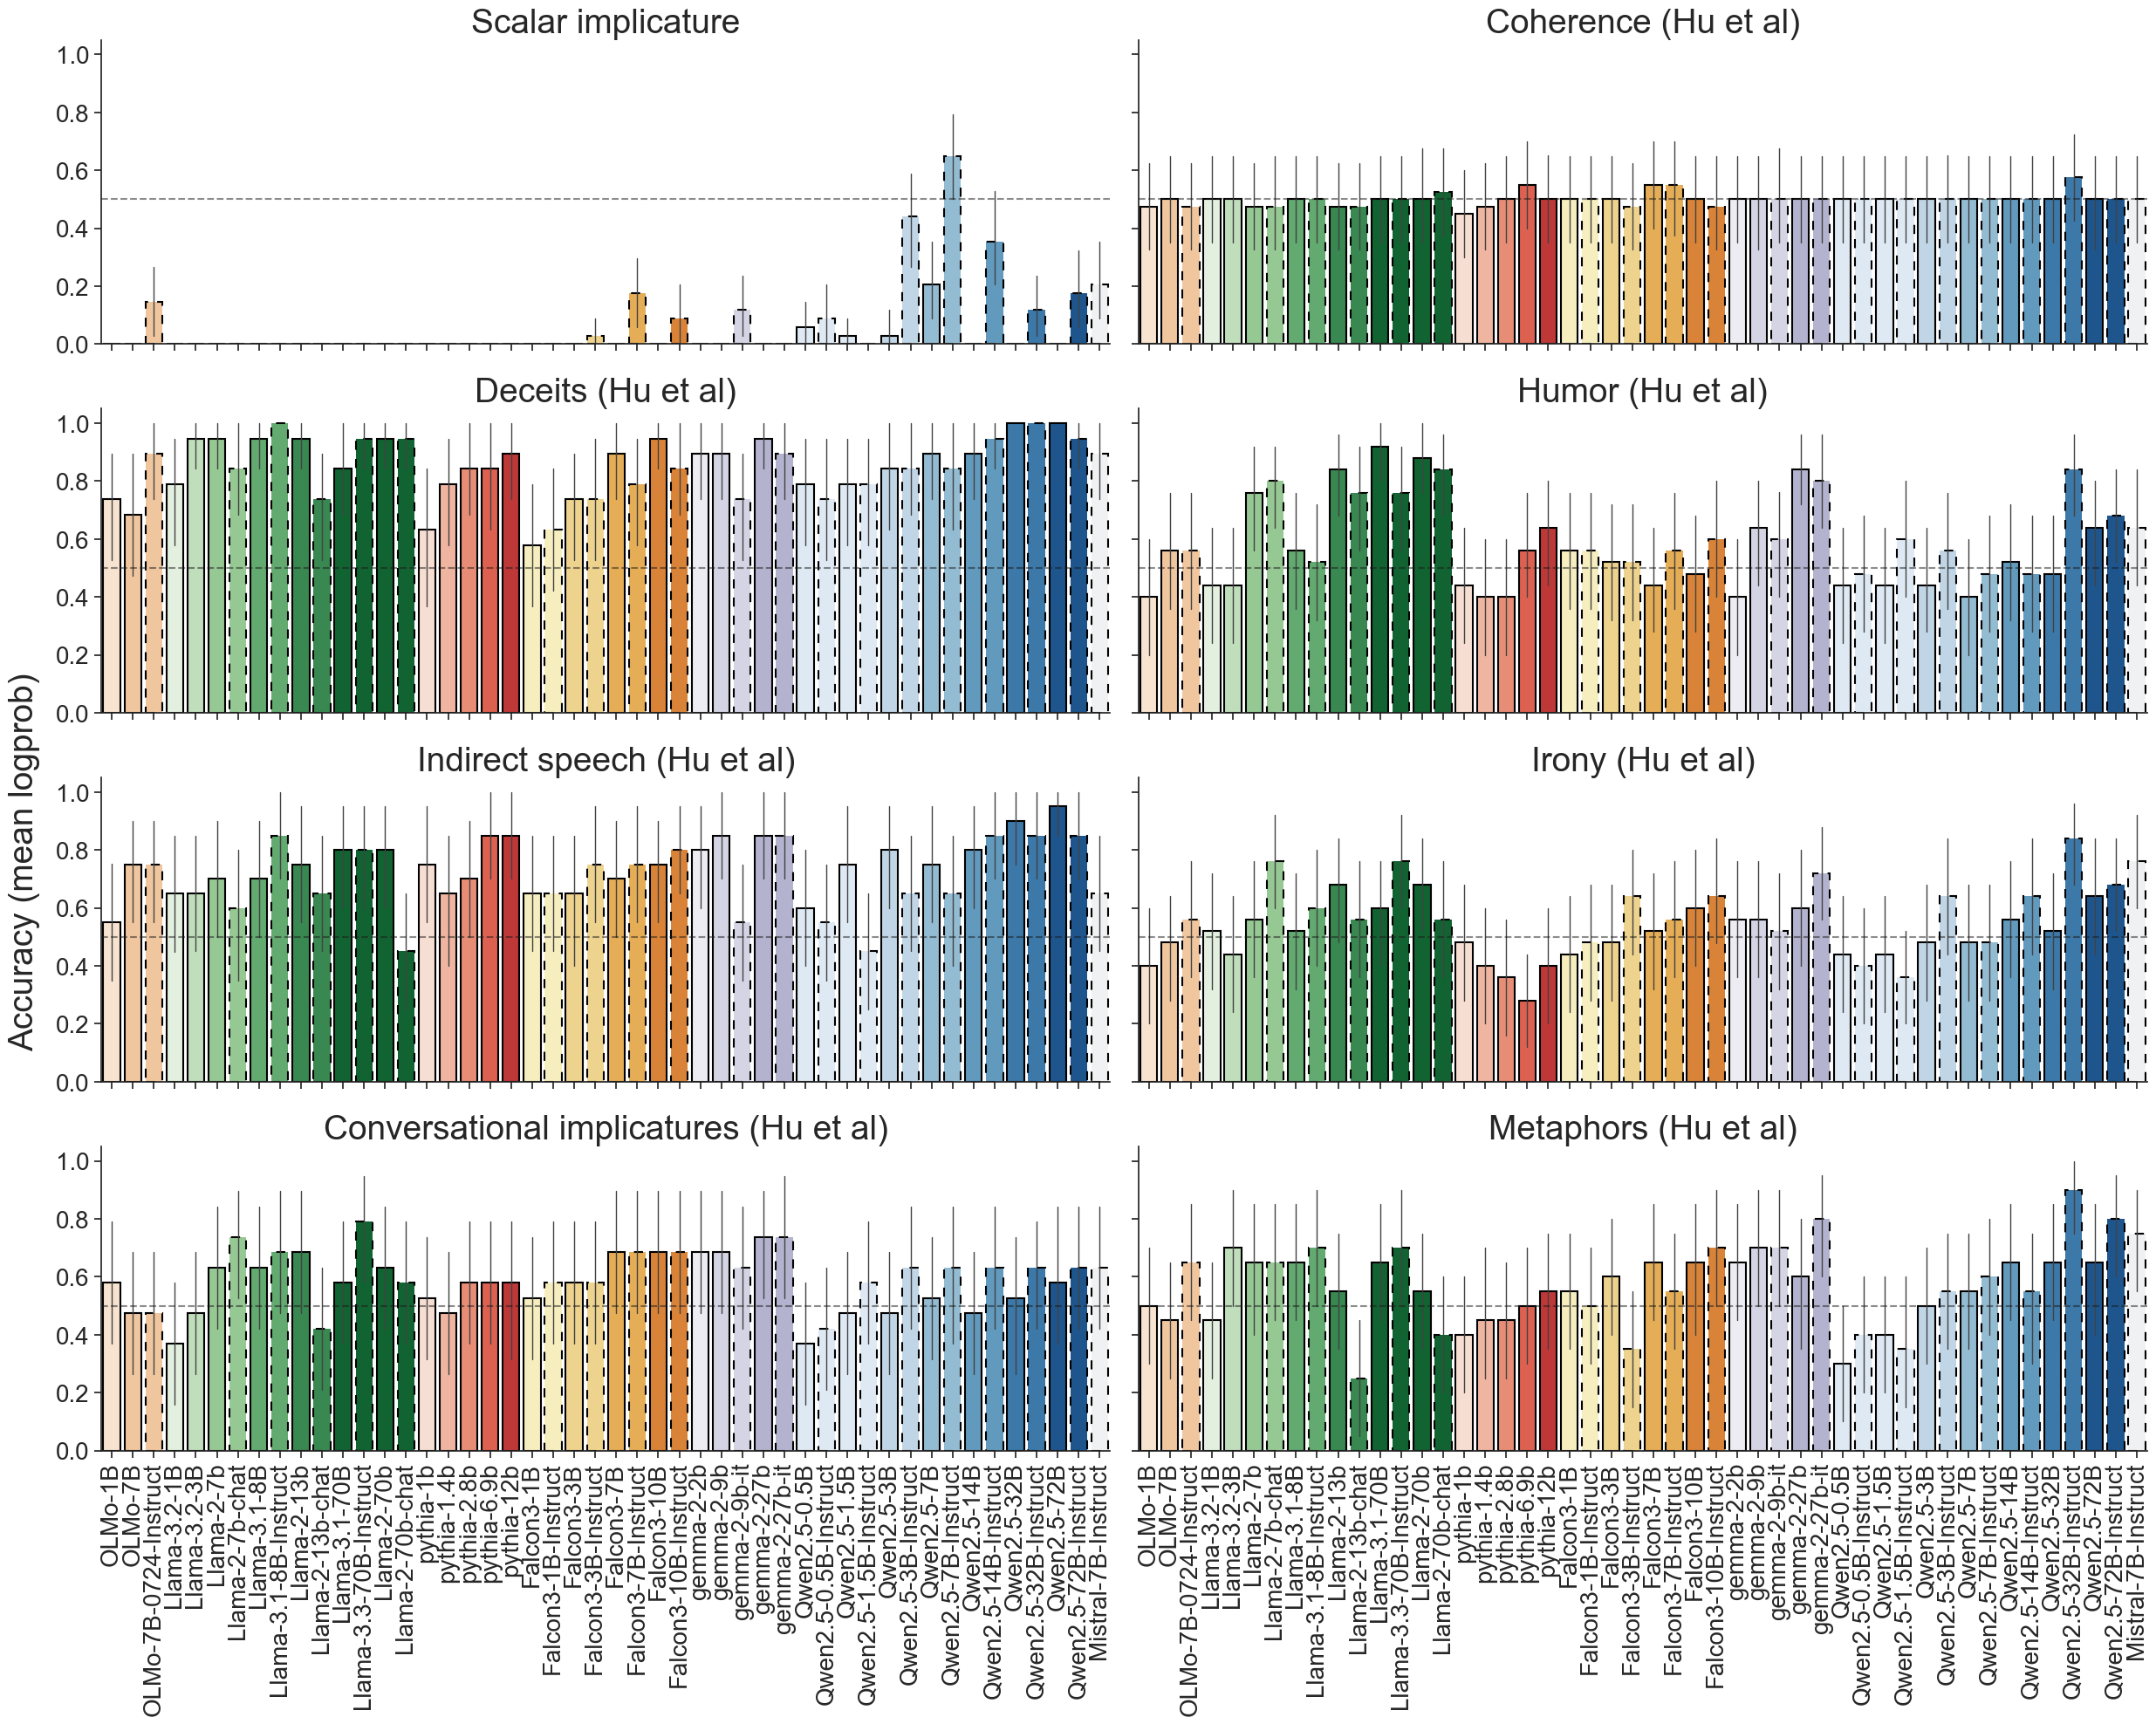

In [87]:
plot_accuracy(data_pragmatics_df_filtered_part1, metric="mean_logprob", dataset_list=DATASETS_PRAGMATICS1, pretty_names=dataset_name_mapping)


['allenai/OLMo-1B-0724-hf', 'allenai/OLMo-7B-0724-hf', 'allenai/OLMo-7B-0724-Instruct-hf', 'meta-llama/Llama-3.2-1B', 'meta-llama/Llama-3.2-3B', 'meta-llama/Llama-2-7b-hf', 'meta-llama/Llama-2-7b-chat-hf', 'meta-llama/Llama-3.1-8B', 'meta-llama/Llama-3.1-8B-Instruct', 'meta-llama/Llama-2-13b-hf', 'meta-llama/Llama-2-13b-chat-hf', 'meta-llama/Llama-3.1-70B', 'meta-llama/Llama-3.3-70B-Instruct', 'meta-llama/Llama-2-70b-hf', 'meta-llama/Llama-2-70b-chat-hf', 'EleutherAI/pythia-1b-deduped', 'EleutherAI/pythia-1.4b-deduped', 'EleutherAI/pythia-2.8b-deduped', 'EleutherAI/pythia-6.9b-deduped', 'EleutherAI/pythia-12b-deduped', 'tiiuae/Falcon3-1B-Base', 'tiiuae/Falcon3-1B-Instruct', 'tiiuae/Falcon3-3B-Base', 'tiiuae/Falcon3-3B-Instruct', 'tiiuae/Falcon3-7B-Base', 'tiiuae/Falcon3-7B-Instruct', 'tiiuae/Falcon3-10B-Base', 'tiiuae/Falcon3-10B-Instruct', 'google/gemma-2-2b', 'google/gemma-2-9b', 'google/gemma-2-9b-it', 'google/gemma-2-27b', 'google/gemma-2-27b-it', 'Qwen/Qwen2.5-0.5B', 'Qwen/Qwen2.5

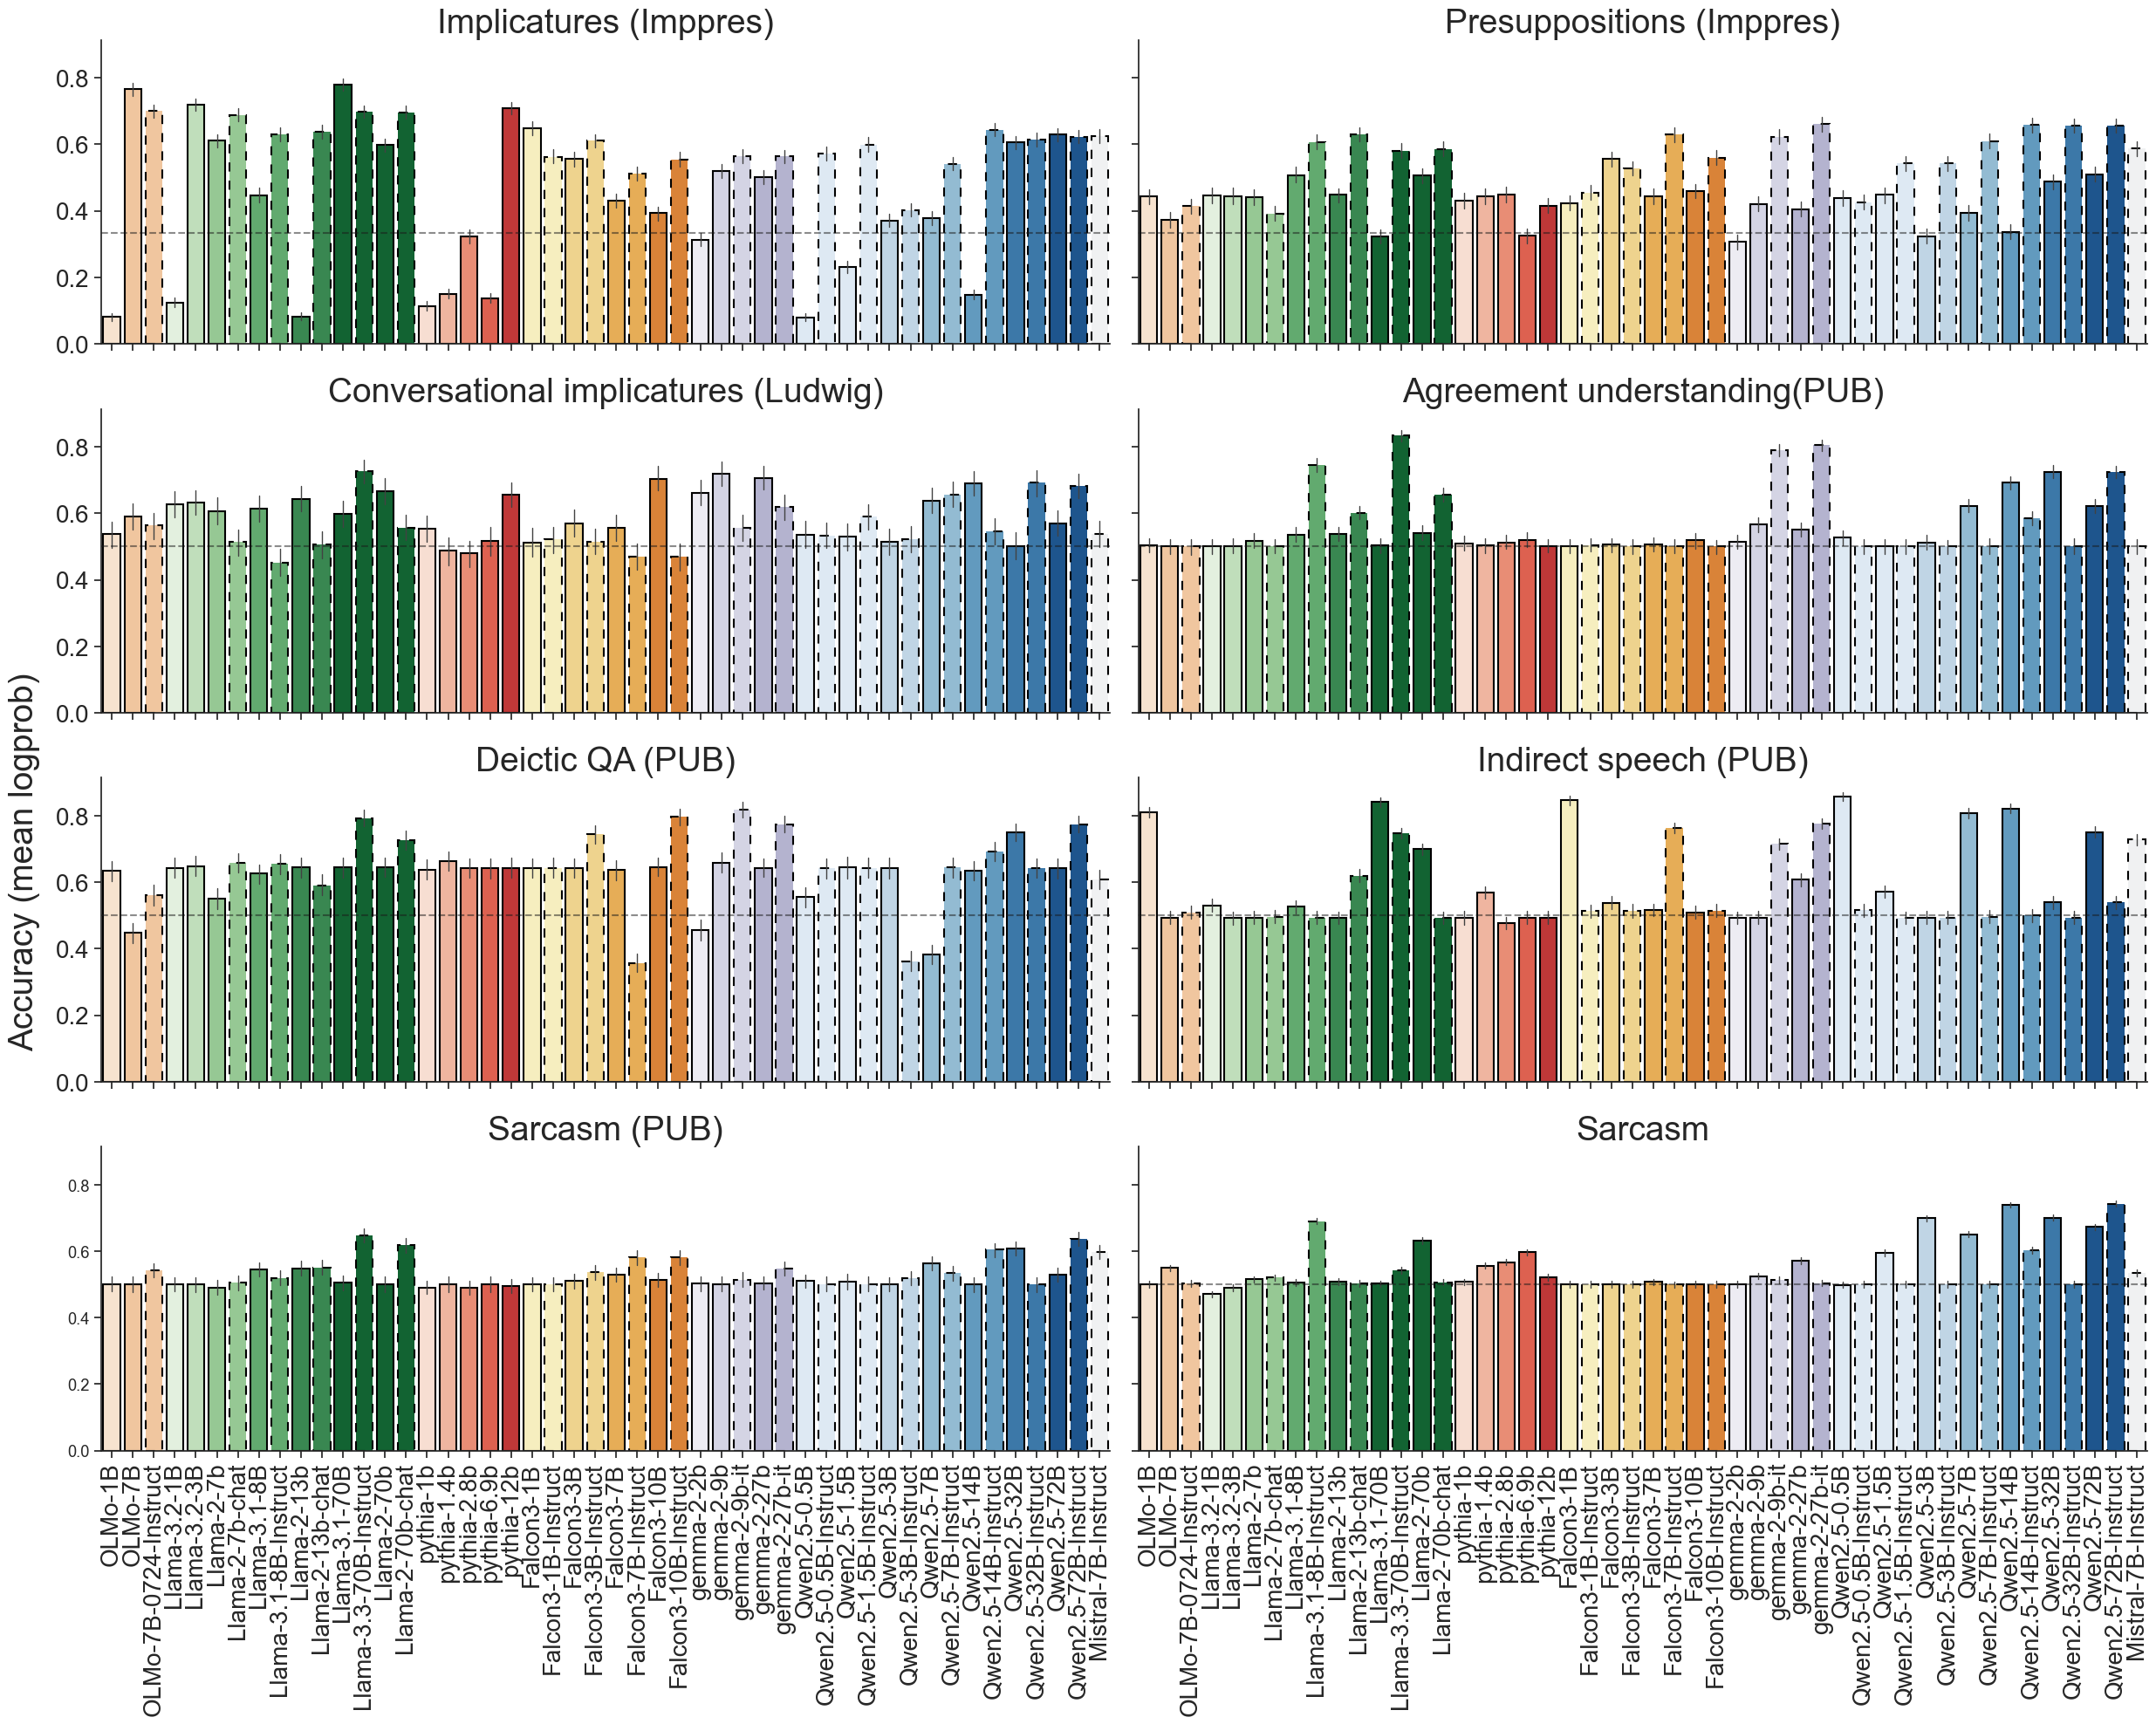

In [88]:
plot_accuracy(data_pragmatics_df_filtered_part2, metric="mean_logprob", dataset_list=DATASETS_PRAGMATICS2, pretty_names=dataset_name_mapping)


In [49]:
tom_dataset_name_mapping = {
    "bigtom_forward": "BigToM (forward)",
    "bigtom_backward": "BigToM (backward)",
    "emobench_application": "Emotion application (EmoBench)",
    "emobench_understanding_cause": "Understanding cause of emotions (EmoBench)",
    "emobench_understanding_emotion": "Emotion understanding (EmoBench)",
    "epitome_fb": "False belief (Epitome)",
    "epitome_rm": "Recursive mind-reading (Epitome)",
    "ewok_agent-properties": "Agent properties (EWoK)",
    "ewok_social-interactions": "Social interactions (EWoK)",
    "ewok_social-properties": "Social properties (EWoK)",
    "fauxpas_eai_q1_and_q4": "Faux Pas",
    "opentom_attitude": "Attitude towards event (OpenToM)",
    "opentom_location_cg_fo": "First-order false belief (coarse-grained questions) (OpenToM)",
    "opentom_location_cg_so": "Second-order false belief (coarse-grained questions) (OpenToM)",
    "opentom_location_fg_fo_new": "First-order false belief (fine-grained questions) (OpenToM)",
    "opentom_location_fg_so_new": "Second-order false belief (fine-grained questions) (OpenToM)",
    "opentom_multihop_fo": "Multi-hop first-order false belief (OpenToM)",
    "opentom_multihop_so": "Multi-hop second-order false belief (OpenToM)",
    "simpletom_behavior": "Belief-based actions (SimpleToM)",
    "social_iqa": "Social IQA",
    "tomi_sapEtAl_first_order": "First-order false belief(ToMI)",
    "triangle-copa": "Triangle-COPA"
}

In [50]:
DATASETS_TOM_filtered = [d for d in DATASETS_TOM if d in data_tom_df_filtered["dataset"].unique()]
len(DATASETS_TOM_filtered)

22

In [74]:
DATASETS_TOM1 = DATASETS_TOM_filtered[:10]
DATASETS_TOM2 = DATASETS_TOM_filtered[10:]
data_tom_df_filtered_part1 = data_tom_df_filtered[data_tom_df_filtered["dataset"].isin(DATASETS_TOM1)]
data_tom_df_filtered_part2 = data_tom_df_filtered[data_tom_df_filtered["dataset"].isin(DATASETS_TOM2)]

['allenai/OLMo-1B-0724-hf', 'allenai/OLMo-7B-0724-hf', 'allenai/OLMo-7B-0724-Instruct-hf', 'meta-llama/Llama-3.2-1B', 'meta-llama/Llama-3.2-3B', 'meta-llama/Llama-2-7b-hf', 'meta-llama/Llama-2-7b-chat-hf', 'meta-llama/Llama-3.1-8B', 'meta-llama/Llama-3.1-8B-Instruct', 'meta-llama/Llama-2-13b-hf', 'meta-llama/Llama-2-13b-chat-hf', 'meta-llama/Llama-3.1-70B', 'meta-llama/Llama-3.3-70B-Instruct', 'meta-llama/Llama-2-70b-hf', 'meta-llama/Llama-2-70b-chat-hf', 'EleutherAI/pythia-1b-deduped', 'EleutherAI/pythia-1.4b-deduped', 'EleutherAI/pythia-2.8b-deduped', 'EleutherAI/pythia-6.9b-deduped', 'EleutherAI/pythia-12b-deduped', 'tiiuae/Falcon3-1B-Base', 'tiiuae/Falcon3-1B-Instruct', 'tiiuae/Falcon3-3B-Base', 'tiiuae/Falcon3-3B-Instruct', 'tiiuae/Falcon3-7B-Base', 'tiiuae/Falcon3-7B-Instruct', 'tiiuae/Falcon3-10B-Base', 'tiiuae/Falcon3-10B-Instruct', 'google/gemma-2-2b', 'google/gemma-2-9b', 'google/gemma-2-9b-it', 'google/gemma-2-27b', 'google/gemma-2-27b-it', 'Qwen/Qwen2.5-0.5B', 'Qwen/Qwen2.5

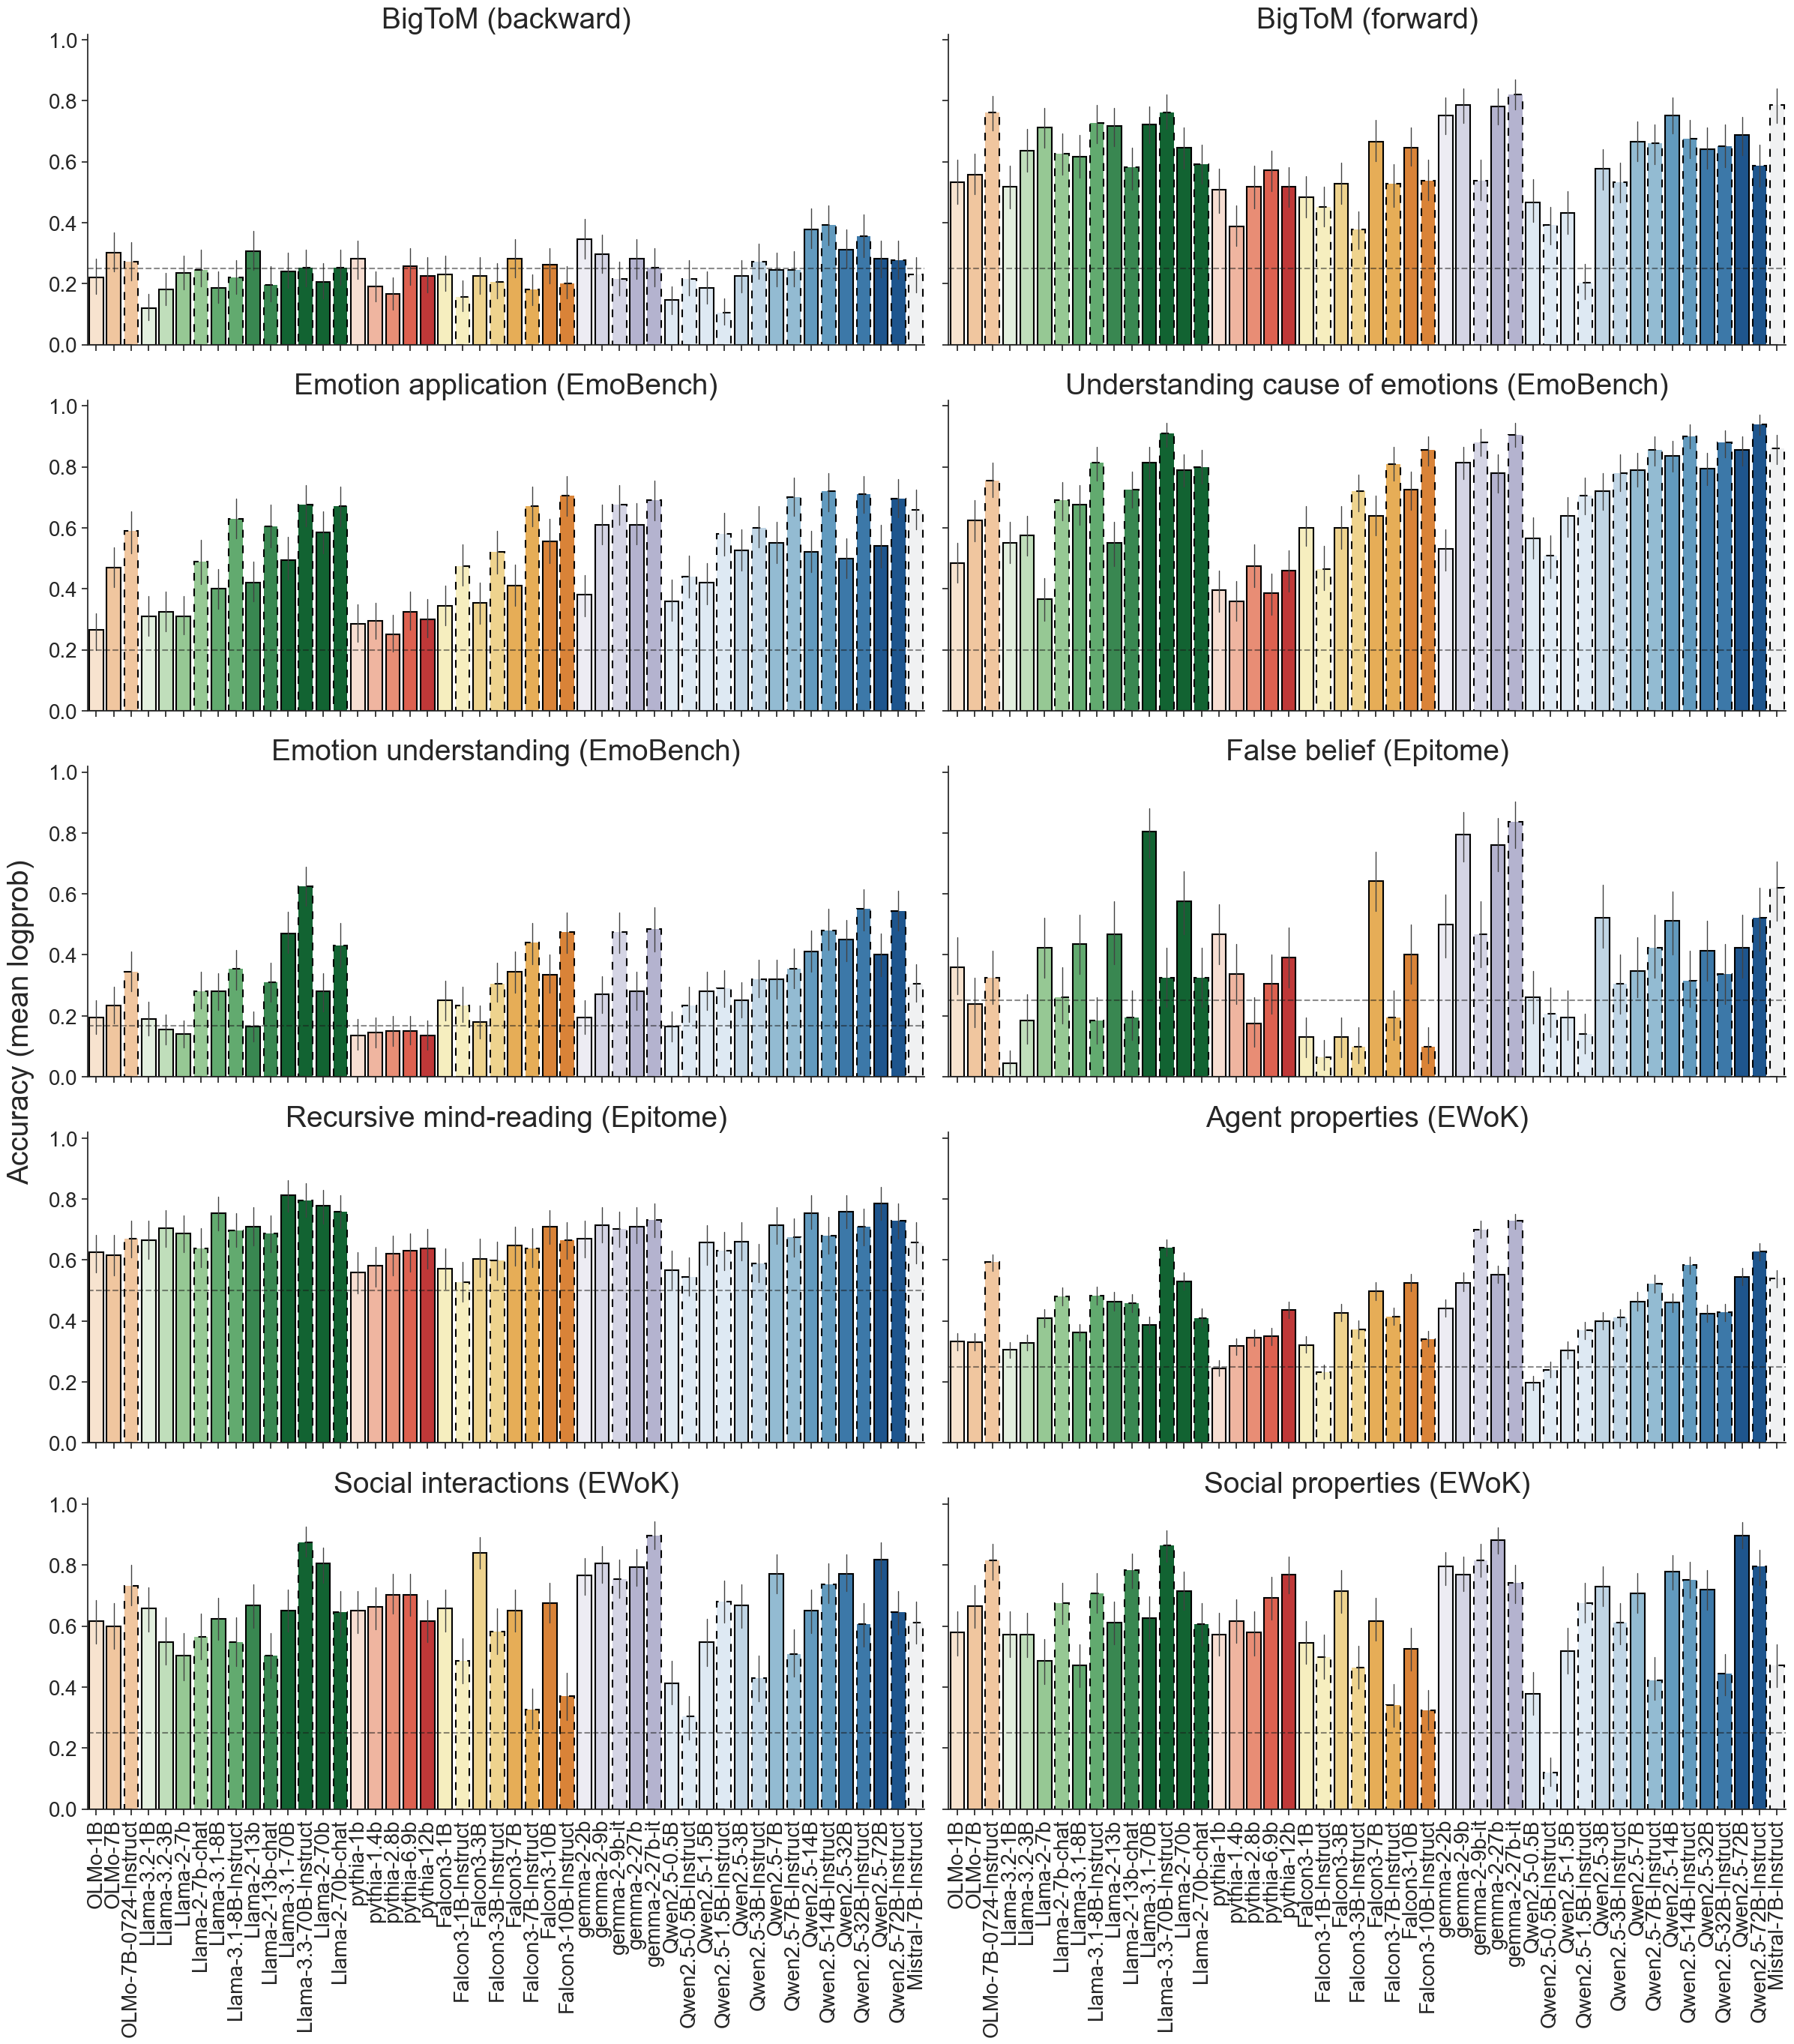

In [84]:
plot_accuracy(data_tom_df_filtered_part1, metric="mean_logprob", dataset_list=DATASETS_TOM_filtered, pretty_names=tom_dataset_name_mapping)


['allenai/OLMo-1B-0724-hf', 'allenai/OLMo-7B-0724-hf', 'allenai/OLMo-7B-0724-Instruct-hf', 'meta-llama/Llama-3.2-1B', 'meta-llama/Llama-3.2-3B', 'meta-llama/Llama-2-7b-hf', 'meta-llama/Llama-2-7b-chat-hf', 'meta-llama/Llama-3.1-8B', 'meta-llama/Llama-3.1-8B-Instruct', 'meta-llama/Llama-2-13b-hf', 'meta-llama/Llama-2-13b-chat-hf', 'meta-llama/Llama-3.1-70B', 'meta-llama/Llama-3.3-70B-Instruct', 'meta-llama/Llama-2-70b-hf', 'meta-llama/Llama-2-70b-chat-hf', 'EleutherAI/pythia-1b-deduped', 'EleutherAI/pythia-1.4b-deduped', 'EleutherAI/pythia-2.8b-deduped', 'EleutherAI/pythia-6.9b-deduped', 'EleutherAI/pythia-12b-deduped', 'tiiuae/Falcon3-1B-Base', 'tiiuae/Falcon3-1B-Instruct', 'tiiuae/Falcon3-3B-Base', 'tiiuae/Falcon3-3B-Instruct', 'tiiuae/Falcon3-7B-Base', 'tiiuae/Falcon3-7B-Instruct', 'tiiuae/Falcon3-10B-Base', 'tiiuae/Falcon3-10B-Instruct', 'google/gemma-2-2b', 'google/gemma-2-9b', 'google/gemma-2-9b-it', 'google/gemma-2-27b', 'google/gemma-2-27b-it', 'Qwen/Qwen2.5-0.5B', 'Qwen/Qwen2.5

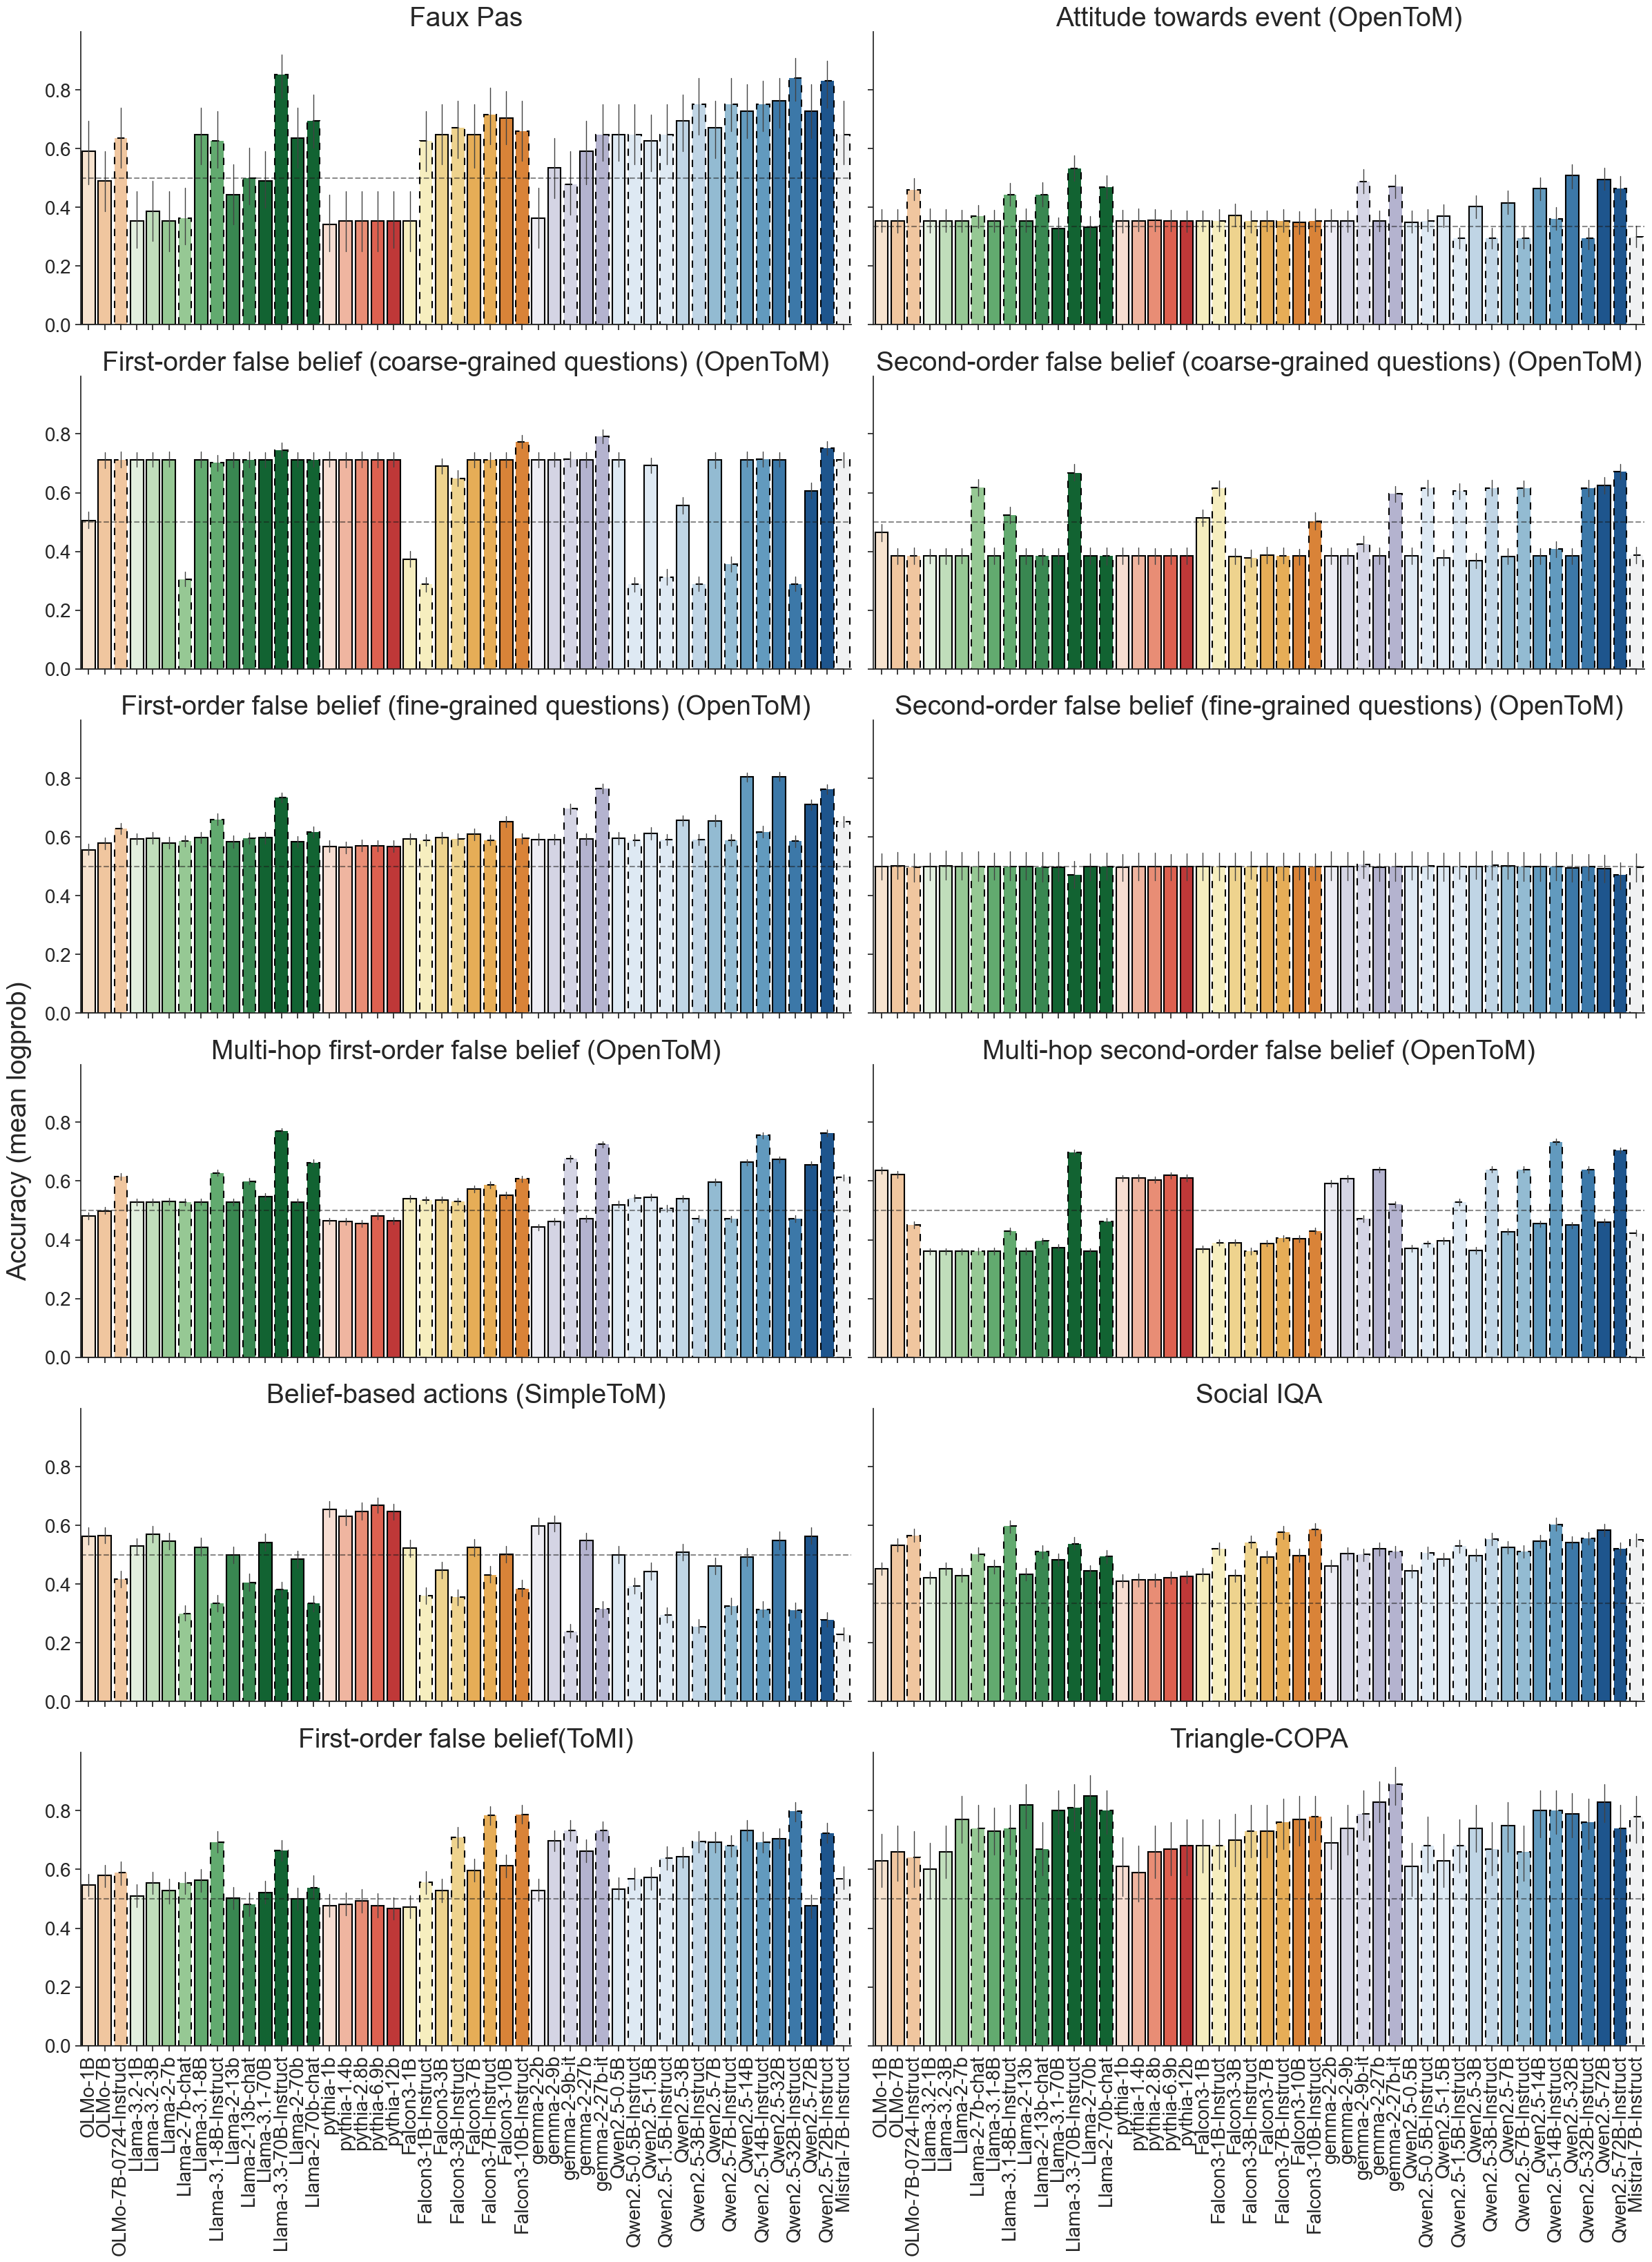

In [85]:
plot_accuracy(data_tom_df_filtered_part2, metric="mean_logprob", dataset_list=DATASETS_TOM2, pretty_names=tom_dataset_name_mapping)


In [ ]:
data_tom_df["domain"] = "tom"
data_pragmatics_df["domain"] = "pragmatics"
data_tom_df["model_correct"] = data_tom_df["model_correct_mean_logprob"].apply(lambda s: 1 if s else 0)
data_pragmatics_df["model_correct"] = data_pragmatics_df["model_correct_mean_logprob"].apply(lambda s: 1 if s else 0)
data_general_df["model_correct"] = data_general_df["model_correct_mean_logprob"].apply(lambda s: 1 if s else 0)
# pd.concat([data_tom_df, data_pragmatics_df, data_general_df]).reset_index().to_csv("all_model_responses_tom_pragmatics_general.csv", index=False)

In [161]:
# baseline regression analysis
ds_mc_style = [
  "fauxpas_eai_q1_and_q4",
  "hufloyd_humour",
  "opentom_attitude",
  "opentom_location_cg_fo",
  "opentom_location_cg_fo_long",
  "opentom_location_cg_so",
  "opentom_location_cg_so_long",
  "opentom_location_fg_fo_new",
  "opentom_location_fg_so_new",
  "opentom_multihop_fo",
  "opentom_multihop_so"
]
ds_regression = pd.concat([data_tom_df, data_pragmatics_df]).reset_index()
ds_regression["ds_type"] = ds_regression.apply(lambda row: "mc_style" if row["dataset"] in ds_mc_style else "completion", axis=1)
ds_regression["model_family"] = ds_regression["model"].apply(lambda s: s.split("/")[0])

print(ds_regression)

         level_0   index  item_id                      model          dataset  \
0              0       0        0   meta-llama/Llama-2-7b-hf  bigtom_backward   
1              1       1        1   meta-llama/Llama-2-7b-hf  bigtom_backward   
2              2       2        2   meta-llama/Llama-2-7b-hf  bigtom_backward   
3              3       3        3   meta-llama/Llama-2-7b-hf  bigtom_backward   
4              4       4        4   meta-llama/Llama-2-7b-hf  bigtom_backward   
...          ...     ...      ...                        ...              ...   
3159013  1144193  497453   497453  meta-llama/Llama-2-70b-hf           sarcv2   
3159014  1144194  497454   497454  meta-llama/Llama-2-70b-hf           sarcv2   
3159015  1144195  497455   497455  meta-llama/Llama-2-70b-hf           sarcv2   
3159016  1144196  497456   497456  meta-llama/Llama-2-70b-hf           sarcv2   
3159017  1144197  497457   497457  meta-llama/Llama-2-70b-hf           sarcv2   

         chance model_corre

In [163]:
# add size
model_size = pd.read_csv("model_size_mapping.csv")[["model", "size_num"]]
ds_regression = ds_regression.merge(model_size, on="model", how="left")

In [164]:
ds_regression.columns

Index(['level_0', 'index', 'item_id', 'model', 'dataset', 'chance',
       'model_correct_mean_logprob', 'model_correct_sum_logprob', 'model_type',
       'domain', 'model_correct', 'ds_type', 'model_family', 'size_num'],
      dtype='object')

In [ ]:
# import pandas as pd
# import numpy as np
# import statsmodels.api as sm
# from patsy import dmatrices, Treatment
# from patsy.contrasts import Sum

# # ---------------------------
# # Load and prepare the dataset
# # ---------------------------

# # d_annotated = pd.read_csv("...")  # your dataset

# d_processed = ds_regression.copy()

# # Ensure relevant variables are categorical
# categorical_vars = ["model_family", "model_type", "ds_type", "domain"]
# for col in categorical_vars:
#     d_processed[col] = d_processed[col].astype("category")

# # Outcome variable must be 0/1
# # If already 0/1, skip this
# d_processed["model_correct"] = d_processed["model_correct"].astype(int)
# # Or whatever criterion defines correctness


# # ----------------------------------
# # Build design matrices with SUM coding
# # ----------------------------------

# # formula = "model_correct ~ model_family + size_num + model_type + ds_type + domain"
# formula = (
#     "model_correct ~ "
#     "C(model_family, Sum) + "
#     "size_num + "
#     "C(model_type, Sum) + "
#     "C(ds_type, Sum) + "
#     "C(domain, Sum)"
# )

# # y, X = dmatrices(
# #     formula,
# #     data=d_processed,
# #     return_type='dataframe',
# #     NA_action="drop",
# #     # Assign SUM CONTRASTS identical to R's contr.sum
# #     contrasts={
# #         "model_family": Sum(),
# #         "model_type": Sum(),
# #         "ds_type": Sum(),
# #         "domain": Sum(),
# #     }
# # )

# # Build design matrices
# y, X = dmatrices(
#     formula,
#     data=d_processed,
#     return_type="dataframe",
#     NA_action="drop"
# )

# # Remove intercept if you want pure sum coding with no redundancy
# # X = X.drop(columns=["Intercept"], errors="ignore")

# # ---------------------------
# # Fit logistic regression model
# # ---------------------------

# # logit_model = sm.Logit(y, X)
# # result = logit_model.fit(maxiter=200, method="lbfgs")  # LBFGS handles big data well
# # Convert to numpy
# y = np.asarray(y).ravel()
# X = np.asarray(X)

# # Logistic negative log-likelihood
# def neg_log_lik(beta, X, y):
#     z = X @ beta
#     p = expit(z)
#     eps = 1e-9
#     return -np.sum(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))

# # Fit model
# beta0 = np.zeros(X.shape[1])

# res = minimize(
#     fun=neg_log_lik,
#     x0=beta0,
#     args=(X, y),
#     method="L-BFGS-B",
#     options={"maxiter": 300, "disp": True},
# )

# print("Converged:", res.success)
# print("Coefficients:", res.x)

TypeError: dmatrices() got an unexpected keyword argument 'contrasts'

In [167]:
import numpy as np
import pandas as pd
from patsy import dmatrices, Sum
from scipy.optimize import minimize
from scipy.special import expit

d_processed = ds_regression.copy()

# # Ensure relevant variables are categorical
categorical_vars = ["model_family", "model_type", "ds_type", "domain"]
for col in categorical_vars:
    d_processed[col] = d_processed[col].astype("category")

# # Outcome variable must be 0/1
# # If already 0/1, skip this
d_processed["model_correct"] = d_processed["model_correct"].astype(int)

# Ensure categorical encoding
for col in ["model_family", "model_type", "ds_type", "domain"]:
    d_processed[col] = d_processed[col].astype("category")

# Convert outcome to binary
d_processed["model_correct"] = (
    d_processed["model_correct_mean_logprob"] > 0
).astype(int)

# --- formula with contrast specification embedded ---
formula = (
    "model_correct ~ "
    "C(model_family, Sum) + "
    "size_num + "
    "C(model_type, Sum) + "
    "C(ds_type, Sum) + "
    "C(domain, Sum)"
)

# Build design matrices
y, X = dmatrices(
    formula,
    data=d_processed,
    return_type="dataframe",
    NA_action="drop"
)

# Convert to numpy
y = np.asarray(y).ravel()
X = np.asarray(X)

# Logistic negative log-likelihood
def neg_log_lik(beta, X, y):
    z = X @ beta
    p = expit(z)
    eps = 1e-9
    return -np.sum(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))

# Fit model
beta0 = np.zeros(X.shape[1])

res = minimize(
    fun=neg_log_lik,
    x0=beta0,
    args=(X, y),
    method="L-BFGS-B",
    options={"maxiter": 300, "disp": True},
)

print("Converged:", res.success)
print("Coefficients:", res.x)


 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           11     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  2.18966D+06    |proj g|=  3.10660D+06

At iterate    1    f=  2.18024D+06    |proj g|=  3.24819D+04

At iterate    2    f=  2.18023D+06    |proj g|=  3.19953D+04

At iterate    3    f=  2.18020D+06    |proj g|=  9.96958D+04

At iterate    4    f=  2.18012D+06    |proj g|=  2.24237D+05

At iterate    5    f=  2.17992D+06    |proj g|=  4.30261D+05

At iterate    6    f=  2.17947D+06    |proj g|=  6.80795D+05

At iterate    7    f=  2.17864D+06    |proj g|=  8.65379D+05

At iterate    8    f=  2.17768D+06    |proj g|=  7.26170D+05

At iterate    9    f=  2.17712D+06    |proj g|=  3.05799D+05

At iterate   10    f=  2.17700D+06    |proj g|=  2.03179D+04

At iterate   11    f=  2.17699D+06    |proj g|=  5.14321D+04

At iterate   12    f=  2.17698D+06    |proj g|=  7.32964D+04

At iterate   13    f=  2.1

In [170]:
y_design, X_design = dmatrices(formula, data=d_processed, return_type="dataframe")
coef = pd.Series(res.x, index=X_design.columns)
print(coef)


Intercept                             0.090480
C(model_family, Sum)[S.EleutherAI]    0.018142
C(model_family, Sum)[S.Qwen]          0.015221
C(model_family, Sum)[S.allenai]       0.106076
C(model_family, Sum)[S.google]        0.051478
C(model_family, Sum)[S.meta-llama]   -0.122331
C(model_family, Sum)[S.mistralai]     0.010542
C(model_type, Sum)[S.base]           -0.040474
C(ds_type, Sum)[S.completion]        -0.073638
C(domain, Sum)[S.pragmatics]          0.089409
size_num                              0.006111
dtype: float64


In [171]:
import numpy as np
from scipy.special import expit
from scipy.stats import norm

beta = res.x

# Recompute predicted probabilities at optimum
p = expit(X @ beta)

# Hessian = Xᵀ W X  where W = p(1−p)
W = p * (1 - p)
XTWX = X.T @ (W[:, None] * X)

# Invert Hessian → covariance matrix
cov = np.linalg.inv(XTWX)

# Standard errors
se = np.sqrt(np.diag(cov))

# z-scores and p-values
z = beta / se
p_values = 2 * (1 - norm.cdf(np.abs(z)))

# Pack into table
results = pd.DataFrame({
    "coef": beta,
    "std_err": se,
    "z": z,
    "p_value": p_values
}, index=X_design.columns)

print(results)


                                        coef   std_err           z  \
Intercept                           0.090480  0.001908   47.413952   
C(model_family, Sum)[S.EleutherAI]  0.018142  0.003644    4.979065   
C(model_family, Sum)[S.Qwen]        0.015221  0.002518    6.046014   
C(model_family, Sum)[S.allenai]     0.106076  0.004338   24.454377   
C(model_family, Sum)[S.google]      0.051478  0.002747   18.742368   
C(model_family, Sum)[S.meta-llama] -0.122331  0.002780  -44.001437   
C(model_family, Sum)[S.mistralai]   0.010542  0.007360    1.432299   
C(model_type, Sum)[S.base]         -0.040474  0.001217  -33.251559   
C(ds_type, Sum)[S.completion]      -0.073638  0.001418  -51.929121   
C(domain, Sum)[S.pragmatics]        0.089409  0.001404   63.666186   
size_num                            0.006111  0.000060  102.304709   

                                         p_value  
Intercept                           0.000000e+00  
C(model_family, Sum)[S.EleutherAI]  6.389209e-07  
C(mode

In [169]:
res

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: 2175181.2944243145
        x: [ 9.048e-02  1.814e-02  1.522e-02  1.061e-01  5.148e-02
            -1.223e-01  1.054e-02 -4.047e-02 -7.364e-02  8.941e-02
             6.111e-03]
      nit: 72
      jac: [-2.692e+01  4.985e+02  5.276e+01  1.930e+02  1.090e+02
             2.231e+02  1.482e+02 -2.729e+01  6.733e+01  2.760e+02
            -8.465e+02]
     nfev: 996
     njev: 83
 hess_inv: <11x11 LbfgsInvHessProduct with dtype=float64>

In [ ]:
# subset to larger models only 
big_models =[
    "allenai/OLMo-7B-0724-hf", 
    "allenai/OLMo-7B-0724-Instruct-hf", 
    "meta-llama/Llama-3.1-8B", 
    "meta-llama/Llama-3.1-8B-Instruct", 
    "meta-llama/Llama-2-7b-hf", 
    "meta-llama/Llama-2-7b-chat-hf", 
    "meta-llama/Llama-2-13b-hf",
    "meta-llama/Llama-2-13b-chat-hf",
    "meta-llama/Llama-3.1-70B",
    "meta-llama/Llama-3.3-70B-Instruct",
    "meta-llama/Llama-2-70b-hf",
    "meta-llama/Llama-2-70b-chat-hf",
    "EleutherAI/pythia-6.9b-deduped",
    "EleutherAI/pythia-12b-deduped",
    "tiiuae/Falcon3-7B-Base",
    "tiiuae/Falcon3-7B-Instruct",
    "tiiuae/Falcon3-10B-Base",
    "tiiuae/Falcon3-10B-Instruct",
    "google/gemma-3-12b-pt",
    "google/gemma-3-12b-it",
    "google/gemma-3-27b-pt",
    "google/gemma-3-27b-it",
    "Qwen/Qwen2.5-7B",
    "Qwen/Qwen2.5-7B-Instruct",
    "Qwen/Qwen2.5-14B",
    "Qwen/Qwen2.5-14B-Instruct",
    "Qwen/Qwen2.5-32B",
    "Qwen/Qwen2.5-32B-Instruct",
    "Qwen/Qwen2.5-72B",
    "Qwen/Qwen2.5-72B-Instruct",
    "mistralai/Mistral-7B-Instruct-v0.3"
]
big_models_selection =[
    "meta-llama/Llama-3.1-8B", 
    "meta-llama/Llama-3.1-8B-Instruct", 
    "meta-llama/Llama-2-13b-hf",
    "meta-llama/Llama-2-13b-chat-hf",
    "meta-llama/Llama-3.1-70B",
    "meta-llama/Llama-3.3-70B-Instruct",
    "tiiuae/Falcon3-7B-Base",
    "tiiuae/Falcon3-7B-Instruct",
    "tiiuae/Falcon3-10B-Base",
    "tiiuae/Falcon3-10B-Instruct",
    "Qwen/Qwen2.5-7B",
    "Qwen/Qwen2.5-7B-Instruct",
    "Qwen/Qwen2.5-32B",
    "Qwen/Qwen2.5-32B-Instruct",
    "Qwen/Qwen2.5-72B",
    "Qwen/Qwen2.5-72B-Instruct",
]
big_model_prag = data_pragmatics_df[data_pragmatics_df["model"].isin(big_models)]
big_models_tom = data_tom_df[data_tom_df["model"].isin(big_models)]


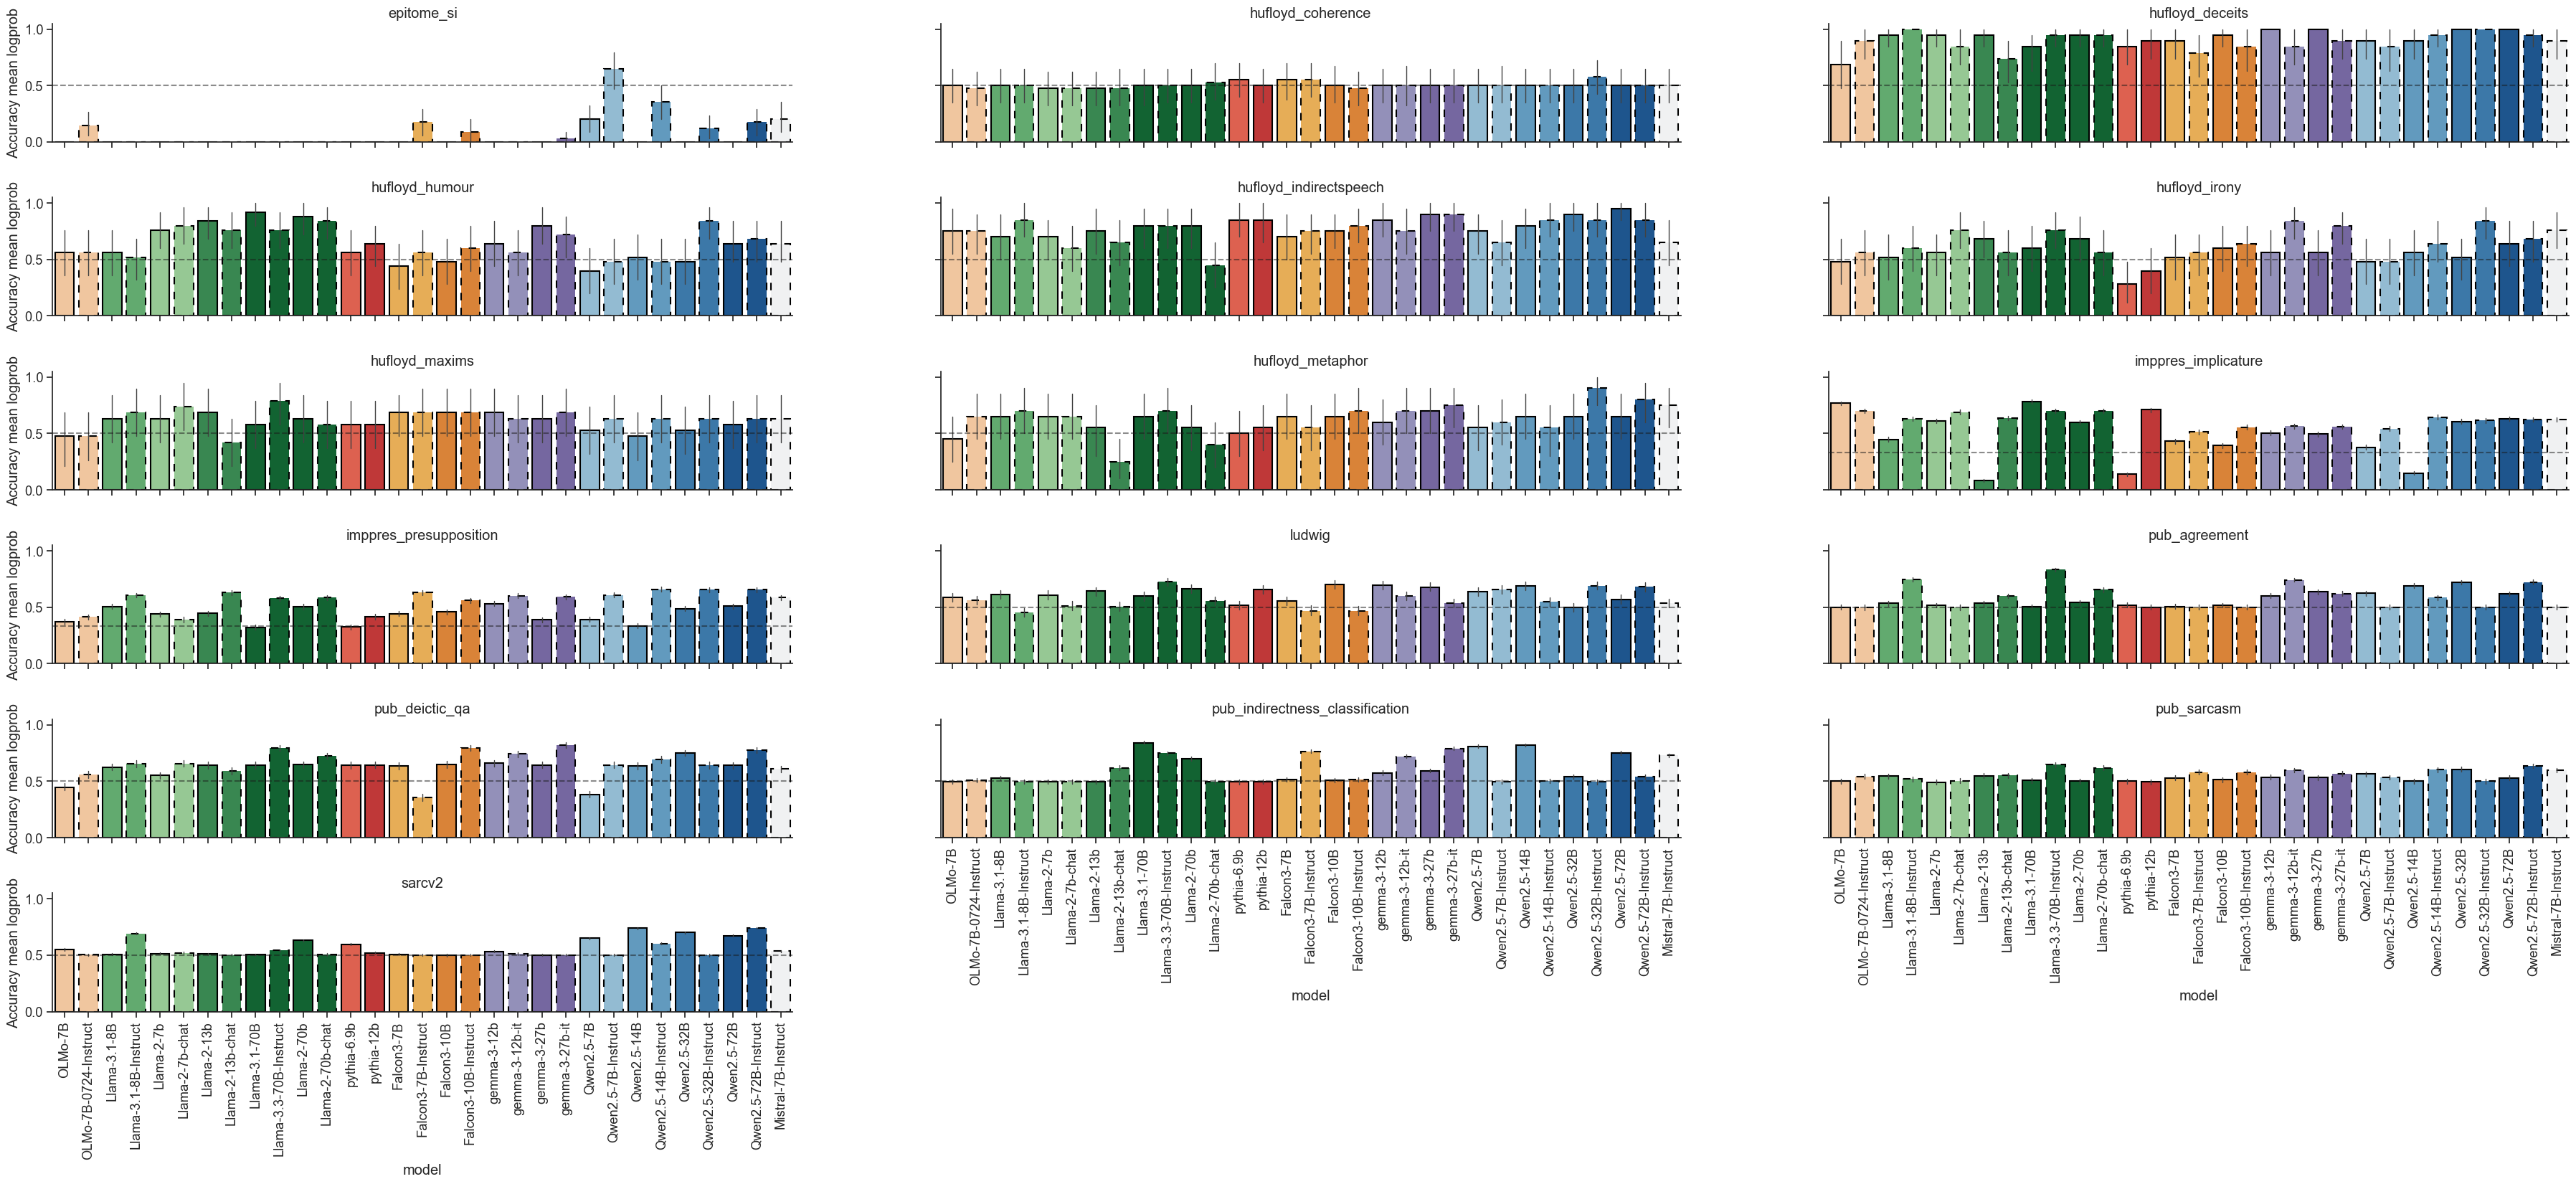

In [81]:
g = sns.catplot(
    data=big_model_prag, 
    x="model",
    y=f"model_correct_mean_logprob",
    # order=model_order, 
    hue="model",
    order=big_models,
    hue_order=big_models,
    palette=MODEL_PAL,
    col="dataset",
    col_wrap=3,
    kind="bar",
    height=2.5,
    aspect=5,
    err_kws={"lw": 1}
)
g.set_titles("{col_name}")
g.set_xticklabels([MODEL_MAP[m] for m in big_models], rotation=90) # MODEL_MAP.values() , ha="right" [MODEL_MAP[m] for m in MODELS]
g.set_ylabels(f"Accuracy mean logprob")
plt.subplots_adjust(wspace=0.2)

line_styles = {
    "base": (0, ()),          # solid
    "instruct": (0, (5, 5))      # dashed
}

# Ensure data includes "model_type"
if "model_type" not in big_model_prag.columns:
    raise ValueError("Data must include a 'model_type' column")

# # Loop through facets
# for ax in g.axes.flat:
model_order = list(big_models)           # matches hue_order
# num_models = len(model_order)
for i, ax in enumerate(g.axes):
    for j, bar in enumerate(ax.patches): #for bar, model_name in zip(ax.patches, big_model_prag["model"].unique()):
        model_name = model_order[j % len(model_order)]
        # Get the model_type for this model
        model_type = big_model_prag.loc[big_model_prag["model"] == model_name, "model_type"].iloc[0]
        ls = line_styles.get(model_type, (0, ()))  # default solid
        bar.set_edgecolor("black")
        bar.set_linewidth(1.5)
        bar.set_linestyle(ls)

    if DATASETS_PRAGMATICS[i] == "pub_indirectness_interpretation":
        continue
    chance = big_model_prag[big_model_prag["dataset"] == DATASETS_PRAGMATICS[i]]["chance"].tolist()[0] 
    ax.axhline(chance, linestyle="--", color="k", alpha=0.5)

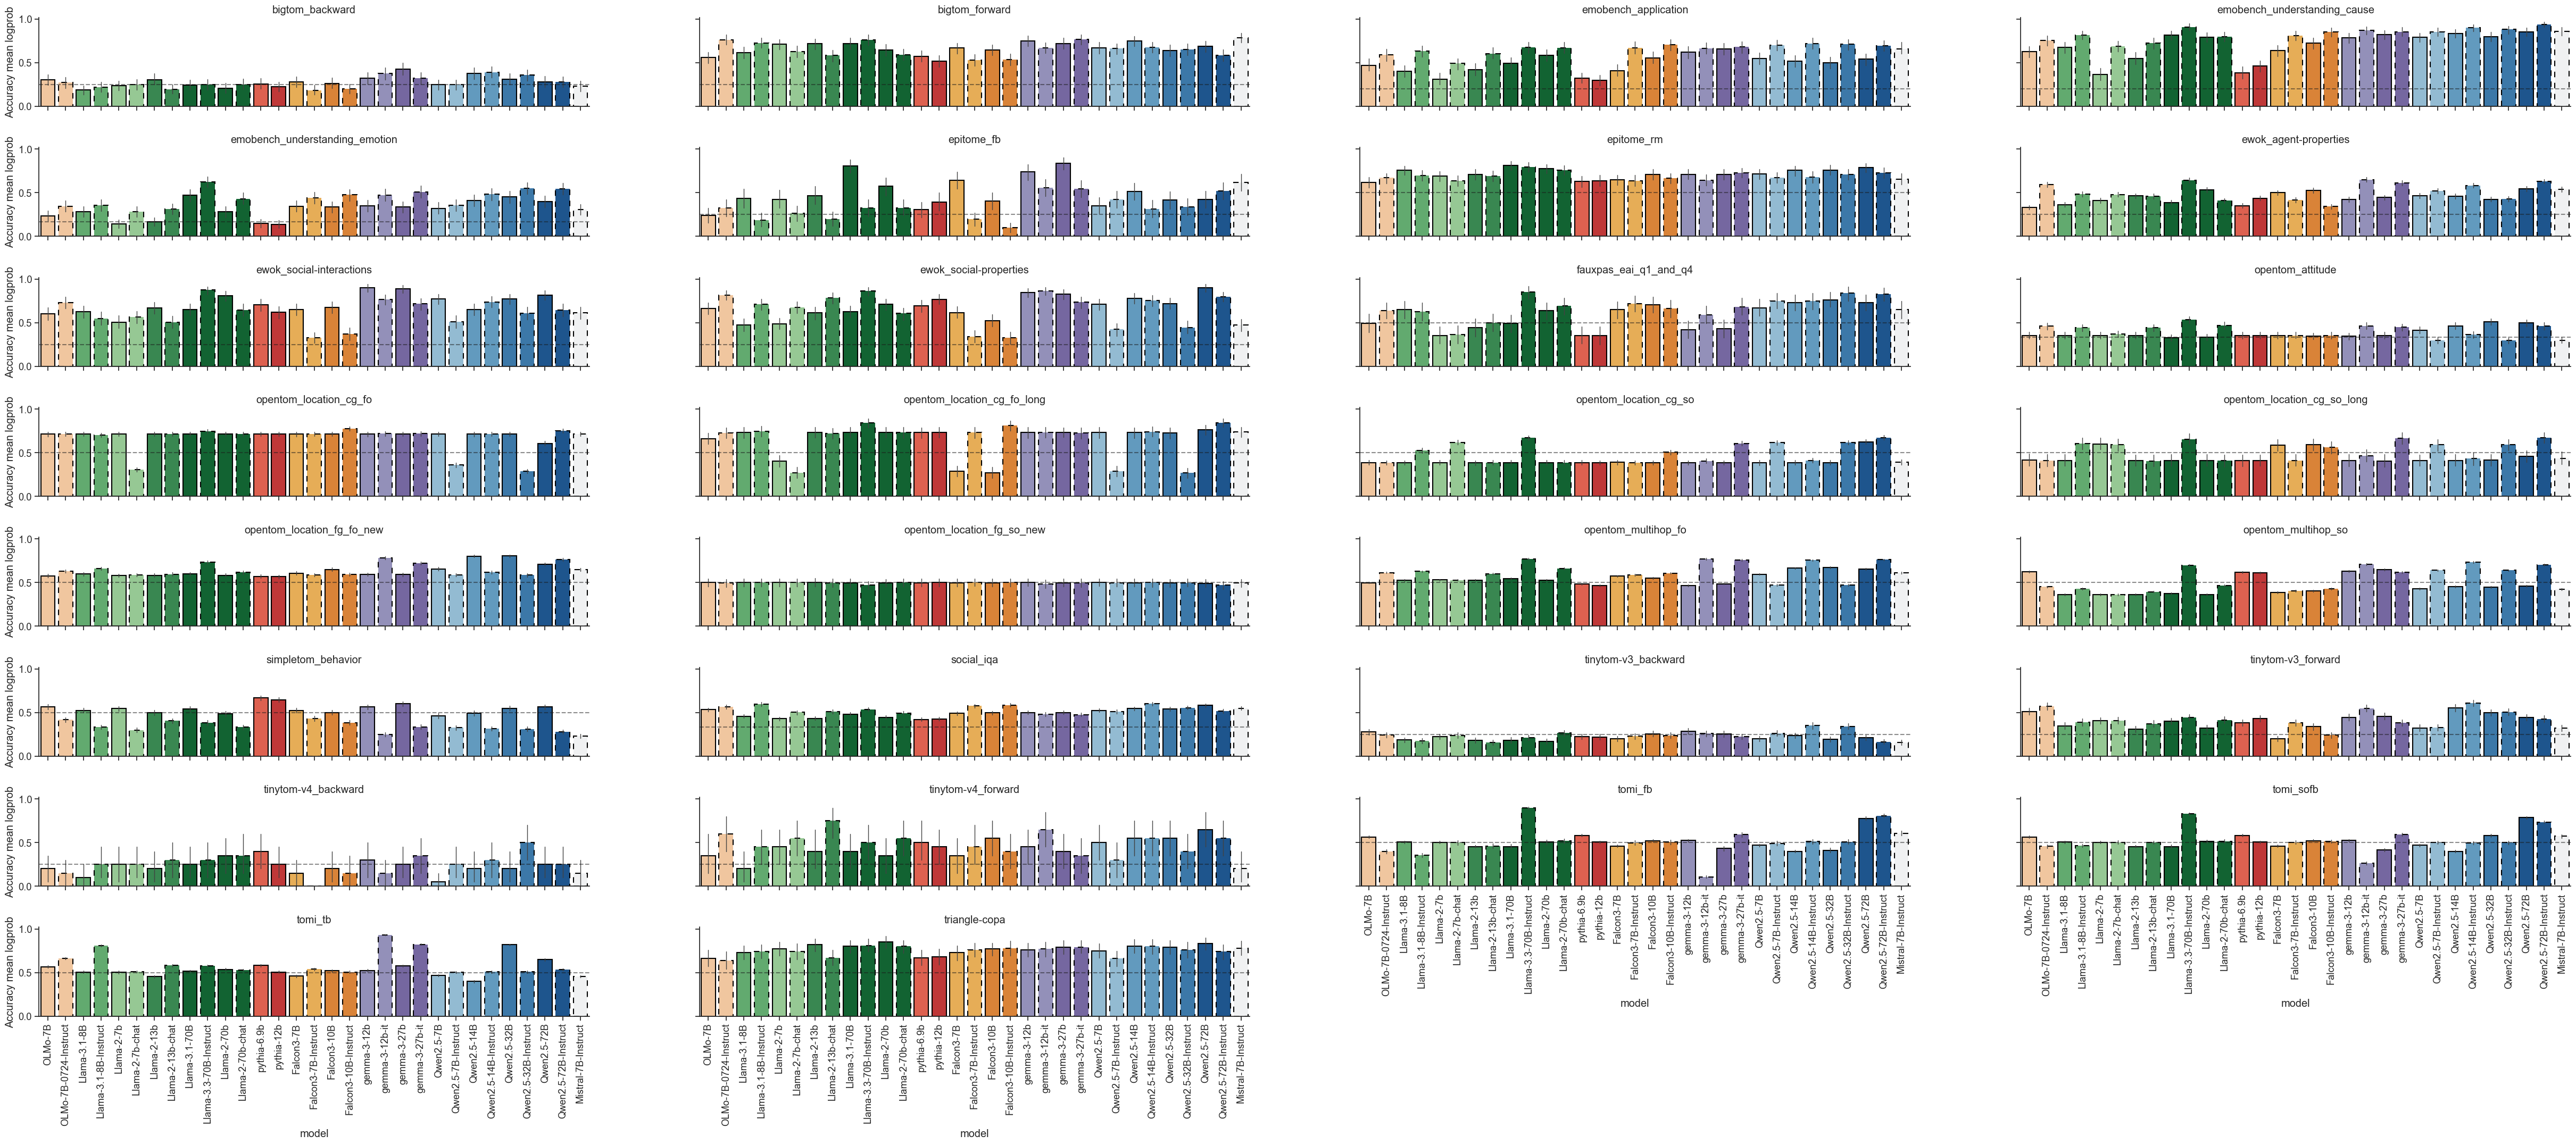

In [42]:
g = sns.catplot(
    data=big_models_tom, 
    x="model",
    y=f"model_correct_mean_logprob",
    # order=model_order, 
    hue="model",
    order=big_models,
    hue_order=big_models,
    palette=MODEL_PAL,
    col="dataset",
    col_wrap=4,
    kind="bar",
    height=2.5,
    aspect=5,
    err_kws={"lw": 1}
)
g.set_titles("{col_name}")
g.set_xticklabels([MODEL_MAP[m] for m in big_models], rotation=90) # MODEL_MAP.values() , ha="right" [MODEL_MAP[m] for m in MODELS]
g.set_ylabels(f"Accuracy mean logprob")
plt.subplots_adjust(wspace=0.2)

line_styles = {
    "base": (0, ()),          # solid
    "instruct": (0, (5, 5))      # dashed
}

# Ensure data includes "model_type"
if "model_type" not in big_models_tom.columns:
    raise ValueError("Data must include a 'model_type' column")

# # Loop through facets
# for ax in g.axes.flat:
model_order = big_models 
for i, ax in enumerate(g.axes):
    for j, bar in enumerate(ax.patches):  #for i, bar in enumerate(ax.patches):
        model_name = model_order[j % len(model_order)]
        # Get the model_type for this model
        model_type = big_models_tom.loc[big_models_tom["model"] == model_name, "model_type"].iloc[0]
        ls = line_styles.get(model_type, (0, ()))  # default solid
        bar.set_edgecolor("black")
        bar.set_linewidth(1.5)
        bar.set_linestyle(ls)

    if DATASETS_TOM[i] == "pub_indirectness_interpretation":
        continue
    chance = big_models_tom[big_models_tom["dataset"] == DATASETS_TOM[i]]["chance"].tolist()[0] 
    ax.axhline(chance, linestyle="--", color="k", alpha=0.5)

In [34]:
data_summary_big_models =  data_summary[data_summary["model"].isin(big_models)]
data_summary_big_models

,model,model_type,model_correct_mean_logprob_pragmatics,model_correct_mean_logprob_tom,avg_acc
1,EleutherAI/pythia-12b-deduped,base,0.531823,0.511799,0.521811
4,EleutherAI/pythia-6.9b-deduped,base,0.500093,0.536500,0.518296
9,Qwen/Qwen2.5-14B,base,0.622522,0.515757,0.56914
10,Qwen/Qwen2.5-14B-Instruct,instruct,0.600380,0.617132,0.608756
11,Qwen/Qwen2.5-32B,base,0.643506,0.593562,0.618534
12,Qwen/Qwen2.5-32B-Instruct,instruct,0.536826,0.519247,0.528036
15,Qwen/Qwen2.5-72B,base,0.641051,0.602979,0.622015
16,Qwen/Qwen2.5-72B-Instruct,instruct,0.686909,0.654799,0.670854
17,Qwen/Qwen2.5-7B,base,0.596350,0.501653,0.549002
18,Qwen/Qwen2.5-7B-Instruct,instruct,0.527747,0.514015,0.520881


/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_84618/4072152624.py:38: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(rect=[0, 0, 0.85, 1])  # leaves space for legend on the right


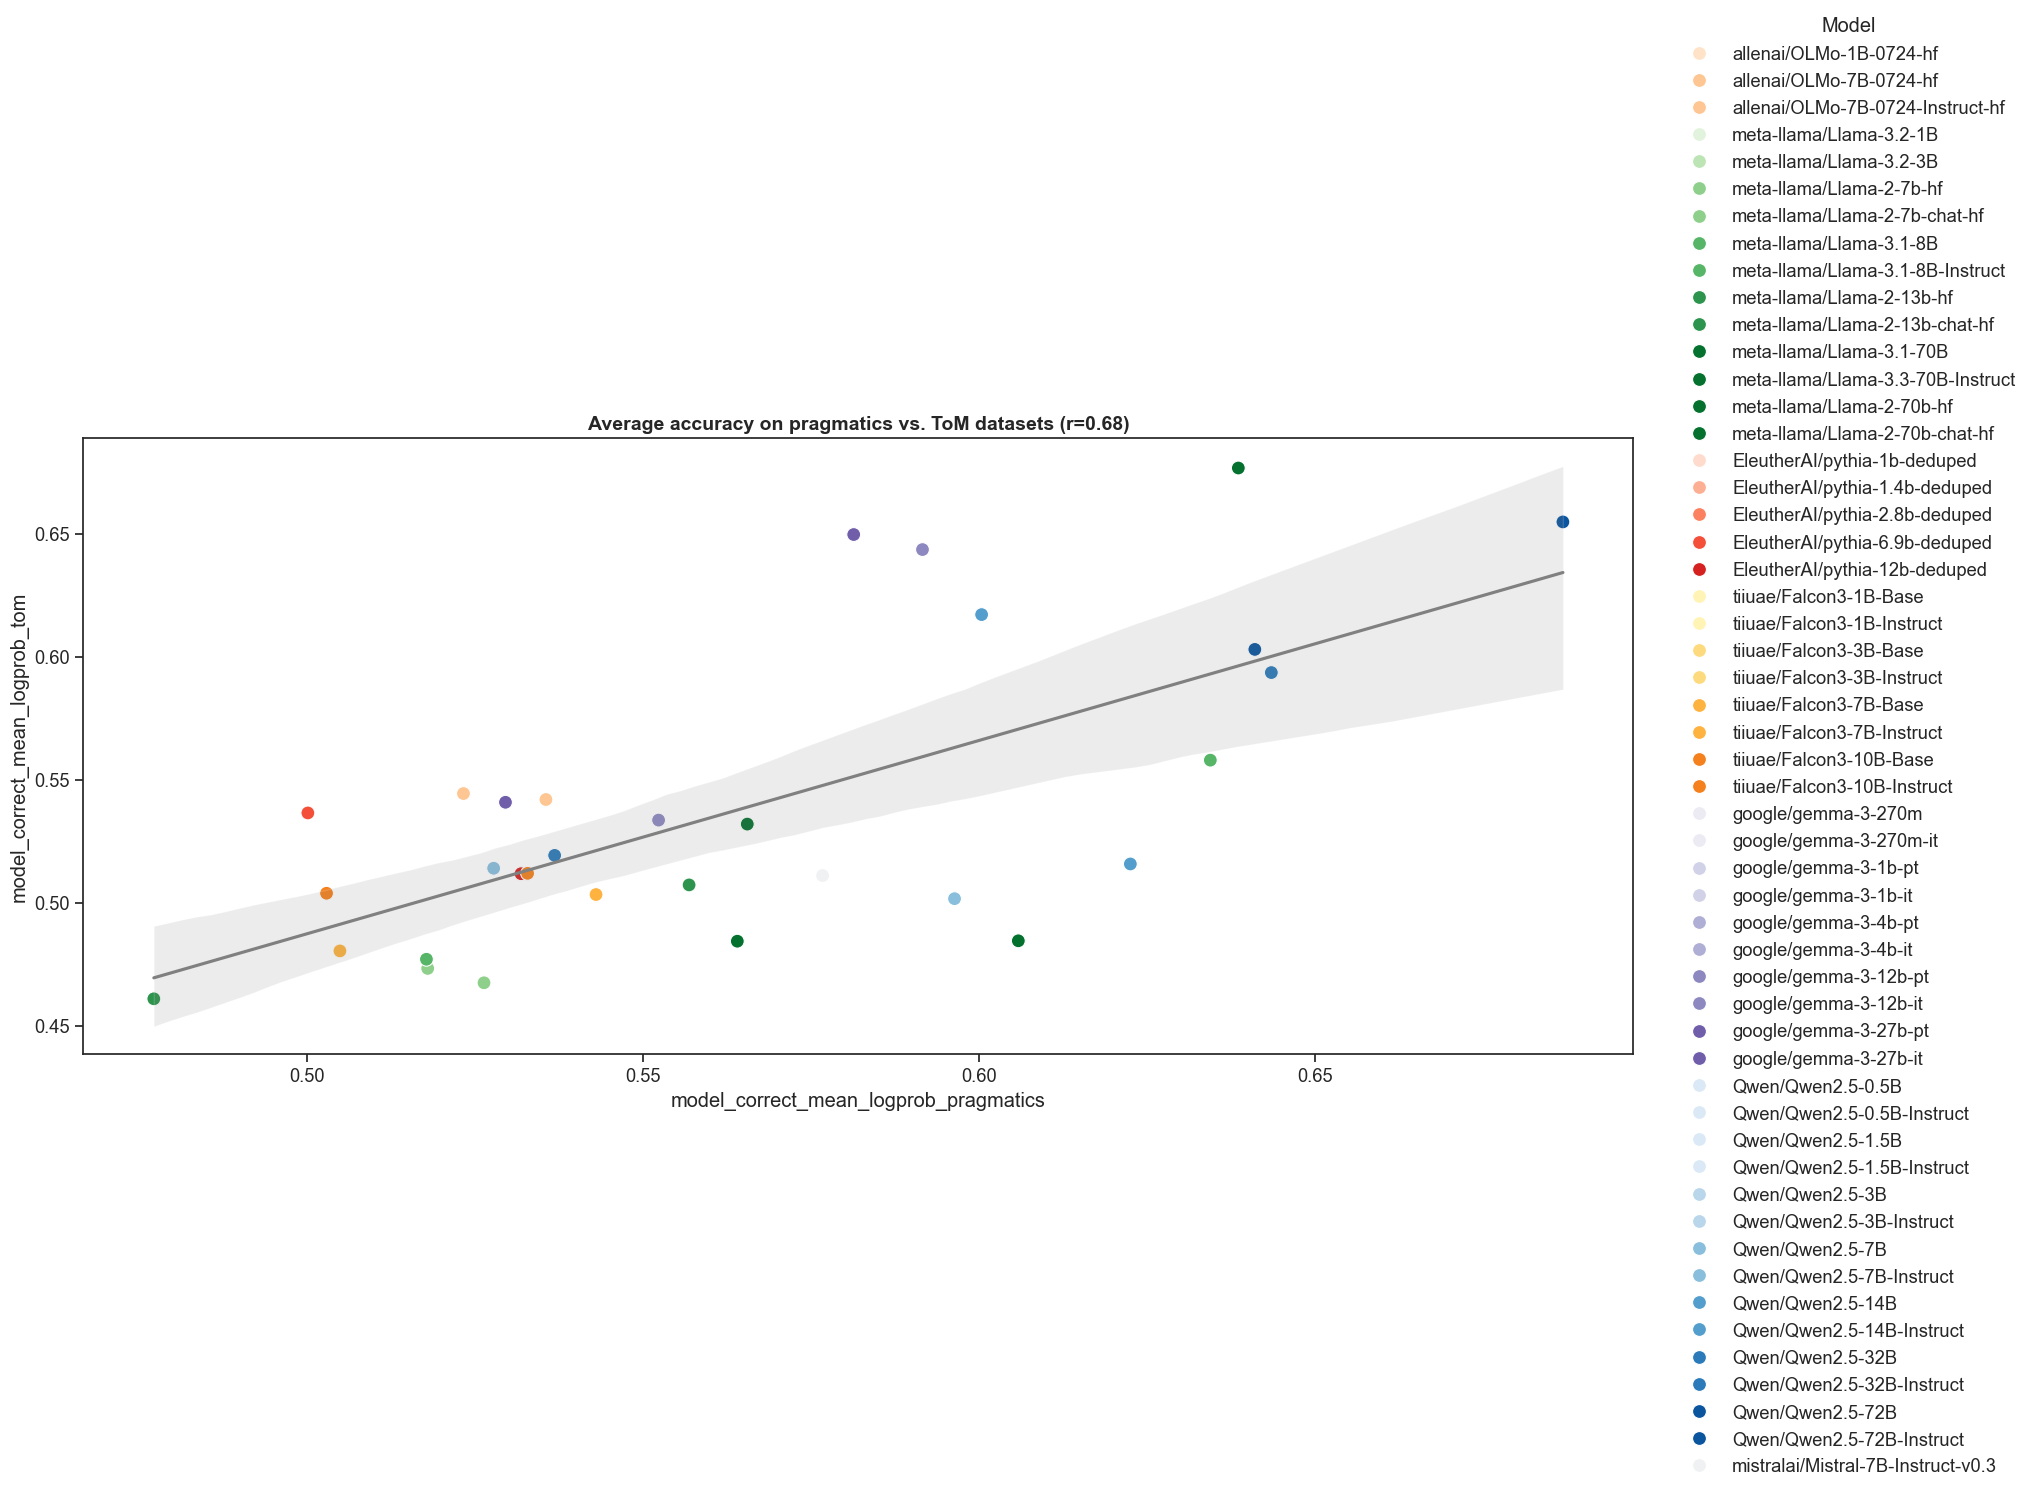

In [35]:
plt.figure(figsize=(20, 8))

g_prag_vs_tom_big = sns.scatterplot(
    data=data_summary_big_models, 
    x="model_correct_mean_logprob_pragmatics", 
    y="model_correct_mean_logprob_tom", 
    hue="model",
    hue_order=MODEL_PAL.keys(),
    palette=MODEL_PAL,
    s=100
)

# Add regression line
sns.regplot(
    data=data_summary_big_models, 
    x="model_correct_mean_logprob_pragmatics", 
    y="model_correct_mean_logprob_tom", 
    scatter=False, 
    ax=g_prag_vs_tom_big,
    color="gray"
)
# add correlation coefficient to title
corr = data_summary_big_models["model_correct_mean_logprob_pragmatics"].corr(data_summary_big_models["model_correct_mean_logprob_tom"])

# Move legend outside the main plot
sns.move_legend(
    g_prag_vs_tom_big,
    "center left",
    bbox_to_anchor=(1.02, 0.5),  # (x, y) offset relative to axes
    frameon=False,
    title="Model"
)

# Add title and adjust layout
# g_prag_vs_tom.set_title("Average accuracy on pragmatics vs. ToM datasets", fontsize=14, weight="bold")
g_prag_vs_tom_big.set_title(f"Average accuracy on pragmatics vs. ToM datasets (r={corr:.2f})", fontsize=14, weight="bold")

plt.tight_layout(rect=[0, 0, 0.85, 1])  # leaves space for legend on the right
plt.show()


In [36]:
scipy.stats.pearsonr(data_summary_big_models["model_correct_mean_logprob_pragmatics"], data_summary_big_models["model_correct_mean_logprob_tom"])

PearsonRResult(statistic=0.678569050371934, pvalue=2.7203428977436693e-05)

In [37]:
# look at correlation within big models when averaging accuracies only on datasets which are candidate for final selection.
selected_prag_datasets = ["imppres_implicature", "imppres_presupposition", "hufloyd_indirectspeech", "hufloyd_deceits", "ludwig", "pub_deictic_qa"]
selected_tom_datasets = ["bigtom_forward", 'tinytom-v3_forward',  'tinytom-v4_forward', 'emobench_application', 'emobench_understanding_cause', 'emobench_understanding_emotion', 'epitome_rm', 'epitome_fb', 'ewok_agent-properties',
 'ewok_social-interactions',
 'ewok_social-properties', 'opentom_location_cg_fo', 'opentom_location_cg_fo_long', 'opentom_location_fg_fo_new', 'social_iqa', 'triangle-copa']


# print the models with best performance on pragmatics
data_pragmatics_summary_selected_datasets = data_pragmatics_df[data_pragmatics_df["dataset"].isin(selected_prag_datasets)].groupby(["model", "model_type"]).agg({"model_correct_mean_logprob": "mean"}).reset_index()
print(data_pragmatics_summary_selected_datasets.sort_values(by="model_correct_mean_logprob", ascending=False)[:7])

# print the models with best performance on ToM
data_tom_summary_selected_datasets = data_tom_df[data_tom_df["dataset"].isin(selected_tom_datasets)].groupby(["model", "model_type"]).agg({"model_correct_mean_logprob": "mean"}).reset_index()
print(data_tom_summary_selected_datasets.sort_values(by="model_correct_mean_logprob", ascending=False)[:7])

data_pragmatics_summary_selected_datasets = data_pragmatics_summary_selected_datasets[data_pragmatics_summary_selected_datasets["model"].isin(big_models)]
data_tom_summary_selected_datasets = data_tom_summary_selected_datasets[data_tom_summary_selected_datasets["model"].isin(big_models)]
# get models with highest performance on both
data_summary_selected_datasets = pd.merge(
    data_pragmatics_summary_selected_datasets,
    data_tom_summary_selected_datasets,
    on=["model", "model_type"],
    how="inner",
    suffixes=["_pragmatics", "_tom"]
).reset_index()
data_summary_selected_datasets["avg_acc"] = data_summary_selected_datasets[["model_correct_mean_logprob_tom", "model_correct_mean_logprob_pragmatics"]].mean(axis=1)

data_summary_selected_datasets["model_correct_mean_logprob_pragmatics"] = pd.to_numeric(
    data_summary_selected_datasets["model_correct_mean_logprob_pragmatics"], errors="coerce"
)
data_summary_selected_datasets["model_correct_mean_logprob_tom"] = pd.to_numeric(
    data_summary_selected_datasets["model_correct_mean_logprob_tom"], errors="coerce"
)
data_summary_selected_datasets = data_summary_selected_datasets.dropna(subset=[
    "model_correct_mean_logprob_pragmatics",
    "model_correct_mean_logprob_tom"
])

data_summary_selected_datasets.sort_values(by=["avg_acc"], ascending=False)[:7]

                                model model_type  model_correct_mean_logprob
43  meta-llama/Llama-3.3-70B-Instruct   instruct                    0.681531
16          Qwen/Qwen2.5-72B-Instruct   instruct                    0.669796
34     meta-llama/Llama-2-70b-chat-hf   instruct                    0.651201
10          Qwen/Qwen2.5-14B-Instruct   instruct                    0.649215
12          Qwen/Qwen2.5-32B-Instruct   instruct                    0.643437
28              google/gemma-3-27b-it   instruct                    0.616898
22              google/gemma-3-12b-it   instruct                    0.614551
                                model model_type model_correct_mean_logprob
43  meta-llama/Llama-3.3-70B-Instruct   instruct                   0.667253
22              google/gemma-3-12b-it   instruct                   0.659778
16          Qwen/Qwen2.5-72B-Instruct   instruct                   0.658569
9                    Qwen/Qwen2.5-14B       base                   0.650984
11  

,index,model,model_type,model_correct_mean_logprob_pragmatics,model_correct_mean_logprob_tom,avg_acc
25,25,meta-llama/Llama-3.3-70B-Instruct,instruct,0.681531,0.667253,0.674392
7,7,Qwen/Qwen2.5-72B-Instruct,instruct,0.669796,0.658569,0.664182
3,3,Qwen/Qwen2.5-14B-Instruct,instruct,0.649215,0.636583,0.642899
12,12,google/gemma-3-12b-it,instruct,0.614551,0.659778,0.637165
14,14,google/gemma-3-27b-it,instruct,0.616898,0.627130,0.622014
4,4,Qwen/Qwen2.5-32B,base,0.585304,0.639552,0.612428
18,18,meta-llama/Llama-2-70b-chat-hf,instruct,0.651201,0.568649,0.609925


In [38]:
# calculate correlation with p value
print(scipy.stats.pearsonr(data_summary_selected_datasets["model_correct_mean_logprob_pragmatics"], data_summary_selected_datasets["model_correct_mean_logprob_tom"]))

PearsonRResult(statistic=0.2932102769426582, pvalue=0.1094102067748977)


In [17]:
# TODO:
# - do analyses that take into account our annotation dimensions
DATASETS_TOM

['bigtom_backward',
 'bigtom_forward',
 'emobench_application',
 'emobench_understanding_cause',
 'emobench_understanding_emotion',
 'epitome_fb',
 'epitome_rm',
 'ewok_agent-properties',
 'ewok_social-interactions',
 'ewok_social-properties',
 'fauxpas_eai_q1_and_q4',
 'opentom_attitude',
 'opentom_location_cg_fo',
 'opentom_location_cg_fo_long',
 'opentom_location_cg_so',
 'opentom_location_cg_so_long',
 'opentom_location_fg_fo_new',
 'opentom_location_fg_so_new',
 'opentom_multihop_fo',
 'opentom_multihop_so',
 'simpletom_behavior',
 'social_iqa',
 'tinytom-v3_backward',
 'tinytom-v3_forward',
 'tinytom-v4_backward',
 'tinytom-v4_forward',
 'tomi_fb',
 'tomi_sofb',
 'tomi_tb',
 'triangle-copa']

### PCA analysis

In [97]:
# represent each model as a vector of accuracies on all the datasets
data_all = pd.concat([data_tom_df, data_pragmatics_df])

summary_byModel_byDataset = data_all.groupby(["model", "dataset"]).agg({"model_correct_mean_logprob": "mean"})
# pivot to wide (by model) 
# Reset index and rename the dataset column
model_vectors = summary_byModel_byDataset.unstack(level="dataset")
model_vectors.columns = model_vectors.columns.droplevel(0)
model_vectors = model_vectors.reset_index().rename(columns={"model": "model"})

# Ensure the DataFrame itself has no name (optional but explicit)
model_vectors.name = None
model_vectors

dataset,model,bigtom_backward,bigtom_forward,emobench_application,emobench_understanding_cause,emobench_understanding_emotion,epitome_fb,epitome_rm,epitome_si,ewok_agent-properties,...,simpletom_behavior,social_iqa,tinytom-v3_backward,tinytom-v3_forward,tinytom-v4_backward,tinytom-v4_forward,tomi_fb,tomi_sofb,tomi_tb,triangle-copa
0,EleutherAI/pythia-1.4b-deduped,0.190955,0.38806,0.295,0.36,0.145,0.336957,0.580357,0.0,0.316964,...,0.63034,0.41321,0.189736,0.261275,0.2,0.2,0.532032,0.532032,0.532032,0.59
1,EleutherAI/pythia-12b-deduped,0.226131,0.517413,0.3,0.46,0.135,0.391304,0.638393,0.0,0.435714,...,0.646033,0.425499,0.22084,0.432348,0.25,0.45,0.506006,0.506006,0.506006,0.68
2,EleutherAI/pythia-1b-deduped,0.281407,0.507463,0.285,0.395,0.135,0.467391,0.558036,0.0,0.244643,...,0.654752,0.410138,0.228616,0.354588,0.4,0.3,0.527778,0.527778,0.527778,0.61
3,EleutherAI/pythia-2.8b-deduped,0.165829,0.517413,0.25,0.475,0.15,0.173913,0.620536,0.0,0.344643,...,0.647777,0.413722,0.255054,0.339036,0.35,0.25,0.528779,0.528779,0.528779,0.66
4,EleutherAI/pythia-6.9b-deduped,0.256281,0.572139,0.325,0.385,0.15,0.304348,0.629464,0.0,0.349107,...,0.667829,0.421915,0.222395,0.381026,0.4,0.5,0.581331,0.581331,0.581331,0.67
5,Qwen/Qwen2.5-0.5B,0.145729,0.467662,0.36,0.565,0.165,0.26087,0.566964,0.058824,0.198214,...,0.499564,0.444956,0.155521,0.304821,0.25,0.2,0.386887,0.386887,0.386887,0.61
6,Qwen/Qwen2.5-0.5B-Instruct,0.21608,0.393035,0.44,0.51,0.235,0.206522,0.544643,0.088235,0.240179,...,0.3932,0.505888,0.150855,0.096423,0.25,0.1,0.503077,0.496658,0.509587,0.68
7,Qwen/Qwen2.5-1.5B,0.18593,0.432836,0.42,0.64,0.28,0.195652,0.65625,0.029412,0.304464,...,0.442023,0.485407,0.166407,0.306376,0.2,0.2,0.53954,0.53954,0.53954,0.63
8,Qwen/Qwen2.5-1.5B-Instruct,0.105528,0.20398,0.58,0.705,0.29,0.141304,0.629464,0.0,0.36875,...,0.294682,0.529442,0.096423,0.230171,0.2,0.15,0.500769,0.52005,0.494887,0.68
9,Qwen/Qwen2.5-14B,0.376884,0.751244,0.52,0.835,0.41,0.51087,0.754464,0.0,0.459821,...,0.491718,0.544803,0.236392,0.553655,0.2,0.55,0.397898,0.397898,0.397898,0.8


/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_28082/2815486907.py:41: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


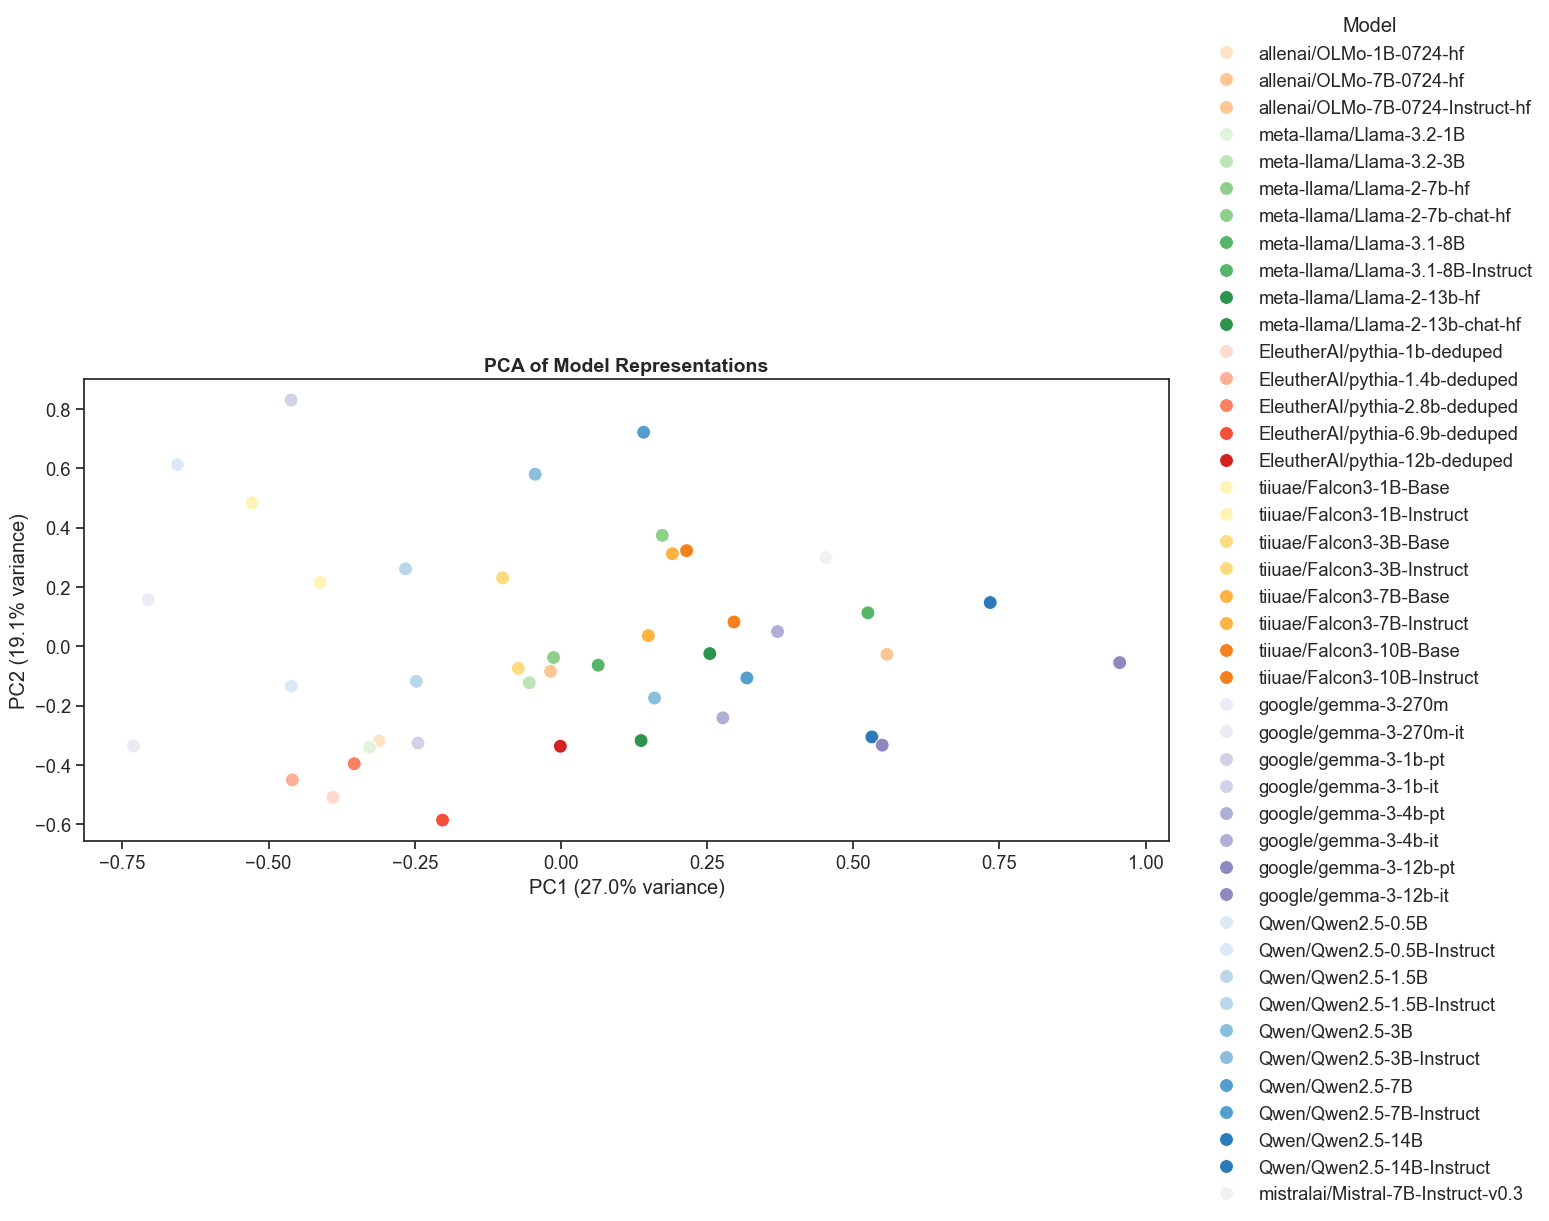

In [98]:
# apply PCA to the model vector representations
from sklearn.decomposition import PCA

X = model_vectors.drop(columns=["model"])

pca = PCA(n_components=2)
components = pca.fit_transform(X)

# Create a DataFrame for plotting
pca_df = pd.DataFrame(components, columns=["PC1", "PC2"])
models = model_vectors["model"]
pca_df["model"] = models

plt.figure(figsize=(14, 6))
g_pca= sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="model",
    hue_order=MODEL_PAL.keys(),
    palette=MODEL_PAL,
    s=100,
    edgecolor="white",
    linewidth=0.7
)

sns.move_legend(
    g_pca,
    "center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    title="Model"
)

# Labels and title
g_pca.set_title("PCA of Model Representations", fontsize=14, weight="bold")
g_pca.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
g_pca.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")

# Adjust layout so legend doesn’t overlap
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_28082/3811273629.py:52: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


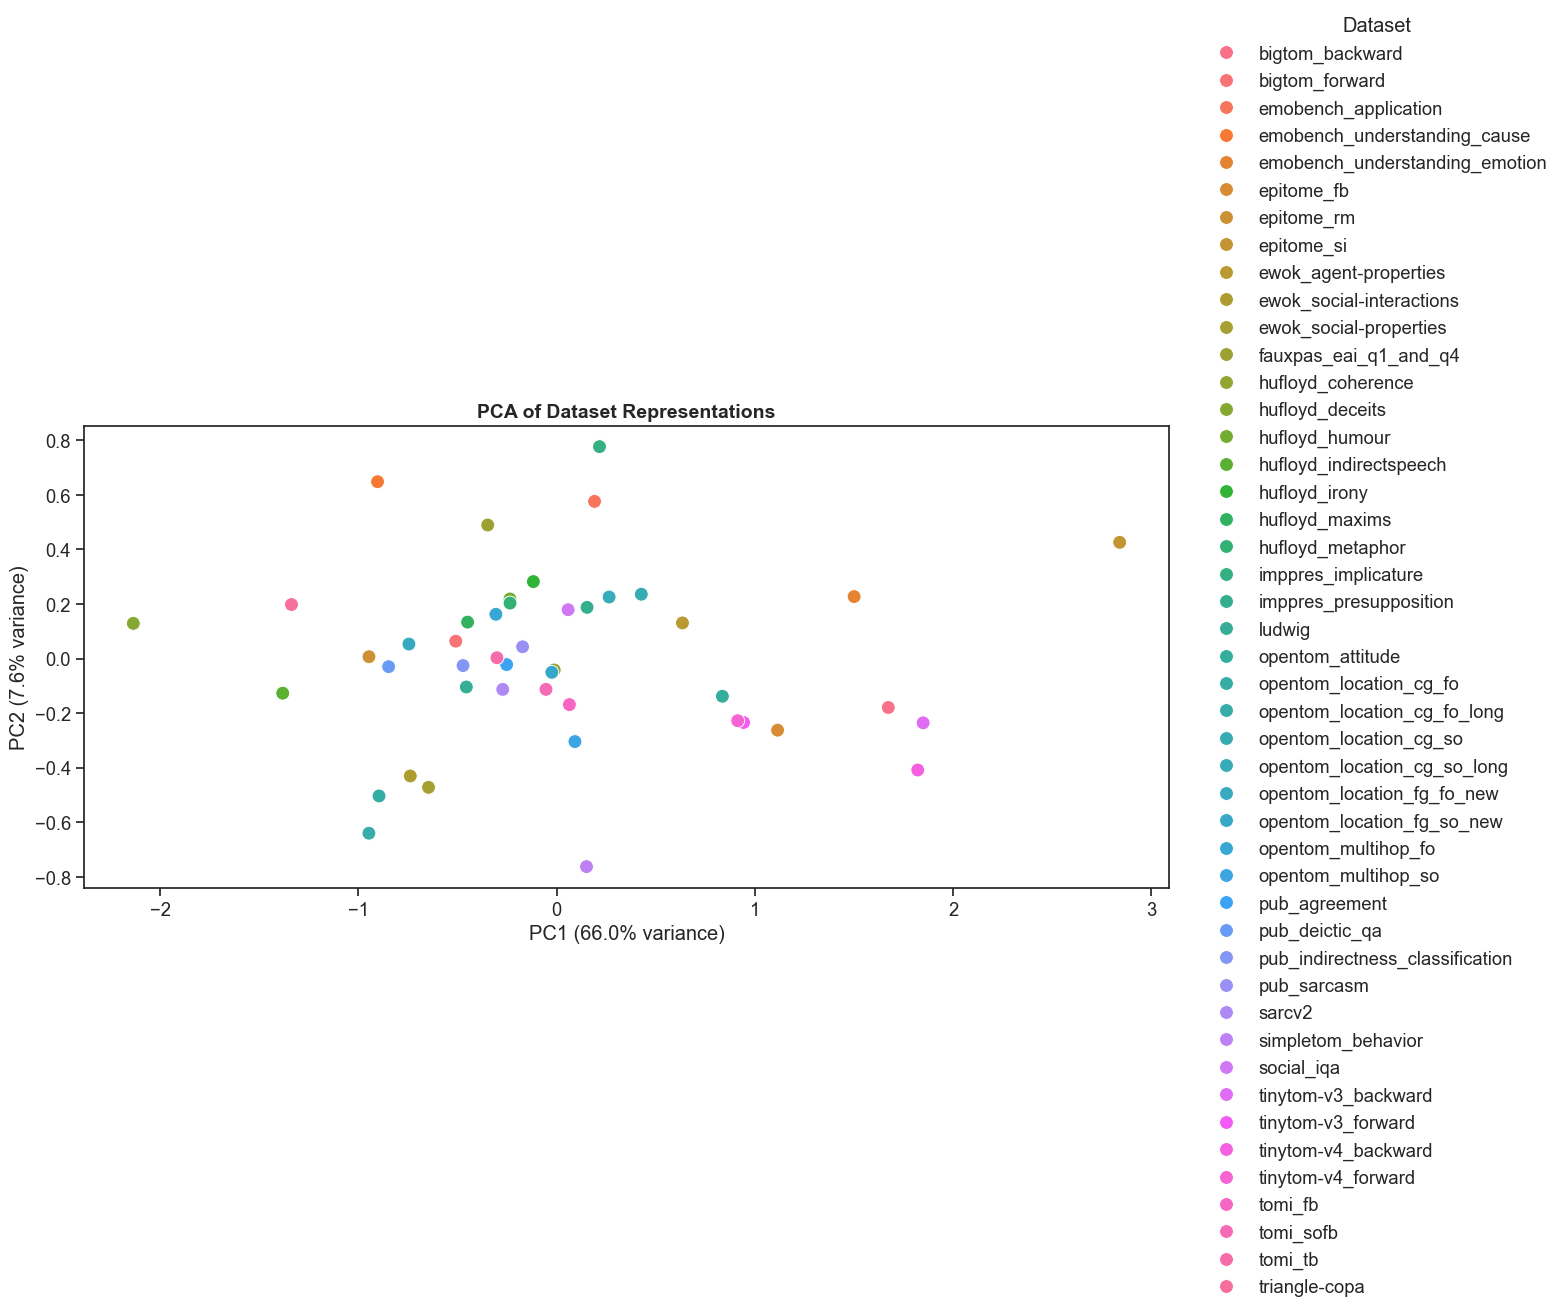

In [99]:
# same analysis, but we represent each dataset as a vector of accuracies across models and 
# we color them by task

# represent each dataset as a vector of accuracies of all models
# pivot to wide (by dataset) 
# Reset index and rename the dataset column
dataset_vectors = summary_byModel_byDataset.unstack(level="model")
dataset_vectors.columns = dataset_vectors.columns.droplevel(0)
dataset_vectors = dataset_vectors.reset_index().rename(columns={"dataset": "dataset"})

# Ensure the DataFrame itself has no name (optional but explicit)
dataset_vectors.name = None
dataset_vectors

X_ds = dataset_vectors.drop(columns=["dataset"])

pca_ds = PCA(n_components=2)
components_ds = pca_ds.fit_transform(X_ds)

# Create a DataFrame for plotting
pca_ds_df = pd.DataFrame(components_ds, columns=["PC1", "PC2"])
datasets = dataset_vectors["dataset"]
pca_ds_df["dataset"] = datasets

plt.figure(figsize=(14, 6))
g_pca_ds= sns.scatterplot(
    data=pca_ds_df,
    x="PC1",
    y="PC2",
    hue="dataset",
    # hue_order=MODEL_PAL.keys(),
    # palette=MODEL_PAL,
    s=100,
    edgecolor="white",
    linewidth=0.7
)

sns.move_legend(
    g_pca_ds,
    "center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    title="Dataset"
)

# Labels and title
g_pca_ds.set_title("PCA of Dataset Representations", fontsize=14, weight="bold")
g_pca_ds.set_xlabel(f"PC1 ({pca_ds.explained_variance_ratio_[0]*100:.1f}% variance)")
g_pca_ds.set_ylabel(f"PC2 ({pca_ds.explained_variance_ratio_[1]*100:.1f}% variance)")

# Adjust layout so legend doesn’t overlap
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

### Correlations

In [100]:
# calculate omnibus pearson correlation

unique_datasets = data_all["dataset"].unique()

In [101]:
len(data_all["model"].unique())

43

In [102]:
omnibus_corr_table = pd.DataFrame(columns=["dataset_1", "dataset_2", "pearson_corr", "num_used_models_pearson", "spearman_corr", "num_used_models_spearman"]) 

for d1 in unique_datasets:
   for d2 in unique_datasets: 
        print(f"D1: {d1}, D2: {d2}")
        ds1 = data_all[data_all["dataset"] == d1]
        ds2 = data_all[data_all["dataset"] == d2]
        ds1_acc = ds1.groupby("model")["model_correct_mean_logprob"].mean().reset_index()
        ds2_acc = ds2.groupby("model")["model_correct_mean_logprob"].mean().reset_index()
        # exclude zero accuracy models
        ds1_acc_nonzero = ds1_acc[ds1_acc["model_correct_mean_logprob"] > 0]
        ds2_acc_nonzero = ds2_acc[ds2_acc["model_correct_mean_logprob"] > 0]
        ds1_nonzero_models = ds1_acc_nonzero["model"].unique()
        ds2_nonzero_models = ds2_acc_nonzero["model"].unique()
        # print("D1 non zero models ", ds1_nonzero_models)
        # print("D2 non zero models ", ds2_nonzero_models)
        
        ds1_acc_nonzero = ds1_acc_nonzero[ds1_acc_nonzero["model"].isin(ds2_nonzero_models)]
        ds2_acc_nonzero = ds2_acc_nonzero[ds2_acc_nonzero["model"].isin(ds1_nonzero_models)]
        # print(ds1_acc_nonzero.head())
        
        corr_pearson = ds1_acc_nonzero["model_correct_mean_logprob"].corr(ds2_acc_nonzero["model_correct_mean_logprob"])
        num_used_models = len(ds1_acc_nonzero)
        # TODO: I think this can also include 0 accuracy cases
        corr_spearman = scipy.stats.spearmanr(ds1_acc_nonzero["model_correct_mean_logprob"], ds2_acc_nonzero["model_correct_mean_logprob"]).correlation

        omnibus_corr_table = pd.concat([omnibus_corr_table, pd.DataFrame([
            {
            "dataset_1": d1,
            "dataset_2": d2,
            "pearson_corr": corr_pearson if not np.isnan(corr_pearson) else None,
            "num_used_models_pearson": num_used_models,
            "spearman_corr": corr_spearman if not np.isnan(corr_spearman) else None,
            "num_used_models_spearman": len(ds1_acc)
        }
        ])], ignore_index=True)


D1: bigtom_backward, D2: bigtom_backward
D1: bigtom_backward, D2: bigtom_forward


/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_28082/1901501398.py:27: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  omnibus_corr_table = pd.concat([omnibus_corr_table, pd.DataFrame([


D1: bigtom_backward, D2: emobench_application
D1: bigtom_backward, D2: emobench_understanding_cause
D1: bigtom_backward, D2: emobench_understanding_emotion
D1: bigtom_backward, D2: epitome_fb
D1: bigtom_backward, D2: epitome_rm
D1: bigtom_backward, D2: ewok_agent-properties
D1: bigtom_backward, D2: ewok_social-interactions
D1: bigtom_backward, D2: ewok_social-properties
D1: bigtom_backward, D2: fauxpas_eai_q1_and_q4
D1: bigtom_backward, D2: opentom_attitude
D1: bigtom_backward, D2: opentom_location_cg_fo
D1: bigtom_backward, D2: opentom_location_cg_fo_long
D1: bigtom_backward, D2: opentom_location_cg_so
D1: bigtom_backward, D2: opentom_location_cg_so_long
D1: bigtom_backward, D2: opentom_location_fg_fo_new
D1: bigtom_backward, D2: opentom_location_fg_so_new
D1: bigtom_backward, D2: opentom_multihop_fo
D1: bigtom_backward, D2: opentom_multihop_so
D1: bigtom_backward, D2: simpletom_behavior
D1: bigtom_backward, D2: social_iqa
D1: bigtom_backward, D2: tinytom-v3_backward
D1: bigtom_backwa

In [103]:
omnibus_corr_table[omnibus_corr_table["pearson_corr"].isna()]
omnibus_corr_table["num_used_models_pearson"].value_counts()

num_used_models_pearson
43    1849
42     174
15      89
41       2
14       2
Name: count, dtype: int64

In [104]:
omnibus_corr_table_cleaned = omnibus_corr_table[~omnibus_corr_table["pearson_corr"].isna()]
omnibus_corr_table_cleaned = omnibus_corr_table_cleaned[omnibus_corr_table_cleaned["num_used_models_pearson"] > 4]

In [105]:
# get dataset pairs with highest Pearson correlations
highest_corrs = omnibus_corr_table_cleaned[omnibus_corr_table_cleaned["dataset_1"] != omnibus_corr_table_cleaned["dataset_2"]].drop_duplicates()
highest_corrs["pair"] = highest_corrs.apply(lambda row: tuple(sorted([row["dataset_1"], row["dataset_2"]])), axis=1)
# Drop duplicates 
highest_corrs = highest_corrs.drop_duplicates(["pair", "pearson_corr", "spearman_corr"]).drop(columns="pair")
highest_corrs.sort_values(by="pearson_corr", ascending=False)[:10]

,dataset_1,dataset_2,pearson_corr,num_used_models_pearson,spearman_corr,num_used_models_spearman
140,emobench_understanding_cause,emobench_application,0.895068,43,0.904744,43
95,emobench_application,emobench_understanding_cause,0.895068,43,0.904744,43
187,emobench_understanding_emotion,emobench_understanding_cause,0.894647,43,0.929589,43
142,emobench_understanding_cause,emobench_understanding_emotion,0.894647,43,0.929589,43
96,emobench_application,emobench_understanding_emotion,0.872450,43,0.881297,43
186,emobench_understanding_emotion,emobench_application,0.872450,43,0.881297,43
113,emobench_application,social_iqa,0.851492,43,0.858017,43
970,social_iqa,emobench_understanding_emotion,0.828206,43,0.841602,43
205,emobench_understanding_emotion,social_iqa,0.828206,43,0.841602,43
308,epitome_rm,hufloyd_deceits,0.819277,43,0.837936,43


In [335]:
highest_corrs.groupby("dataset_1").agg({"pearson_corr": ["mean", "std"]}).sort_values(by=("pearson_corr", "mean"), ascending=False)

pearson_corr          
                                        mean       std
dataset_1                                             
triangle-copa                       0.345692  0.302319
hufloyd_deceits                     0.272936  0.204958
ewok_agent-properties               0.244294  0.307261
bigtom_forward                      0.225717  0.289691
pub_agreement                       0.207112  0.617411
emobench_application                0.191947  0.370552
tinytom-v4_forward                  0.186441  0.249774
hufloyd_metaphor                    0.184244  0.189478
hufloyd_humour                      0.178657  0.252345
emobench_understanding_cause        0.177534  0.404434
hufloyd_irony                       0.173755  0.264391
pub_sarcasm                         0.158121       NaN
ewok_social-properties              0.148738  0.238600
bigtom_backward                     0.141098  0.235527
ewok_social-interactions            0.138715  0.225253
tinytom-v3_forward                  0.114089  0.244081
hufloyd_maxims                      0.113390  0.289586
emobench_understanding_emotion      0.097343  0.338812
social_iqa                          0.097196  0.288709
epitome_rm                          0.089321  0.280380
opentom_attitude                    0.088979  0.343435
pub_indirectness_classification     0.088337  0.211036
tomi_fb                             0.074448  0.377029
epitome_fb                          0.065498  0.255828
ludwig                              0.043433  0.275039
fauxpas_eai_q1_and_q4               0.042309  0.295414
opentom_location_fg_fo_new          0.037335  0.394815
hufloyd_indirectspeech              0.035748  0.312145
hufloyd_coherence                   0.024211  0.174935
opentom_multihop_so                 0.021378  0.374721
tomi_sofb                           0.020003  0.307157
opentom_location_fg_so_new          0.016058  0.252799
opentom_location_cg_so_long         0.000125  0.195186
tinytom-v3_backward                -0.000447  0.266425
opentom_multihop_fo                -0.001981  0.429768
opentom_location_cg_so             -0.012994  0.256246
imppres_implicature                -0.015563  0.223707
opentom_location_cg_fo             -0.016567  0.276845
opentom_location_cg_fo_long        -0.020468  0.276366
tomi_tb                            -0.041247  0.180575
imppres_presupposition             -0.053141  0.337115
simpletom_behavior                 -0.082677  0.346618
tinytom-v4_backward                -0.168893  0.254573
pub_deictic_qa                     -0.332670  0.052542

In [349]:
highest_corrs.groupby("dataset_2").agg({"pearson_corr": ["mean", "std"]}).sort_values(by=("pearson_corr", "mean"), ascending=False)

pearson_corr          
                                        mean       std
dataset_2                                             
bigtom_forward                      0.297061  0.283307
ewok_agent-properties               0.267501  0.301995
emobench_understanding_cause        0.224814  0.350851
tinytom-v4_forward                  0.212247  0.266911
triangle-copa                       0.209107  0.337978
opentom_attitude                    0.197269  0.356839
epitome_rm                          0.196588  0.247650
hufloyd_metaphor                    0.188489  0.289109
social_iqa                          0.184018  0.351353
opentom_location_fg_fo_new          0.182199  0.369984
pub_sarcasm                         0.169452  0.351700
ewok_social-properties              0.160682  0.253778
hufloyd_deceits                     0.155835  0.254614
tinytom-v3_forward                  0.153832  0.243617
pub_agreement                       0.150554  0.304233
emobench_understanding_emotion      0.143570  0.379945
hufloyd_indirectspeech              0.141593  0.254861
hufloyd_maxims                      0.139406  0.254540
emobench_application                0.127390  0.348436
opentom_multihop_fo                 0.125646  0.420165
bigtom_backward                     0.123781  0.235593
hufloyd_irony                       0.119051  0.331338
ewok_social-interactions            0.114685  0.221740
sarcv2                              0.114319  0.291868
hufloyd_humour                      0.104408  0.258850
imppres_implicature                 0.091496  0.213946
ludwig                              0.090804  0.215203
tomi_tb                             0.086032  0.282966
opentom_location_fg_so_new          0.062672  0.270904
tomi_sofb                           0.061981  0.243028
fauxpas_eai_q1_and_q4               0.056919  0.294827
tomi_fb                             0.036629  0.188684
hufloyd_coherence                   0.028360  0.180371
opentom_location_cg_fo_long         0.019595  0.209179
epitome_fb                          0.019192  0.233504
opentom_location_cg_fo              0.018516  0.253259
opentom_location_cg_so_long         0.004272  0.245019
tinytom-v3_backward                -0.017572  0.308476
pub_indirectness_classification    -0.053691  0.259820
opentom_location_cg_so             -0.071336  0.286828
opentom_multihop_so                -0.088074  0.376115
imppres_presupposition             -0.090537  0.214781
pub_deictic_qa                     -0.142736  0.257328
tinytom-v4_backward                -0.149964  0.381989
simpletom_behavior                 -0.258287  0.371876

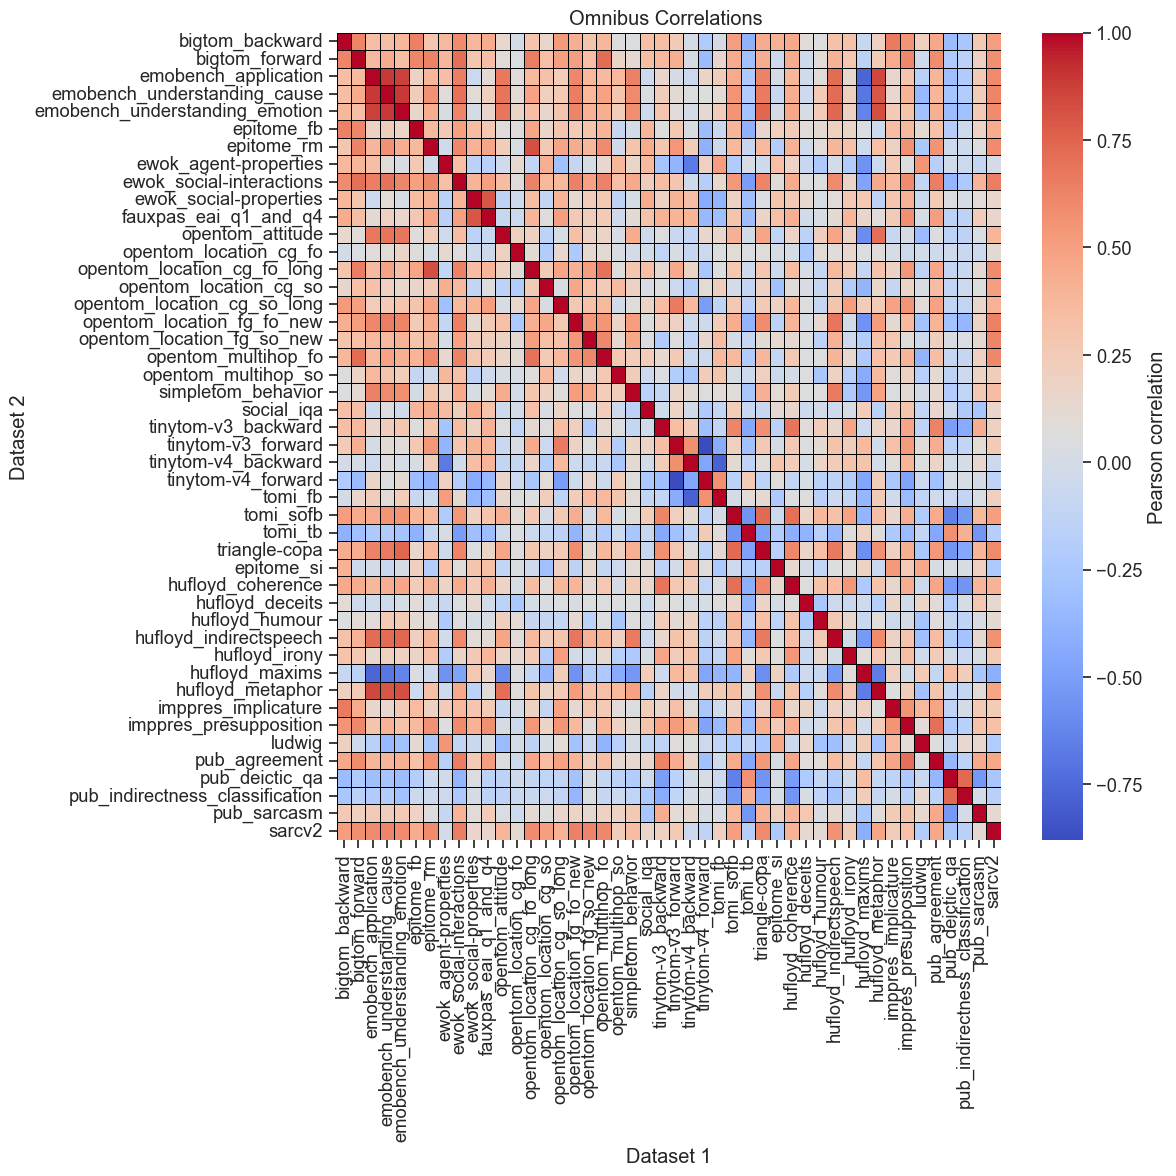

In [106]:
# tom_datasets= corr_table_nonEmpty["dataset_tom"].unique()
# tom_categories = corr_table_nonEmpty["tom_category"].unique()
# pragmatics_datasets = corr_table_nonEmpty["dataset_pragmatics"].unique()    
corr_matrix = omnibus_corr_table_cleaned.pivot(index="dataset_1", columns="dataset_2", values="pearson_corr")

plt.figure(figsize=(12, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", cbar_kws={"label": "Pearson correlation"}, # annot=True, fmt=".2f"
            xticklabels=omnibus_corr_table_cleaned["dataset_1"].unique(), 
            yticklabels=omnibus_corr_table_cleaned["dataset_1"].unique(),
            linewidths=0.5, linecolor='black')
plt.title("Omnibus Correlations ")
plt.xlabel("Dataset 1")
plt.ylabel("Dataset 2")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [108]:
# omnibus_corr_table[omnibus_corr_table["spearman_corr"].isna()]
# omnibus_corr_table["num_used_models_spearman"].value_counts()
omnibus_corr_table_cleaned_spearman = omnibus_corr_table[~omnibus_corr_table["spearman_corr"].isna()]

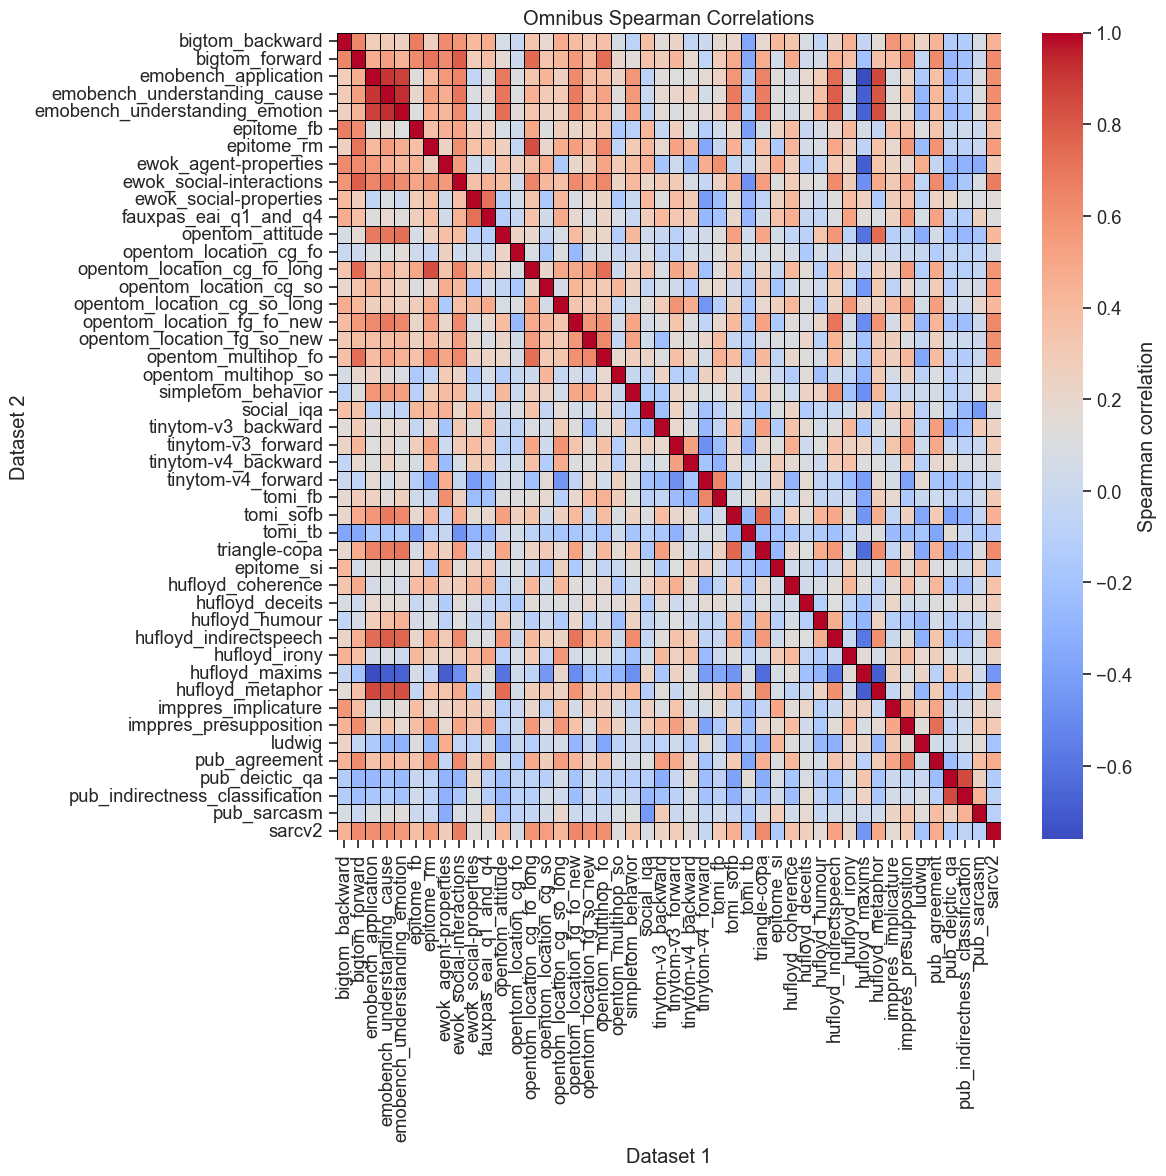

In [109]:
corr_matrix_spearman = omnibus_corr_table_cleaned_spearman.pivot(index="dataset_1", columns="dataset_2", values="spearman_corr")

plt.figure(figsize=(12, 12))
sns.heatmap(corr_matrix_spearman, cmap="coolwarm", cbar_kws={"label": "Spearman correlation"}, # annot=True, fmt=".2f"
            xticklabels=omnibus_corr_table_cleaned_spearman["dataset_1"].unique(), 
            yticklabels=omnibus_corr_table_cleaned_spearman["dataset_1"].unique(),
            linewidths=0.5, linecolor='black')
plt.title("Omnibus Spearman Correlations")
plt.xlabel("Dataset 1")
plt.ylabel("Dataset 2")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# TODO: add regression analyses for the accuracies

## Analyses based on capabilities tested by datasets

* check if performance on single capabilities is "clustered" 
  * color avg performance by-capability, plot wrt descending accuracy
* check if capabilities are predictive of each other
  * subset datasets by-capability, check correlations
  * NOTE: we might need to correct for the fact that some datasets are "more complex" by testing multiple things
* we might want to impose the "capability" interpretation on the EFA
  * NOTE: this will only work within-domain (ToM or pragmatics)
  * cross-comparison is the tricky part (linking function problem)

In [ ]:
feature_annotations = pd.read_csv("../behavioral_eval_stimuli/tomXprag_annotations.csv")

,Dataset,Num items,High-level subset / task description,Domain,tom_conversational,tom_fo,tom_so,tom_action_intentions,tom_comm_intentions,tom_desires,...,tom_knowledge,tom_perception,tom_comm_sense,prag_reasoning_interlocutor,prag_type,prag_meaning_dim,prag_social_conventions,prag_intonation,prag_causal_inferences,prag_discourse
0,epitome_rm,224,Recursive mindreading,ToM,no,no,yes,no,no,no,...,no,no,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,epitome_fb,92,False belief,ToM,no,yes,no,no,no,no,...,no,no,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,social_iqa,NaN,Social norms,ToM,no,no,no,yes,no,no,...,no,no,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,simpletom_behavior,1147,Behavior,ToM,no,no,no,yes,no,no,...,no,no,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ewok_agent-properties,1120,Agent properties,ToM,no,yes,no,no,no,no,...,yes,yes,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,ewok_social-properties,1120,Social properties,ToM,no,no,no,no,no,no,...,no,no,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,ewok_social-interactions,1120,Social interactions,ToM,no,no,no,yes,no,no,...,no,no,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,bigtom_forward,201 x2 conds,False belief,ToM,no,yes,yes,no,no,no,...,no,yes,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,bigtom_backward,201 x2 conds,False belief,ToM,no,yes,yes,no,no,no,...,no,yes,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,tinytom-v3_forward,v3: 643 x2 conds; v4: 20 x2 conds,False belief,ToM,no,yes,yes,no,no,no,...,no,yes,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [364]:
feature_annotations = feature_annotations.rename({
    "Dataset": "dataset"
}, axis=1)
feature_annotations["Domain"] = feature_annotations["Domain"].str.lower()

In [2]:
# align each dataset with its annotations
data_all_withAnnotations = pd.merge(
    data_all,
    feature_annotations,
    on="dataset",
    how="left"
)

NameError: name 'pd' is not defined

In [1]:
data_all_withAnnotations[["dataset", "Domain", *[c.startswith("tom_") for c in data_all_withAnnotations.columns] ]]

NameError: name 'data_all_withAnnotations' is not defined

In [420]:
tom_datasets_withAnnotations = data_all_withAnnotations[data_all_withAnnotations["Domain"] == "tom"][[col for col in data_all_withAnnotations.columns if col.startswith("tom_")] + ["model_correct_mean_logprob", "model", "dataset", "chance", "item_id"]]
tom_datasets_withAnnotations_long = pd.melt(
    tom_datasets_withAnnotations,
    id_vars=["model", "dataset", "model_correct_mean_logprob", "chance", "item_id"],
    value_vars=[col for col in tom_datasets_withAnnotations.columns if col.startswith("tom_")],
    var_name="tom_dimension",
    value_name="tom_dimension_value"
)
tom_datasets_withAnnotations_long_plot = tom_datasets_withAnnotations_long[tom_datasets_withAnnotations_long["tom_dimension_value"] == "yes"]

/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_69354/1846865746.py:17: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


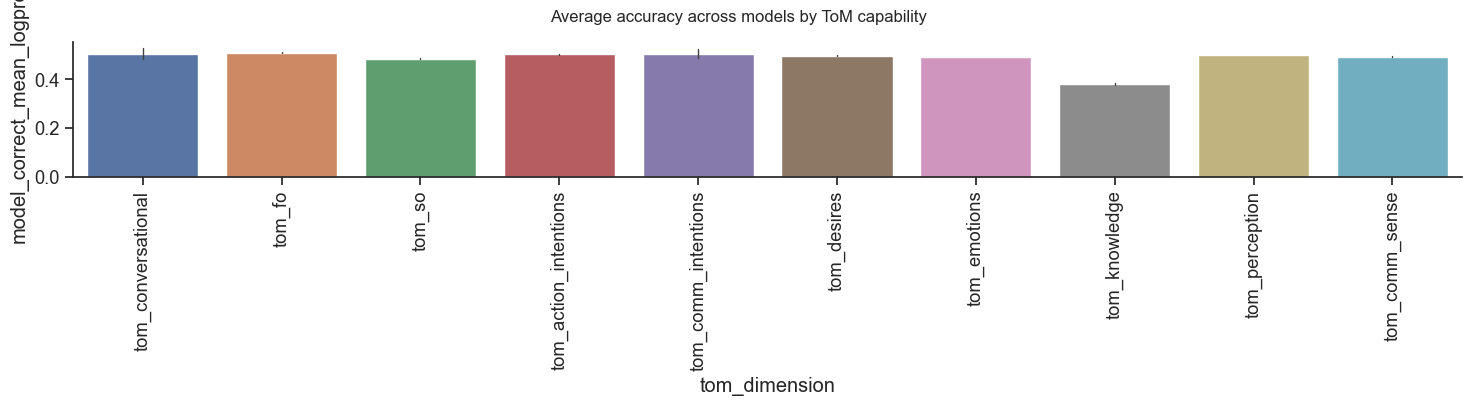

In [422]:
tom_features_acrossModels = sns.catplot(
    data= tom_datasets_withAnnotations_long_plot,
    x="tom_dimension",
    y=f"model_correct_mean_logprob",
    hue="tom_dimension",
    kind="bar",
    height=2.5,
    aspect=6,
    err_kws={"lw": 1}
)
# Rotate x ticks
tom_features_acrossModels.set_xticklabels(rotation=90)
# Add a descriptive title
tom_features_acrossModels.fig.suptitle("Average accuracy across models by ToM capability", fontsize=12)

# Adjust layout so the title doesn't overlap
plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

In [429]:
prag_datasets_withAnnotations = data_all_withAnnotations[data_all_withAnnotations["Domain"] == "pragmatics"][[col for col in data_all_withAnnotations.columns if col.startswith("prag_")] + ["model_correct_mean_logprob", "model", "dataset", "chance", "item_id"]]
prag_datasets_withAnnotations_long = pd.melt(
    prag_datasets_withAnnotations,
    id_vars=["model", "dataset", "model_correct_mean_logprob", "chance", "item_id"],
    value_vars=[col for col in prag_datasets_withAnnotations.columns if col.startswith("prag_")],
    var_name="prag_dimension",
    value_name="prag_dimension_value"
)
prag_datasets_withAnnotations_long_plot = prag_datasets_withAnnotations_long[prag_datasets_withAnnotations_long["prag_dimension_value"] == "yes"]

/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_69354/195907786.py:17: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


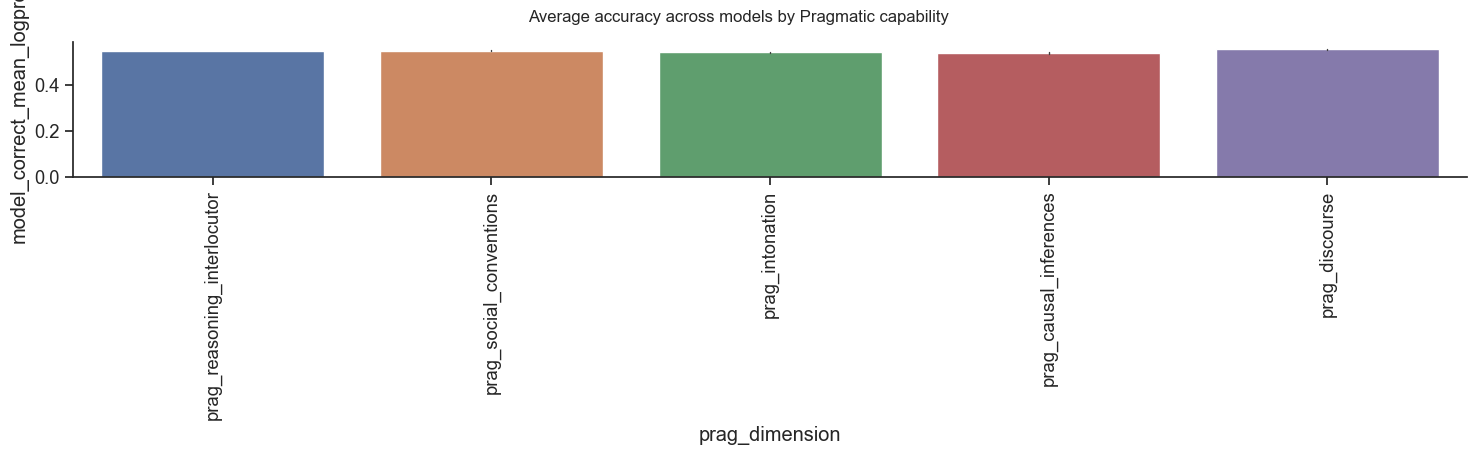

In [431]:
prag_features_acrossModels = sns.catplot(
    data= prag_datasets_withAnnotations_long_plot,
    x="prag_dimension",
    y=f"model_correct_mean_logprob",
    hue="prag_dimension",
    kind="bar",
    height=2.5,
    aspect=6,
    err_kws={"lw": 1}
)
# Rotate x ticks
prag_features_acrossModels.set_xticklabels(rotation=90)
# Add a descriptive title
prag_features_acrossModels.fig.suptitle("Average accuracy across models by Pragmatic capability", fontsize=12)

# Adjust layout so the title doesn't overlap
plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

### Stats for exploring dependency between the datasets

To Do:
* CCA
* EFA

In [432]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.cross_decomposition import CCA
from sklearn.preprocessing import StandardScaler


ModuleNotFoundError: No module named 'statsmodels'

Domain                         pragmatics       tom
model                                              
EleutherAI/pythia-1.4b-deduped   0.476512  0.429846
EleutherAI/pythia-12b-deduped    0.560348  0.466108
EleutherAI/pythia-1b-deduped     0.471918  0.450729
EleutherAI/pythia-2.8b-deduped   0.495963  0.444565
EleutherAI/pythia-6.9b-deduped   0.503659  0.476363


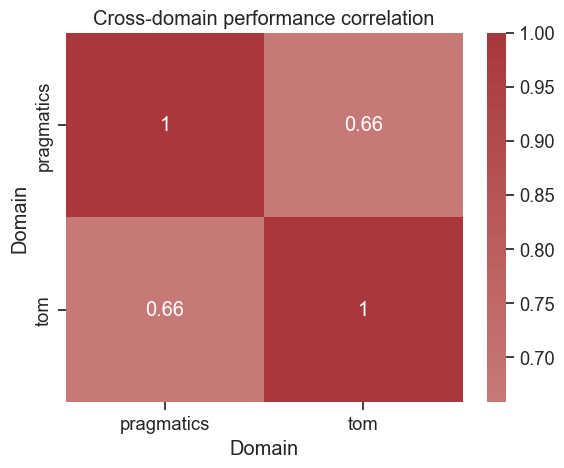

In [433]:
# TODO: code from GPT, not adjusted yet

agg = (
    data_all_withAnnotations.groupby(["model", "dataset", "Domain"])
    .agg(mean_acc=("model_correct_mean_logprob", "mean"))
    .reset_index()
)

domain_perf = (
    agg.groupby(["model", "Domain"])
    ["mean_acc"]
    .mean()
    .unstack("Domain")
)

# Example domains: ['tom', 'pragmatics']
print(domain_perf.head())


corr = domain_perf.corr()
sns.heatmap(corr, annot=True, cmap="vlag", center=0)
plt.title("Cross-domain performance correlation")
plt.show()


# model = smf.ols("pragmatics ~ tom", data=domain_perf).fit()
# print(model.summary())


In [ ]:
# TODO: code from GPT, not adjusted yet
from sklearn.decomposition import FactorAnalysis

X = feature_df[feature_cols].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

fa = FactorAnalysis(n_components=3, random_state=42)
factors = fa.fit_transform(X_scaled)

factor_df = pd.DataFrame(factors, columns=["Factor1", "Factor2", "Factor3"])
feature_df = pd.concat([feature_df, factor_df], axis=1)

factor_model = smf.mixedlm("model_correct_mean_logprob ~ Factor1 + Factor2 + Factor3 + Domain",
                           data=feature_df, groups=feature_df["model"]).fit()
print(factor_model.summary())


In [ ]:
tom = domain_perf.filter(like="tom")
prag = domain_perf.filter(like="prag")

X = StandardScaler().fit_transform(tom)
Y = StandardScaler().fit_transform(prag)

cca = CCA(n_components=1)
cca.fit(X, Y)
X_c, Y_c = cca.transform(X, Y)

print("Canonical correlation:", np.corrcoef(X_c.T, Y_c.T)[0, 1])


## Lesion analyses

In [381]:
MODELS_LESIONS = [
    "Mistral-7B-Instruct-v0.3",
    "Llama-2-13b-chat-hf",
    "gemma-1.1-7b-it",
    "Llama-3.1-8B-Instruct",
    "Llama-3.2-1B-Instruct",
]

def aggregate_over_lesioned_items(df, id_col="qid"):
    df_aggregated = df.groupby(["model_type", "model", id_col]).apply(
        lambda r: 
        pd.DataFrame({
            "model_lesion_correct_logprob": r["model_lesion_correct_logprob"].all(),
            # "correct_lesion_sum_logprob": r["model_correct_sum_logprob"].all()
        }, index=[0])                                                
    ).reset_index()[["model_type", "model", id_col, "model_lesion_correct_logprob"]]

    return df_aggregated

def read_lesion_data(data_dir="../lesion_test_output/", datasets=DATASETS_TOM):
    results = {}
    for dataset in datasets:
        # NOTE: this is a hotfix due to error in the data
        if dataset == "pub_indirectness_interpretation":
            print("Skipping pun indirectness interpretation")
            continue
        cur_dir = Path(data_dir, dataset)
        print(cur_dir)
        if not cur_dir.exists():
            # print(f"No data found ({cur_dir}); skipping...")
            continue
        dfs = []
        for f in listdir(Path(cur_dir)):
            if not any([m in f for m in list(MODELS_LESIONS)]):
                print(f"Uknown model in {f}")
                continue
            if "theory-of-mind" in f:
                model_type = "theory-of-mind"
            elif "none" in f:
                model_type = "none"
            else:
                model_type = "random" 
            d = pd.read_csv(Path(cur_dir, f))
            d["model_type"]= model_type
            d["model"] = [m for m in MODELS_LESIONS if m in f][0]
            # print("----- model type ", model_type)

            if ("correct_lesion_mean_logprob" in d.columns) and ("correct_lesion_logprob" in d.columns):
                d = d.rename({
                    "correct_lesion_logprob": "correct_lesion_logprob_raw",
                    "incorrect_lesion_logprob": "incorrect_lesion_logprob_raw",
                    "correct_lesion_mean_logprob": "correct_lesion_logprob",
                    "incorrect_lesion_mean_logprob": "incorrect_lesion_logprob"
                }, axis=1)
            elif ("context1_correct_lesion_mean_logprob" in d.columns) and ("context1_correct_lesion_logprob" in d.columns):
                d = d.rename({
                    "context1_correct_lesion_logprob": "context1_correct_lesion_logprob_raw",
                    "context2_incorrect_lesion_logprob": "context2_incorrect_lesion_logprob_raw",
                    "context1_correct_lesion_mean_logprob": "context1_correct_lesion_logprob",
                    "context2_incorrect_lesion_mean_logprob": "context2_incorrect_lesion_logprob"
                }, axis=1)
            elif ("Context1_correct_lesion_mean_logprob" in d.columns) and ("Context1_correct_lesion_logprob" in d.columns):
                d = d.rename({
                    "Context1_correct_lesion_logprob": "Context1_correct_lesion_logprob_raw",
                    "Context2_incorrect_lesion_logprob": "Context2_incorrect_lesion_logprob_raw",
                    "Context1_correct_lesion_mean_logprob": "Context1_correct_lesion_logprob",
                    "Context2_incorrect_lesion_mean_logprob": "Context2_incorrect_lesion_logprob"
                }, axis=1)
            elif ("fb_correct_lesion_mean_logprob" in d.columns) and ("fb_correct_lesion_logprob" in d.columns):
                d = d.rename({
                    "fb_correct_lesion_logprob": "fb_correct_lesion_logprob_raw",
                    "tb_incorrect_lesion_logprob": "tb_incorrect_lesion_logprob_raw",
                    "fb_correct_lesion_mean_logprob": "fb_correct_lesion_logprob",
                    "tb_incorrect_lesion_mean_logprob": "tb_incorrect_lesion_logprob"
                }, axis=1)

            dfs.append(d)
        df = pd.concat(dfs).reset_index()
        
        # handle datasets in long format, which need grouping by item ID
        # only correct prediction if all item-level pairwise predictions are correct (therefore, these tasks have a lower chance level performance)
        # these datasets are: opentom_attitude, pub_indirectness_interpretation, social_iqa, imppres_presupposition, imppres_implicature

        
        if (dataset == "opentom_attitude") or (dataset == "social_iqa") or (dataset.startswith("imppres")): 
            df[f"model_lesion_correct_logprob"] = (
                    (df[f"correct_lesion_logprob"] > df[f"incorrect_lesion_logprob"]) 
                )
            df = aggregate_over_lesioned_items(df, id_col="id")
            df["chance"] = 1/3 
        # elif (dataset == "pub_indirectness_interpretation"): 
        #     df = aggregate_over_items(df, id_col="pretext")
        #     df["chance"] = 0.25 (in the corrected version: 1/6?)
        
        elif (dataset == "emobench_understanding_emotion"):
            df[f"model_lesion_correct_logprob"] = (
                (df[f"correct_lesion_logprob"] > df[f"incorrect_lesion_logprob"]) 
            )
            df = aggregate_over_lesioned_items(df, id_col="qid")
            df["chance"] = 1/6 


        elif (dataset.startswith("emobench")):
            df[f"model_lesion_correct_logprob"] = (
                (df[f"correct_lesion_logprob"] > df[f"incorrect_lesion_logprob"]) 
            )
            df = aggregate_over_lesioned_items(df, id_col="qid")
            df["chance"] = 1/5

        # Process datasets with 2x2 scoring.
        elif dataset.startswith("ewok"):
            for metric in ["logprob"]:
                if f"context1_correct_lesion_{metric}" in df.columns:
                    df[f"model_lesion_correct_{metric}"] = (
                        (df[f"context1_correct_lesion_{metric}"] > df[f"context2_incorrect_lesion_{metric}"]) & \
                        (df[f"context2_correct_lesion_{metric}"] > df[f"context1_incorrect_lesion_{metric}"])
                    )
                # See Section 4.1 of the EWOK paper about scoring criterion
                else:
                    df[f"model_lesion_correct_{metric}"] = (
                        (df[f"Context1_correct_lesion_{metric}"] > df[f"Context2_incorrect_lesion_{metric}"]) & \
                        (df[f"Context2_correct_lesion_{metric}"] > df[f"Context1_incorrect_lesion_{metric}"])
                    )
            df["chance"] = 0.25
        elif dataset.startswith("tinytom") or dataset.startswith("bigtom") or dataset == "epitome_fb":
            for metric in ["logprob"]:
                df[f"model_lesion_correct_{metric}"] = (
                    (df[f"fb_correct_lesion_{metric}"] > df[f"tb_incorrect_lesion_{metric}"]) & \
                    (df[f"tb_correct_lesion_{metric}"] > df[f"fb_incorrect_lesion_{metric}"])
                )
            df["chance"] = 0.25
        
        else:
            print("----- using means ------")
            df[f"model_lesion_correct_logprob"] = (
                (df[f"correct_lesion_logprob"].astype(float) > df[f"incorrect_lesion_logprob"].astype(float)) 
            )
            df["chance"] = 0.5
        
        # print(f"{dataset}: {len(df.index)} rows")

        df["dataset"] = dataset
        df["item_id"] = list(range(len(df)))
        # print(df.columns)
        # df["model_type"] = model_type
        results[dataset] = df

    return results

# mistral_tom_lesioned = read_lesion_data(data_dir="../lesion_test_output/debug", datasets=["ewok_social-interactions", "social_iqa", "tinytom-v4_forward", "tom_localizer", "tomi_sapEtAl_first_order"])
# mistral_pragmatics_lesioned = read_lesion_data(data_dir="../lesion_test_output", datasets=DATASETS_PRAGMATICS)

In [197]:
##### baseline results on tom localizer dataset ######

tom_localizer_results = read_lesion_data(data_dir="../lesion_test_output/debug", datasets=["tom_localizer"])
tom_localizer_results["tom_localizer"]["model"].unique()
tom_localizer_results_pd = pd.concat([df[["item_id", "model_type", "model", "dataset", "chance", "model_lesion_correct_logprob"]] for df in tom_localizer_results.values()]).reset_index().dropna()
# mistral_pragmatics_lesioned_pd = pd.concat([df[["item_id", "model_type", "model", "dataset", "chance", "model_lesion_correct_logprob"]] for df in mistral_pragmatics_lesioned.values()]).reset_index().dropna()
# mistral_lesioned = pd.concat([mistral_tom_lesioned_pd, mistral_pragmatics_lesioned_pd]).reset_index()
tom_localizer_lesioned = tom_localizer_results_pd
tom_localizer_lesioned.groupby(["model", "model_type"]).aggregate({"model_lesion_correct_logprob": "mean"}).reset_index()

../lesion_test_output/debug/tom_localizer
Uknown model in .DS_Store
----- using means ------


,model,model_type,model_lesion_correct_logprob
0,Llama-2-13b-chat-hf,none,0.6
1,Llama-2-13b-chat-hf,theory-of-mind,0.6
2,Llama-3.1-8B-Instruct,none,0.3
3,Llama-3.1-8B-Instruct,theory-of-mind,0.4
4,Mistral-7B-Instruct-v0.3,none,0.6
5,Mistral-7B-Instruct-v0.3,theory-of-mind,0.4


In [225]:
#### comparing results of mistral specifically with and without the intructions that were used by Badr under 1% lesioning (ignore other models) ######
#### NOTE: here the target column wth avergae log Ps is "correct_lesion_mean_logprob", not "correct_lesion_logprob" ######
tomi_with_instruction = read_lesion_data(data_dir="../lesion_test_output/debug", datasets=["tomi_sapEtAl_first_order"])
tomi_with_instruction_pd = pd.concat([df[["item_id", "model_type", "model", "dataset", "chance", "model_lesion_correct_logprob", "correct_lesion_logprob_raw", "incorrect_lesion_logprob_raw", "falseTrueBelief"]] for df in tomi_with_instruction.values()]).reset_index().dropna()
# mistral_pragmatics_lesioned_pd = pd.concat([df[["item_id", "model_type", "model", "dataset", "chance", "model_lesion_correct_logprob"]] for df in mistral_pragmatics_lesioned.values()]).reset_index().dropna()
# mistral_lesioned = pd.concat([mistral_tom_lesioned_pd, mistral_pragmatics_lesioned_pd]).reset_index()
tomi_with_instruction_lesioned = tomi_with_instruction_pd
print("mistral ablated performance on tomi with instruction\n", tomi_with_instruction_lesioned.groupby(["model", "model_type", "falseTrueBelief"]).aggregate({"model_lesion_correct_logprob": "mean"}).reset_index())

# tomi_without_instruction = read_lesion_data(data_dir="../lesion_test_output", datasets=["tomi_sapEtAl_first_order"])
# tomi_without_instruction_pd = pd.concat([df[["item_id", "model_type", "model", "dataset", "chance", "model_lesion_correct_logprob"]] for df in tomi_without_instruction.values()]).reset_index().dropna()
# # mistral_pragmatics_lesioned_pd = pd.concat([df[["item_id", "model_type", "model", "dataset", "chance", "model_lesion_correct_logprob"]] for df in mistral_pragmatics_lesioned.values()]).reset_index().dropna()
# # mistral_lesioned = pd.concat([mistral_tom_lesioned_pd, mistral_pragmatics_lesioned_pd]).reset_index()
# tomi_without_instruction_lesioned = tomi_without_instruction_pd
# print("mistral ablated performance on tomi without instruction\n", tomi_without_instruction_lesioned.groupby(["model", "model_type"]).aggregate({"model_lesion_correct_logprob": "mean"}).reset_index())

# tomi_with_instruction_sum = read_lesion_data(data_dir="../lesion_test_output/debug_sum", datasets=["tomi_sapEtAl_first_order"])
# tomi_with_instruction_sum_pd = pd.concat([df[["item_id", "model_type", "model", "dataset", "chance", "model_lesion_correct_logprob"]] for df in tomi_with_instruction_sum.values()]).reset_index().dropna()
# # mistral_pragmatics_lesioned_pd = pd.concat([df[["item_id", "model_type", "model", "dataset", "chance", "model_lesion_correct_logprob"]] for df in mistral_pragmatics_lesioned.values()]).reset_index().dropna()
# # mistral_lesioned = pd.concat([mistral_tom_lesioned_pd, mistral_pragmatics_lesioned_pd]).reset_index()
# tomi_with_instruction_sum_lesioned = tomi_with_instruction_sum_pd
# print("mistral ablated performance on tomi with instruction under summing\n", tomi_with_instruction_sum_lesioned.groupby(["model", "model_type"]).aggregate({"model_lesion_correct_logprob": "mean"}).reset_index())

# tomi_with_instruction_10percent = read_lesion_data(data_dir="../lesion_test_output/debug_10", datasets=["tomi_sapEtAl_first_order"])
# tomi_with_instruction_10percent_pd = pd.concat([df[["item_id", "model_type", "model", "dataset", "chance", "model_lesion_correct_logprob"]] for df in tomi_with_instruction_10percent.values()]).reset_index().dropna()
# # mistral_pragmatics_lesioned_pd = pd.concat([df[["item_id", "model_type", "model", "dataset", "chance", "model_lesion_correct_logprob"]] for df in mistral_pragmatics_lesioned.values()]).reset_index().dropna()
# # mistral_lesioned = pd.concat([mistral_tom_lesioned_pd, mistral_pragmatics_lesioned_pd]).reset_index()
# tomi_with_instruction_10percent_lesioned = tomi_with_instruction_10percent_pd
# print("mistral ablated performance on tomi with instruction under 10% lesioning\n", tomi_with_instruction_10percent_lesioned.groupby(["model", "model_type"]).aggregate({"model_lesion_correct_logprob": "mean"}).reset_index())

../lesion_test_output/debug/tomi_sapEtAl_first_order
Uknown model in .DS_Store
----- using means ------
mistral ablated performance on tomi with instruction
                       model      model_type  falseTrueBelief  \
0       Llama-2-13b-chat-hf  theory-of-mind            False   
1       Llama-2-13b-chat-hf  theory-of-mind             True   
2     Llama-3.1-8B-Instruct  theory-of-mind            False   
3     Llama-3.1-8B-Instruct  theory-of-mind             True   
4  Mistral-7B-Instruct-v0.3  theory-of-mind            False   
5  Mistral-7B-Instruct-v0.3  theory-of-mind             True   

   model_lesion_correct_logprob  
0                      0.458874  
1                      0.637532  
2                      0.549784  
3                      0.760925  
4                      0.662338  
5                      0.668380  


In [228]:
tomi_with_instruction_pd
tomi_with_instruction_pd["correct_lesion_logprob_sum"] = tomi_with_instruction_pd["correct_lesion_logprob_raw"].apply(lambda r: np.sum([float(x) for x in r.split(";")]))
tomi_with_instruction_pd["incorrect_lesion_logprob_sum"] = tomi_with_instruction_pd["incorrect_lesion_logprob_raw"].apply(lambda r: np.sum([float(x) for x in r.split(";")]))
tomi_with_instruction_pd["model_lesion_correct_sum"] = (tomi_with_instruction_pd["correct_lesion_logprob_sum"] > tomi_with_instruction_pd["incorrect_lesion_logprob_sum"])
tomi_with_instruction_pd.groupby(["model", "model_type", "falseTrueBelief"]).aggregate({"model_lesion_correct_sum": "mean"}).reset_index()

,model,model_type,falseTrueBelief,model_lesion_correct_sum
0,Llama-2-13b-chat-hf,theory-of-mind,False,0.519481
1,Llama-2-13b-chat-hf,theory-of-mind,True,0.665810
2,Llama-3.1-8B-Instruct,theory-of-mind,False,0.554113
3,Llama-3.1-8B-Instruct,theory-of-mind,True,0.768638
4,Mistral-7B-Instruct-v0.3,theory-of-mind,False,0.649351
5,Mistral-7B-Instruct-v0.3,theory-of-mind,True,0.678663


In [236]:
debug_sum = read_lesion_data(data_dir="../lesion_test_output/debug_sum", datasets=["tomi_sapEtAl_first_order"])
debug_sum_pd = pd.concat([df[["item_id", "model_type", "model", "dataset", "chance", "model_lesion_correct_logprob", "correct_lesion_logprob_raw", "incorrect_lesion_logprob_raw", "falseTrueBelief"]] for df in debug_sum.values()]).reset_index().dropna()
# mistral_pragmatics_lesioned_pd = pd.concat([df[["item_id", "model_type", "model", "dataset", "chance", "model_lesion_correct_logprob"]] for df in mistral_pragmatics_lesioned.values()]).reset_index().dropna()
# mistral_lesioned = pd.concat([mistral_tom_lesioned_pd, mistral_pragmatics_lesioned_pd]).reset_index()
debug_sum_pd_lesioned = debug_sum_pd
print("model ablated performance on tomi with instruction under summing \n", debug_sum_pd_lesioned.groupby(["model", "model_type", "falseTrueBelief"]).aggregate({"model_lesion_correct_logprob": "mean"}).reset_index())


../lesion_test_output/debug_sum/tomi_sapEtAl_first_order
----- using means ------
model ablated performance on tomi with instruction under summing 
                        model model_type  falseTrueBelief  \
0        Llama-2-13b-chat-hf       none            False   
1        Llama-2-13b-chat-hf       none             True   
2        Llama-2-13b-chat-hf     random            False   
3        Llama-2-13b-chat-hf     random             True   
4      Llama-3.1-8B-Instruct       none            False   
5      Llama-3.1-8B-Instruct       none             True   
6      Llama-3.1-8B-Instruct     random            False   
7      Llama-3.1-8B-Instruct     random             True   
8   Mistral-7B-Instruct-v0.3       none            False   
9   Mistral-7B-Instruct-v0.3       none             True   
10  Mistral-7B-Instruct-v0.3     random            False   
11  Mistral-7B-Instruct-v0.3     random             True   

    model_lesion_correct_logprob  
0                       0.692641  


In [217]:
debug_sum["tomi_sapEtAl_first_order"]["model_type"].unique()

array(['none', 'theory-of-mind'], dtype=object)

In [237]:
debug_sum_pd["correct_lesion_logprob_mean"] = debug_sum_pd["correct_lesion_logprob_raw"].apply(lambda r: np.mean([float(x) for x in r.split(";")]))
debug_sum_pd["incorrect_lesion_logprob_mean"] = debug_sum_pd["incorrect_lesion_logprob_raw"].apply(lambda r: np.mean([float(x) for x in r.split(";")]))
debug_sum_pd["model_lesion_correct_mean"] = (debug_sum_pd["correct_lesion_logprob_mean"] > debug_sum_pd["incorrect_lesion_logprob_mean"])
debug_sum_pd.groupby(["model", "model_type", "falseTrueBelief"]).aggregate({"model_lesion_correct_mean": "mean"}).reset_index()

,model,model_type,falseTrueBelief,model_lesion_correct_mean
0,Llama-2-13b-chat-hf,none,False,0.558442
1,Llama-2-13b-chat-hf,none,True,0.588689
2,Llama-2-13b-chat-hf,random,False,0.513709
3,Llama-2-13b-chat-hf,random,True,0.591260
4,Llama-3.1-8B-Instruct,none,False,0.705628
5,Llama-3.1-8B-Instruct,none,True,0.760925
6,Llama-3.1-8B-Instruct,random,False,0.663781
7,Llama-3.1-8B-Instruct,random,True,0.701799
8,Mistral-7B-Instruct-v0.3,none,False,0.787879
9,Mistral-7B-Instruct-v0.3,none,True,0.609254


In [241]:
debug_with_space = read_lesion_data(data_dir="../lesion_test_output/debug_with_space", datasets=["tomi_sapEtAl_first_order"])
debug_with_space_pd = pd.concat([df[["item_id", "model_type", "model", "dataset", "chance", "model_lesion_correct_logprob", "correct_lesion_logprob_raw", "incorrect_lesion_logprob_raw", "falseTrueBelief"]] for df in debug_with_space.values()]).reset_index().dropna()
# mistral_pragmatics_lesioned_pd = pd.concat([df[["item_id", "model_type", "model", "dataset", "chance", "model_lesion_correct_logprob"]] for df in mistral_pragmatics_lesioned.values()]).reset_index().dropna()
# mistral_lesioned = pd.concat([mistral_tom_lesioned_pd, mistral_pragmatics_lesioned_pd]).reset_index()
debug_with_space_pd_lesioned = debug_with_space_pd
print("model ablated performance on tomi with instruction, with additional space like in behavioral eval, under summing \n")

debug_with_space_pd_lesioned.groupby(["model", "model_type", "falseTrueBelief"]).aggregate({"model_lesion_correct_logprob": "mean"}).reset_index()


../lesion_test_output/debug_with_space/tomi_sapEtAl_first_order
----- using means ------
model ablated performance on tomi with instruction, with additional space like in behavioral eval, under summing 



,model,model_type,falseTrueBelief,model_lesion_correct_logprob
0,Llama-2-13b-chat-hf,none,False,0.627706
1,Llama-2-13b-chat-hf,none,True,0.647815
2,Llama-2-13b-chat-hf,random,False,0.554113
3,Llama-2-13b-chat-hf,random,True,0.622108
4,Llama-2-13b-chat-hf,theory-of-mind,False,0.510823
5,Llama-2-13b-chat-hf,theory-of-mind,True,0.622108
6,Llama-3.1-8B-Instruct,none,False,0.683983
7,Llama-3.1-8B-Instruct,none,True,0.763496
8,Llama-3.1-8B-Instruct,random,False,0.653680
9,Llama-3.1-8B-Instruct,random,True,0.692374


In [248]:
debug_with_chat["tomi_sapEtAl_first_order"]

,index,story,question,correct,incorrect,cands,falseTrueBelief,correct_lesion_logprob,incorrect_lesion_logprob,correct_lesion_sum_logprob,incorrect_lesion_sum_logprob,correct_lesion_logprob_raw,incorrect_lesion_logprob_raw,scored_condition,model_type,model,model_lesion_correct_logprob,chance,dataset,item_id
0,0,Jack entered the laundry. Logan entered the st...,Where will Jack look for the persimmon?,bucket,pantry,"[""pantry"", ""bucket""]",True,-14.142444,-10.600071,-28.284888,-31.800212,-0.17085552215576172;-28.114032745361328,-3.328427314758301;-9.5367431640625e-06;-28.47...,tomi_sapEtAl_first_order,none,Mistral-7B-Instruct-v0.3,False,0.5,tomi_sapEtAl_first_order,0
1,1,Ella entered the dining room. Carter entered t...,Where will Ella look for the lemon?,drawer,pantry,"[""pantry"", ""drawer""]",False,-13.767157,-11.602334,-27.534313,-34.807002,-0.05811309814453125;-27.476200103759766,-6.390477180480957;-1.1444091796875e-05;-28.41...,tomi_sapEtAl_first_order,none,Mistral-7B-Instruct-v0.3,False,0.5,tomi_sapEtAl_first_order,1
2,2,Mason entered the bedroom. Isabella entered th...,Where will Mason look for the pineapple?,crate,bottle,"[""bottle"", ""crate""]",True,-14.179729,-19.928046,-28.359459,-39.856091,-0.023624420166015625;-28.335834503173828,-13.406794548034668;-26.449296951293945,tomi_sapEtAl_first_order,none,Mistral-7B-Instruct-v0.3,True,0.5,tomi_sapEtAl_first_order,2
3,3,Mason entered the sunroom. Ella entered the su...,Where will Mason look for the lemon?,bottle,bathtub,"[""bottle"", ""bathtub""]",True,-14.001513,-9.763176,-28.003027,-39.052703,-0.04636573791503906;-27.956661224365234,-12.16700267791748;-3.814697265625e-06;0.0;-26...,tomi_sapEtAl_first_order,none,Mistral-7B-Instruct-v0.3,False,0.5,tomi_sapEtAl_first_order,3
4,4,Alexander entered the garden. James entered th...,Where will Avery look for the boots?,container,basket,"[""container"", ""basket""]",True,-13.888704,-17.789483,-27.777409,-35.578966,-0.059040069580078125;-27.718368530273438,-8.934514999389648;-26.644451141357422,tomi_sapEtAl_first_order,none,Mistral-7B-Instruct-v0.3,True,0.5,tomi_sapEtAl_first_order,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7435,615,Oliver entered the laundry. Aiden dislikes the...,Where will Oliver look for the peach?,suitcase,drawer,"[""drawer"", ""suitcase""]",True,-5.527889,-5.095220,-33.167336,-30.571318,-12.897649765014648;-1.52587890625e-05;-11.761...,-9.830162048339844;-1.9073486328125e-06;-11.09...,tomi_sapEtAl_first_order,none,Llama-2-13b-chat-hf,False,0.5,tomi_sapEtAl_first_order,7435
7436,616,James dislikes the t-shirt. Aria entered the b...,Where will Hannah look for the pumpkin?,box,bathtub,"[""bathtub"", ""box""]",False,-5.917248,-3.435550,-29.586238,-24.048852,-9.674026489257812;-11.5444917678833;-2.683236...,-6.148447036743164;-4.9591064453125e-05;-5.149...,tomi_sapEtAl_first_order,none,Llama-2-13b-chat-hf,False,0.5,tomi_sapEtAl_first_order,7436
7437,617,Chloe entered the back yard. Amelia entered th...,Where will Chloe look for the underclothes?,suitcase,pantry,"[""suitcase"", ""pantry""]",False,-4.592705,-4.999287,-27.556230,-29.995724,-8.11957836151123;-1.1444091796875e-05;-11.211...,-12.458762168884277;-5.340576171875e-05;-11.39...,tomi_sapEtAl_first_order,none,Llama-2-13b-chat-hf,True,0.5,tomi_sapEtAl_first_order,7437
7438,618,Jackson entered the cellar. Noah entered the c...,Where will Jackson look for the onion?,envelope,bathtub,"[""bathtub"", ""envelope""]",False,-5.882481,-3.581756,-35.294884,-25.072291,-13.223013877868652;-3.814697265625e-06;-11.54...,-6.6497955322265625;-5.340576171875e-05;-1.716...,tomi_sapEtAl_first_order,none,Llama-2-13b-chat-hf,False,0.5,tomi_sapEtAl_first_order,7438


In [ ]:
debug_with_chat = read_lesion_data(data_dir="../lesion_test_output/wSpace_wChat", datasets=["tomi_sapEtAl_first_order"])
debug_with_chat_pd = pd.concat([df[["item_id", "model_type", "model", "dataset", "chance", "model_lesion_correct_logprob", "correct_lesion_logprob_raw", "incorrect_lesion_logprob_raw", "falseTrueBelief"]] for df in debug_with_chat.values()]).reset_index().dropna()
# mistral_pragmatics_lesioned_pd = pd.concat([df[["item_id", "model_type", "model", "dataset", "chance", "model_lesion_correct_logprob"]] for df in mistral_pragmatics_lesioned.values()]).reset_index().dropna()
# mistral_lesioned = pd.concat([mistral_tom_lesioned_pd, mistral_pragmatics_lesioned_pd]).reset_index()
debug_with_chat_pd_lesioned = debug_with_chat_pd
print("model on tomi with instruction, with additional space like in behavioral eval, with chat template formatting like in behavioral eval \n")

debug_with_chat_pd_lesioned.groupby(["model", "model_type", "falseTrueBelief"]).aggregate({"model_lesion_correct_logprob": "mean"}).reset_index()


../lesion_test_output/wSpace_wChat/tomi_sapEtAl_first_order
----- using means ------
model on tomi with instruction, with additional space like in behavioral eval, with chat template formatting like in behavioral eval 



,model,model_type,falseTrueBelief,model_lesion_correct_logprob
0,Llama-2-13b-chat-hf,none,False,0.445887
1,Llama-2-13b-chat-hf,none,True,0.652956
2,Llama-2-13b-chat-hf,random,False,0.468975
3,Llama-2-13b-chat-hf,random,True,0.606684
4,Llama-3.1-8B-Instruct,none,False,0.558442
5,Llama-3.1-8B-Instruct,none,True,0.778920
6,Llama-3.1-8B-Instruct,random,False,0.603175
7,Llama-3.1-8B-Instruct,random,True,0.645244
8,Mistral-7B-Instruct-v0.3,none,False,0.601732
9,Mistral-7B-Instruct-v0.3,none,True,0.629820


In [250]:
debug_with_chatLoc_chatEval = read_lesion_data(data_dir="../lesion_test_output/wChatLoc", datasets=["tomi_sapEtAl_first_order"])
debug_with_chatLoc_chatEval_pd = pd.concat([df[["item_id", "model_type", "model", "dataset", "chance", "model_lesion_correct_logprob", "correct_lesion_sum_logprob", "incorrect_lesion_sum_logprob", "correct_lesion_logprob_raw", "incorrect_lesion_logprob_raw", "falseTrueBelief"]] for df in debug_with_chatLoc_chatEval.values()]).reset_index().dropna()
# mistral_pragmatics_lesioned_pd = pd.concat([df[["item_id", "model_type", "model", "dataset", "chance", "model_lesion_correct_logprob"]] for df in mistral_pragmatics_lesioned.values()]).reset_index().dropna()
# mistral_lesioned = pd.concat([mistral_tom_lesioned_pd, mistral_pragmatics_lesioned_pd]).reset_index()
debug_with_chatLoc_chatEval_pd_lesioned = debug_with_chatLoc_chatEval_pd
print("given chat-formatted localization, model on tomi with instruction, with additional space like in behavioral eval, with chat template formatting like in behavioral eval \n")

debug_with_chatLoc_chatEval_pd_lesioned.groupby(["model", "model_type", "falseTrueBelief"]).aggregate({"model_lesion_correct_logprob": "mean"}).reset_index()


../lesion_test_output/wChatLoc/tomi_sapEtAl_first_order
----- using means ------
given chat-formatted localization, model on tomi with instruction, with additional space like in behavioral eval, with chat template formatting like in behavioral eval 



,model,model_type,falseTrueBelief,model_lesion_correct_logprob
0,Llama-2-13b-chat-hf,none,False,0.445887
1,Llama-2-13b-chat-hf,none,True,0.652956
2,Llama-2-13b-chat-hf,random,False,0.468975
3,Llama-2-13b-chat-hf,random,True,0.606684
4,Llama-2-13b-chat-hf,theory-of-mind,False,0.463203
5,Llama-2-13b-chat-hf,theory-of-mind,True,0.580977
6,Llama-3.1-8B-Instruct,none,False,0.558442
7,Llama-3.1-8B-Instruct,none,True,0.778920
8,Llama-3.1-8B-Instruct,random,False,0.603175
9,Llama-3.1-8B-Instruct,random,True,0.645244


In [251]:
debug_with_chatLoc_chatEval_pd["model_lesion_correct_sum"] = (debug_with_chatLoc_chatEval_pd["correct_lesion_sum_logprob"] > debug_with_chatLoc_chatEval_pd["incorrect_lesion_sum_logprob"])
debug_with_chatLoc_chatEval_pd_lesioned.groupby(["model", "model_type", "falseTrueBelief"]).aggregate({"model_lesion_correct_sum": "mean"}).reset_index()


,model,model_type,falseTrueBelief,model_lesion_correct_sum
0,Llama-2-13b-chat-hf,none,False,0.545455
1,Llama-2-13b-chat-hf,none,True,0.681234
2,Llama-2-13b-chat-hf,random,False,0.531025
3,Llama-2-13b-chat-hf,random,True,0.643530
4,Llama-2-13b-chat-hf,theory-of-mind,False,0.519481
5,Llama-2-13b-chat-hf,theory-of-mind,True,0.624679
6,Llama-3.1-8B-Instruct,none,False,0.558442
7,Llama-3.1-8B-Instruct,none,True,0.763496
8,Llama-3.1-8B-Instruct,random,False,0.630592
9,Llama-3.1-8B-Instruct,random,True,0.646958


In [253]:
new_logP = read_lesion_data(data_dir="../lesion_test_output/wChatLoc_newLogP", datasets=["tomi_sapEtAl_first_order"])
new_logP_pd = pd.concat([df[["item_id", "model_type", "model", "dataset", "chance", "model_lesion_correct_logprob", "correct_lesion_sum_logprob", "incorrect_lesion_sum_logprob", "correct_lesion_logprob_raw", "incorrect_lesion_logprob_raw", "falseTrueBelief"]] for df in new_logP.values()]).reset_index().dropna()
# mistral_pragmatics_lesioned_pd = pd.concat([df[["item_id", "model_type", "model", "dataset", "chance", "model_lesion_correct_logprob"]] for df in mistral_pragmatics_lesioned.values()]).reset_index().dropna()
# mistral_lesioned = pd.concat([mistral_tom_lesioned_pd, mistral_pragmatics_lesioned_pd]).reset_index()
new_logP_pd_lesioned = new_logP_pd
print("given chat-formatted localization, model on tomi with instruction, with additional space like in behavioral eval, with chat template formatting like in behavioral eval, with NEW MASKING LOG PROBABILITIES \n")

new_logP_pd_lesioned.groupby(["model", "model_type", "falseTrueBelief"]).aggregate({"model_lesion_correct_logprob": "mean"}).reset_index()


../lesion_test_output/wChatLoc_newLogP/tomi_sapEtAl_first_order
Uknown model in .ipynb_checkpoints
----- using means ------
given chat-formatted localization, model on tomi with instruction, with additional space like in behavioral eval, with chat template formatting like in behavioral eval, with NEW MASKING LOG PROBABILITIES 



,model,model_type,falseTrueBelief,model_lesion_correct_logprob
0,Llama-2-13b-chat-hf,theory-of-mind,False,0.515152
1,Llama-2-13b-chat-hf,theory-of-mind,True,0.447301
2,Llama-3.1-8B-Instruct,none,False,0.506494
3,Llama-3.1-8B-Instruct,none,True,0.758355
4,Llama-3.1-8B-Instruct,theory-of-mind,False,0.471861
5,Llama-3.1-8B-Instruct,theory-of-mind,True,0.485861


In [256]:
new_logP_minusMask = read_lesion_data(data_dir="../lesion_test_output/wChatLoc_newLogP_minusMask", datasets=["tomi_sapEtAl_first_order"])
new_logP_minusMask_pd = pd.concat([df[["item_id", "model_type", "model", "dataset", "chance", "model_lesion_correct_logprob", "correct_lesion_sum_logprob", "incorrect_lesion_sum_logprob", "correct_lesion_logprob_raw", "incorrect_lesion_logprob_raw", "falseTrueBelief"]] for df in new_logP_minusMask.values()]).reset_index().dropna()
# mistral_pragmatics_lesioned_pd = pd.concat([df[["item_id", "model_type", "model", "dataset", "chance", "model_lesion_correct_logprob"]] for df in mistral_pragmatics_lesioned.values()]).reset_index().dropna()
# mistral_lesioned = pd.concat([mistral_tom_lesioned_pd, mistral_pragmatics_lesioned_pd]).reset_index()
new_logP_minusMask_pd_lesioned = new_logP_minusMask_pd
print("given chat-formatted localization, model on tomi with instruction, with additional space like in behavioral eval, with chat template formatting like in behavioral eval, with NEW MASKING LOG PROBABILITIES, with fixed masking \n")

new_logP_minusMask_pd_lesioned.groupby(["model", "model_type", "falseTrueBelief"]).aggregate({"model_lesion_correct_logprob": "mean"}).reset_index()



../lesion_test_output/wChatLoc_newLogP_minusMask/tomi_sapEtAl_first_order
Uknown model in .ipynb_checkpoints
----- using means ------
given chat-formatted localization, model on tomi with instruction, with additional space like in behavioral eval, with chat template formatting like in behavioral eval, with NEW MASKING LOG PROBABILITIES, with fixed masking 



,model,model_type,falseTrueBelief,model_lesion_correct_logprob
0,Llama-3.1-8B-Instruct,none,False,0.506494
1,Llama-3.1-8B-Instruct,none,True,0.758355
2,Llama-3.1-8B-Instruct,theory-of-mind,False,0.645022
3,Llama-3.1-8B-Instruct,theory-of-mind,True,0.660668


In [255]:
new_logP_minusMask_fullP = read_lesion_data(data_dir="../lesion_test_output/wChatLoc_newLogP_minusMask_fullPrec", datasets=["tomi_sapEtAl_first_order"])
new_logP_minusMask_fullP_pd = pd.concat([df[["item_id", "model_type", "model", "dataset", "chance", "model_lesion_correct_logprob", "correct_lesion_sum_logprob", "incorrect_lesion_sum_logprob", "correct_lesion_logprob_raw", "incorrect_lesion_logprob_raw", "falseTrueBelief"]] for df in new_logP_minusMask_fullP.values()]).reset_index().dropna()
# mistral_pragmatics_lesioned_pd = pd.concat([df[["item_id", "model_type", "model", "dataset", "chance", "model_lesion_correct_logprob"]] for df in mistral_pragmatics_lesioned.values()]).reset_index().dropna()
# mistral_lesioned = pd.concat([mistral_tom_lesioned_pd, mistral_pragmatics_lesioned_pd]).reset_index()
new_logP_minusMask_fullP_pd_lesioned = new_logP_minusMask_fullP_pd
print("given chat-formatted localization, model on tomi with instruction, with additional space like in behavioral eval, with chat template formatting like in behavioral eval, with NEW MASKING LOG PROBABILITIES, with fixed masking, full precision \n")

new_logP_minusMask_fullP_pd_lesioned.groupby(["model", "model_type", "falseTrueBelief"]).aggregate({"model_lesion_correct_logprob": "mean"}).reset_index()

../lesion_test_output/wChatLoc_newLogP_minusMask_fullPrec/tomi_sapEtAl_first_order
Uknown model in .ipynb_checkpoints
----- using means ------
given chat-formatted localization, model on tomi with instruction, with additional space like in behavioral eval, with chat template formatting like in behavioral eval, with NEW MASKING LOG PROBABILITIES, with fixed masking, full precision 



,model,model_type,falseTrueBelief,model_lesion_correct_logprob
0,Llama-3.1-8B-Instruct,theory-of-mind,False,0.645022
1,Llama-3.1-8B-Instruct,theory-of-mind,True,0.668380


In [382]:
new_logP_amirDebug = read_lesion_data(data_dir="../../amir_logP_debug", datasets=["tomi_sapEtAl_first_order_legacy"])
new_logP_amirDebug_pd = pd.concat([df[["item_id", "model_type", "model", "dataset", "chance", "model_lesion_correct_logprob", "correct_lesion_sum_logprob", "incorrect_lesion_sum_logprob", "correct_lesion_logprob_raw", "incorrect_lesion_logprob_raw", "falseTrueBelief"]] for df in new_logP_amirDebug.values()]).reset_index().dropna()
# mistral_pragmatics_lesioned_pd = pd.concat([df[["item_id", "model_type", "model", "dataset", "chance", "model_lesion_correct_logprob"]] for df in mistral_pragmatics_lesioned.values()]).reset_index().dropna()
# mistral_lesioned = pd.concat([mistral_tom_lesioned_pd, mistral_pragmatics_lesioned_pd]).reset_index()
new_logP_amirDebug_pd_lesioned = new_logP_amirDebug_pd
print("given chat-formatted localization, model on tomi with instruction, with additional space like in behavioral eval,  Amir's comparison of legacy implementation and new implementation \n")

new_logP_amirDebug_pd_lesioned.groupby(["model", "model_type", "falseTrueBelief"]).aggregate({"model_lesion_correct_logprob": "mean"}).reset_index()

../../amir_logP_debug/tomi_sapEtAl_first_order_legacy
----- using means ------
given chat-formatted localization, model on tomi with instruction, with additional space like in behavioral eval,  Amir's comparison of legacy implementation and new implementation 



,model,model_type,falseTrueBelief,model_lesion_correct_logprob
0,Llama-3.2-1B-Instruct,theory-of-mind,False,0.476190
1,Llama-3.2-1B-Instruct,theory-of-mind,True,0.534704


In [383]:
new_logP_amirDebug = read_lesion_data(data_dir="../../amir_logP_debug", datasets=["tomi_sapEtAl_first_order_new"])
new_logP_amirDebug_pd = pd.concat([df[["item_id", "model_type", "model", "dataset", "chance", "model_lesion_correct_logprob", "correct_lesion_sum_logprob", "incorrect_lesion_sum_logprob", "correct_lesion_logprob_raw", "incorrect_lesion_logprob_raw", "falseTrueBelief"]] for df in new_logP_amirDebug.values()]).reset_index().dropna()
# mistral_pragmatics_lesioned_pd = pd.concat([df[["item_id", "model_type", "model", "dataset", "chance", "model_lesion_correct_logprob"]] for df in mistral_pragmatics_lesioned.values()]).reset_index().dropna()
# mistral_lesioned = pd.concat([mistral_tom_lesioned_pd, mistral_pragmatics_lesioned_pd]).reset_index()
new_logP_amirDebug_pd_lesioned = new_logP_amirDebug_pd
print("given chat-formatted localization, model on tomi with instruction, with additional space like in behavioral eval,  Amir's comparison of legacy implementation and new implementation \n")

new_logP_amirDebug_pd_lesioned.groupby(["model", "model_type", "falseTrueBelief"]).aggregate({"model_lesion_correct_logprob": "mean"}).reset_index()

../../amir_logP_debug/tomi_sapEtAl_first_order_new
----- using means ------
given chat-formatted localization, model on tomi with instruction, with additional space like in behavioral eval,  Amir's comparison of legacy implementation and new implementation 



,model,model_type,falseTrueBelief,model_lesion_correct_logprob
0,Llama-3.2-1B-Instruct,theory-of-mind,False,0.480519
1,Llama-3.2-1B-Instruct,theory-of-mind,True,0.529563


In [154]:
# evaluate results if only first token of completion is used to calculate accuracy under lesion
tomi_with_instruction_firstToken = tomi_with_instruction["tomi_sapEtAl_first_order"]
tomi_with_instruction_firstToken = tomi_with_instruction_firstToken[(tomi_with_instruction_firstToken["model"] == "Mistral-7B-Instruct-v0.3") & (tomi_with_instruction_firstToken["model_type"] == "theory-of-mind")]
tomi_with_instruction_firstToken["correct_lesion_logprob_firstToken"] = tomi_with_instruction_firstToken["correct_lesion_logprob"].str.split(";").str[0].astype(float)
tomi_with_instruction_firstToken["incorrect_lesion_logprob_firstToken"] = tomi_with_instruction_firstToken["incorrect_lesion_logprob"].str.split(";").str[0].astype(float)
tomi_with_instruction_firstToken["model_lesion_correct_firstToken"] = (
    (tomi_with_instruction_firstToken["correct_lesion_logprob_firstToken"] > tomi_with_instruction_firstToken["incorrect_lesion_logprob_firstToken"])
)
tomi_with_instruction_firstToken

/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_44203/664655662.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tomi_with_instruction_firstToken["correct_lesion_logprob_firstToken"] = tomi_with_instruction_firstToken["correct_lesion_logprob"].str.split(";").str[0].astype(float)
/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_44203/664655662.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tomi_with_instruction_firstToken["incorrect_lesion_logprob_firstToken"] = tomi_with_instruc

,index,story,question,correct,incorrect,cands,correct_lesion_logprob,incorrect_lesion_logprob,scored_condition,model_type,...,falseTrueBelief,correct_lesion_mean_logprob,incorrect_lesion_mean_logprob,model_lesion_correct_logprob,chance,dataset,item_id,correct_lesion_logprob_firstToken,incorrect_lesion_logprob_firstToken,model_lesion_correct_firstToken
1240,0,Jack entered the laundry. Logan entered the st...,Where will Jack look for the persimmon?,bucket,pantry,"[""pantry"", ""bucket""]",-2.865985870361328,-1.4349422454833984;-1.71661376953125e-05,tomi_sapEtAl_first_order,theory-of-mind,...,True,-2.865986,-0.717480,True,0.5,tomi_sapEtAl_first_order,1240,-2.865986,-1.434942,False
1241,1,Ella entered the dining room. Carter entered t...,Where will Ella look for the lemon?,drawer,pantry,"[""pantry"", ""drawer""]",-2.2796993255615234,-2.676952362060547;-5.53131103515625e-05,tomi_sapEtAl_first_order,theory-of-mind,...,False,-2.279699,-1.338504,False,0.5,tomi_sapEtAl_first_order,1241,-2.279699,-2.676952,True
1242,2,Mason entered the bedroom. Isabella entered th...,Where will Mason look for the pineapple?,crate,bottle,"[""bottle"", ""crate""]",-0.4164581298828125,-7.409970283508301,tomi_sapEtAl_first_order,theory-of-mind,...,True,-0.416458,-7.409970,False,0.5,tomi_sapEtAl_first_order,1242,-0.416458,-7.409970,True
1243,3,Mason entered the sunroom. Ella entered the su...,Where will Mason look for the lemon?,bottle,bathtub,"[""bottle"", ""bathtub""]",-0.5823774337768555,-7.119098663330078;-0.000339508056640625;-1.90...,tomi_sapEtAl_first_order,theory-of-mind,...,True,-0.582377,-2.373147,False,0.5,tomi_sapEtAl_first_order,1243,-0.582377,-7.119099,True
1244,4,Alexander entered the garden. James entered th...,Where will Avery look for the boots?,container,basket,"[""container"", ""basket""]",-1.5793018341064453,-5.163193702697754,tomi_sapEtAl_first_order,theory-of-mind,...,True,-1.579302,-5.163194,False,0.5,tomi_sapEtAl_first_order,1244,-1.579302,-5.163194,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1855,615,Oliver entered the laundry. Aiden dislikes the...,Where will Oliver look for the peach?,suitcase,drawer,"[""drawer"", ""suitcase""]",-1.6678028106689453;-9.5367431640625e-06,-7.260869026184082,tomi_sapEtAl_first_order,theory-of-mind,...,True,-0.833906,-7.260869,False,0.5,tomi_sapEtAl_first_order,1855,-1.667803,-7.260869,True
1856,616,James dislikes the t-shirt. Aria entered the b...,Where will Hannah look for the pumpkin?,box,bathtub,"[""bathtub"", ""box""]",-1.5910329818725586,-5.700257301330566;-0.0003108978271484375;-1.1...,tomi_sapEtAl_first_order,theory-of-mind,...,False,-1.591033,-1.900193,False,0.5,tomi_sapEtAl_first_order,1856,-1.591033,-5.700257,True
1857,617,Chloe entered the back yard. Amelia entered th...,Where will Chloe look for the underclothes?,suitcase,pantry,"[""suitcase"", ""pantry""]",-1.025923728942871;-2.6702880859375e-05,-12.426419258117676;-5.7220458984375e-05,tomi_sapEtAl_first_order,theory-of-mind,...,False,-0.512975,-6.213238,False,0.5,tomi_sapEtAl_first_order,1857,-1.025924,-12.426419,True
1858,618,Jackson entered the cellar. Noah entered the c...,Where will Jackson look for the onion?,envelope,bathtub,"[""bathtub"", ""envelope""]",-9.150383949279785,-4.560821533203125;-0.0001354217529296875;-9.5...,tomi_sapEtAl_first_order,theory-of-mind,...,False,-9.150384,-1.520322,True,0.5,tomi_sapEtAl_first_order,1858,-9.150384,-4.560822,False


In [155]:
tomi_with_instruction_firstToken["model_lesion_correct_firstToken"].mean()

0.667741935483871

In [179]:
mistral_tom_lesioned_pd = pd.concat([df[["item_id", "model_type", "model", "dataset", "chance", "model_lesion_correct_logprob"]] for df in mistral_tom_lesioned.values()]).reset_index().dropna()
# mistral_pragmatics_lesioned_pd = pd.concat([df[["item_id", "model_type", "model", "dataset", "chance", "model_lesion_correct_logprob"]] for df in mistral_pragmatics_lesioned.values()]).reset_index().dropna()
# mistral_lesioned = pd.concat([mistral_tom_lesioned_pd, mistral_pragmatics_lesioned_pd]).reset_index()
mistral_lesioned = mistral_tom_lesioned_pd

In [180]:
mistral_lesioned["dataset"].unique()

array(['ewok_social-interactions', 'social_iqa', 'tinytom-v4_forward',
       'tom_localizer', 'tomi_sapEtAl_first_order'], dtype=object)

In [181]:
mistral_lesioned.groupby([ "dataset", "model", "model_type"]).aggregate({"model_lesion_correct_logprob": "mean"}).reset_index()

,dataset,model,model_type,model_lesion_correct_logprob
0,ewok_social-interactions,Llama-2-13b-chat-hf,theory-of-mind,0.462857
1,ewok_social-interactions,Llama-3.1-8B-Instruct,theory-of-mind,0.508571
2,ewok_social-interactions,Mistral-7B-Instruct-v0.3,theory-of-mind,0.445714
3,social_iqa,Llama-2-13b-chat-hf,theory-of-mind,0.326677
4,social_iqa,Llama-3.1-8B-Instruct,theory-of-mind,0.494112
5,social_iqa,Mistral-7B-Instruct-v0.3,theory-of-mind,0.470046
6,tinytom-v4_forward,Llama-2-13b-chat-hf,theory-of-mind,0.750000
7,tinytom-v4_forward,Llama-3.1-8B-Instruct,theory-of-mind,0.450000
8,tinytom-v4_forward,Mistral-7B-Instruct-v0.3,theory-of-mind,0.550000
9,tom_localizer,Llama-2-13b-chat-hf,none,0.600000


In [211]:
falseTrueCondition = pd.read_csv("../behavioral_eval_stimuli/log_p_curated/tomi_sapEtAl_first_order.csv")['falseTrueBelief'].tolist()


In [233]:
# quick manual comparison
mistral_debug_results_woSpace = pd.read_csv("../behavioral_eval_output/original/tomi_sapEtAl_first_order/Mistral-7B-Instruct-v0.3.csv")
mistral_debug_results_woSpace["falseTrueBelief"] = falseTrueCondition
# print("mistral", mistral_debug_results_woSpace.groupby("falseTrueBelief")["model_correct_sum_logprob"].mean())
print("mistral with task instructions\n", mistral_debug_results_woSpace.groupby("falseTrueBelief")["model_correct_mean_logprob"].mean(), mistral_debug_results_woSpace.groupby("falseTrueBelief")["model_correct_sum_logprob"].mean())
# quick manual comparison
# mistral_debug_results_noInstructions = pd.read_csv("../behavioral_eval_output/no_space_baseline/tomi_sapEtAl_first_order/Mistral-7B-Instruct-v0.3.csv")
# mistral_debug_results_noInstructions["falseTrueBelief"] = falseTrueCondition
# # print("mistral", mistral_debug_results_woSpace.groupby("falseTrueBelief")["model_correct_sum_logprob"].mean())
# print("mistral without task instructions", mistral_debug_results_noInstructions["model_correct_mean_logprob"].mean(), mistral_debug_results_noInstructions.groupby("falseTrueBelief")["model_correct_sum_logprob"].mean())

llama_13b_chat_debug_results_woSpace = pd.read_csv("../behavioral_eval_output/original/tomi_sapEtAl_first_order/Llama-2-13b-chat-hf.csv")
llama_13b_chat_debug_results_woSpace["falseTrueBelief"] = falseTrueCondition
print("llama 13b chat\n", llama_13b_chat_debug_results_woSpace.groupby("falseTrueBelief")["model_correct_mean_logprob"].mean(), llama_13b_chat_debug_results_woSpace.groupby("falseTrueBelief")["model_correct_sum_logprob"].mean())

# llama_13b_debug_results_woSpace = pd.read_csv("../behavioral_eval_output/original/tomi_sapEtAl_first_order/Llama-2-13b-hf.csv")
# llama_13b_debug_results_woSpace["falseTrueBelief"] = falseTrueCondition
# print("llama 13b", llama_13b_debug_results_woSpace.groupby("falseTrueBelief")["model_correct_mean_logprob"].mean(), llama_13b_debug_results_woSpace.groupby("falseTrueBelief")["model_correct_sum_logprob"].mean())

llama_8b_instruct_debug_results_woSpace = pd.read_csv("../behavioral_eval_output/original/tomi_sapEtAl_first_order/Llama-3.1-8B-Instruct.csv")
llama_8b_instruct_debug_results_woSpace["falseTrueBelief"] = falseTrueCondition
print("llama 8b instruct\n", llama_8b_instruct_debug_results_woSpace.groupby("falseTrueBelief")["model_correct_mean_logprob"].mean(), llama_8b_instruct_debug_results_woSpace.groupby("falseTrueBelief")["model_correct_sum_logprob"].mean())

# llama_3b_debug_results_woSpace = pd.read_csv("../behavioral_eval_output/original/tomi_sapEtAl_first_order/Llama-3.2-3B.csv")
# llama_3b_debug_results_woSpace["falseTrueBelief"] = falseTrueCondition
# print("llama 3b", llama_3b_debug_results_woSpace["model_correct_mean_logprob"].mean(), llama_3b_debug_results_woSpace.groupby("falseTrueBelief")["model_correct_sum_logprob"].mean())

# llama_8b_debug_results_tom_localizer = pd.read_csv("../behavioral_eval_output/original/tom_localizer/Llama-3.1-8B-Instruct.csv")
# print("llama 8 b tom localizer", llama_8b_debug_results_tom_localizer["model_correct_sum_logprob"].mean())

# mistral_debug_results_tom_localizer = pd.read_csv("../behavioral_eval_output/original/tom_localizer/Mistral-7B-Instruct-v0.3.csv")
# print("mistral 7 b tom localizer", mistral_debug_results_tom_localizer["model_correct_sum_logprob"].mean())

# llama_13b_debug_results_tom_localizer = pd.read_csv("../behavioral_eval_output/original/tom_localizer/Llama-2-13b-chat-hf.csv")
# print("llama 13 b tom localizer", llama_13b_debug_results_tom_localizer["model_correct_sum_logprob"].mean())

mistral with task instructions
 falseTrueBelief
False    0.562771
True     0.573265
Name: model_correct_mean_logprob, dtype: float64 falseTrueBelief
False    0.701299
True     0.673522
Name: model_correct_sum_logprob, dtype: float64
llama 13b chat
 falseTrueBelief
False    0.458874
True     0.496144
Name: model_correct_mean_logprob, dtype: float64 falseTrueBelief
False    0.56710
True     0.55527
Name: model_correct_sum_logprob, dtype: float64
llama 8b instruct
 falseTrueBelief
False    0.437229
True     0.845758
Name: model_correct_mean_logprob, dtype: float64 falseTrueBelief
False    0.437229
True     0.902314
Name: model_correct_sum_logprob, dtype: float64


In [219]:
# quick manual comparison
mistral_debug_results_cont = pd.read_csv("../behavioral_eval_output/continuation_format/tomi_sapEtAl_first_order/Mistral-7B-Instruct-v0.3.csv")
# print("mistral", mistral_debug_results_woSpace.groupby("falseTrueBelief")["model_correct_sum_logprob"].mean())
print("mistral with task instructions\n", mistral_debug_results_cont.groupby("falseTrueBelief")["model_correct_mean_logprob"].mean(), mistral_debug_results_cont.groupby("falseTrueBelief")["model_correct_sum_logprob"].mean())

llama_13b_chat_debug_results_cont = pd.read_csv("../behavioral_eval_output/continuation_format/tomi_sapEtAl_first_order/Llama-2-13b-chat-hf.csv")
print("llama 13b chat\n", llama_13b_chat_debug_results_cont.groupby("falseTrueBelief")["model_correct_mean_logprob"].mean(), llama_13b_chat_debug_results_cont.groupby("falseTrueBelief")["model_correct_sum_logprob"].mean())

llama_8b_instruct_debug_results_cont = pd.read_csv("../behavioral_eval_output/continuation_format/tomi_sapEtAl_first_order/Llama-3.1-8B-Instruct.csv")
print("llama 8b instruct\n", llama_8b_instruct_debug_results_cont.groupby("falseTrueBelief")["model_correct_mean_logprob"].mean(), llama_8b_instruct_debug_results_cont.groupby("falseTrueBelief")["model_correct_sum_logprob"].mean())


mistral with task instructions
 falseTrueBelief
False    0.614719
True     0.591260
Name: model_correct_mean_logprob, dtype: float64 falseTrueBelief
False    0.783550
True     0.691517
Name: model_correct_sum_logprob, dtype: float64
llama 13b chat
 falseTrueBelief
False    0.484848
True     0.640103
Name: model_correct_mean_logprob, dtype: float64 falseTrueBelief
False    0.558442
True     0.704370
Name: model_correct_sum_logprob, dtype: float64
llama 8b instruct
 falseTrueBelief
False    0.480519
True     0.763496
Name: model_correct_mean_logprob, dtype: float64 falseTrueBelief
False    0.489177
True     0.766067
Name: model_correct_sum_logprob, dtype: float64


In [ ]:
mistral_lesion_results = pd.read_csv("../lesion_test_output/bigtom_forward/Mistral-7B-Instruct-v0.3_network=theory-of-mind_perc=1.0_seed=42.csv")
print(mistral_lesion_results.columns)

mistral_lesion_results[f"model_lesion_correct_logprob"] = (
                    (mistral_lesion_results[f"fb_correct_lesion_logprob"] > mistral_lesion_results[f"tb_incorrect_lesion_logprob"]) & \
                    (mistral_lesion_results[f"tb_correct_lesion_logprob"] > mistral_lesion_results[f"fb_incorrect_lesion_logprob"])
                )
mistral_lesion_results_agg = mistral_lesion_results.aggregate(
    mean_acc=("model_lesion_correct_logprob", "mean")
)
mistral_lesion_results_agg


mistral_lesion_results = pd.read_csv("../lesion_test_output/hufloyd_indirectspeech/Mistral-7B-Instruct-v0.3_network=theory-of-mind_perc=1.0_seed=42.csv")
print(mistral_lesion_results.columns)

mistral_lesion_results[f"model_lesion_correct_logprob"] = (
                    (mistral_lesion_results[f"correct_lesion_logprob"] > mistral_lesion_results[f"incorrect_lesion_logprob"]) 
                )
mistral_lesion_results_agg = mistral_lesion_results.aggregate(
    mean_acc=("model_lesion_correct_logprob", "mean")
)
mistral_lesion_results_agg

In [182]:
# plot specifically Mistral performance across datasets
data_mistral_prag = data_pragmatics_df[data_pragmatics_df["model"].isin(["mistralai/Mistral-7B-Instruct-v0.3", "google/gemma-3-4b-it", "meta-llama/Llama-3.1-8B-Instruct", "meta-llama/Llama-2-13b-chat-hf"])]
data_mistral_tom = data_tom_df[data_tom_df["model"].isin(["mistralai/Mistral-7B-Instruct-v0.3", "google/gemma-3-4b-it", "meta-llama/Llama-3.1-8B-Instruct", "meta-llama/Llama-2-13b-chat-hf"])]    
data_mistral = pd.concat([data_mistral_prag, data_mistral_tom])
dataset_list = data_mistral["dataset"].unique().tolist()


In [183]:
len(data_mistral.dropna())

231624

In [184]:
data_mistral.head()
# data_mistral.to_csv("data_mistral_nonleseioned.csv", index=False)

,index,item_id,model,dataset,chance,model_correct_mean_logprob,model_correct_sum_logprob,model_type
102,102,102,google/gemma-3-4b-it,epitome_si,0.5,False,False,instruct
103,103,103,google/gemma-3-4b-it,epitome_si,0.5,False,False,instruct
104,104,104,google/gemma-3-4b-it,epitome_si,0.5,False,False,instruct
105,105,105,google/gemma-3-4b-it,epitome_si,0.5,False,False,instruct
106,106,106,google/gemma-3-4b-it,epitome_si,0.5,False,False,instruct


In [185]:
data_mistral_summary = data_mistral.groupby(["dataset", "model_type", "model"]).agg({"model_correct_mean_logprob": "mean", "chance":"mean"}).reset_index()
mistral_lesioned_summary = mistral_lesioned.groupby(["dataset", "model_type", "model"]).agg({"model_lesion_correct_logprob": "mean", "chance": "mean"}).reset_index()
mistral_lesioned_summary
mistral_lesioned_wide = (
    mistral_lesioned_summary
    .pivot(index=["dataset", "model_type"], columns="model", values=["model_lesion_correct_logprob", "chance"])
)
mistral_lesioned_wide
# # Flatten the multiindex columns (combine metric + model_type)
mistral_lesioned_wide.columns = [
    f"{metric}_{model}" for metric, model in mistral_lesioned_wide.columns
]

mistral_lesioned_wide = mistral_lesioned_wide.reset_index().dropna()
mistral_lesioned_wide

,dataset,model_type,model_lesion_correct_logprob_Llama-2-13b-chat-hf,model_lesion_correct_logprob_Llama-3.1-8B-Instruct,model_lesion_correct_logprob_Mistral-7B-Instruct-v0.3,chance_Llama-2-13b-chat-hf,chance_Llama-3.1-8B-Instruct,chance_Mistral-7B-Instruct-v0.3
0,ewok_social-interactions,theory-of-mind,0.462857,0.508571,0.445714,0.250000,0.250000,0.250000
1,social_iqa,theory-of-mind,0.326677,0.494112,0.470046,0.333333,0.333333,0.333333
2,tinytom-v4_forward,theory-of-mind,0.750000,0.450000,0.550000,0.250000,0.250000,0.250000
3,tom_localizer,none,0.600000,0.300000,0.600000,0.500000,0.500000,0.500000
4,tom_localizer,theory-of-mind,0.600000,0.400000,0.400000,0.500000,0.500000,0.500000
7,tomi_sapEtAl_first_order,theory-of-mind,0.570968,0.682258,0.666129,0.500000,0.500000,0.500000


In [186]:

common_datasets = set(data_mistral["dataset"]) & set(mistral_lesioned_wide["dataset"])
print("Common datasets: ", common_datasets)
data_mistral_summary["model"] = data_mistral_summary["model"].str.replace("google/gemma-3-4b-it", "google/gemma-1.1-7b-it")
data_mistral_summary["model"] = data_mistral_summary["model"].apply(lambda x: x.split("/")[-1])

# merged = pd.merge(
#     data_mistral_summary[data_mistral_summary["dataset"].isin(common_datasets)],
#     mistral_lesioned_summary[mistral_lesioned_summary["dataset"].isin(common_datasets)],
#     on=["dataset", "model"],   # shared identifying columns
#     suffixes=("_intact", "_lesioned"),
#     how="outer"
# )#[["dataset", "model_type", "model_correct_mean_logprob", "model_lesion_correct_logprob_random", "model_lesion_correct_logprob_theory-of-mind", "chance_random"]]
# merged = pd.merge(
#     data_mistral_summary[
#         data_mistral_summary["dataset"].isin(common_datasets)
#     ][["dataset", "model", "model_correct_mean_logprob", "model_type"]],
#     mistral_lesioned_summary[
#         mistral_lesioned_summary["dataset"].isin(common_datasets)
#     ],
#     on=["dataset", "model"],
#     suffixes=("_intact", "_lesioned"),
#     how="right"   # keep ALL lesioned rows, replicate intact rows accordingly
# )
data_mistral_summary["model_lesion_correct_logprob"] = data_mistral_summary["model_correct_mean_logprob"]
data_mistral_summary = data_mistral_summary[
        data_mistral_summary["dataset"].isin(common_datasets)
    ][["dataset", "model", "model_lesion_correct_logprob", "model_type", "chance"]]

merged = pd.concat(
    [data_mistral_summary,
    mistral_lesioned_summary[
        mistral_lesioned_summary["dataset"].isin(common_datasets)
    ]]
    # on=["dataset", "model"],
    # suffixes=("_intact", "_lesioned"),
    # how="right"   # keep ALL lesioned rows, replicate intact rows accordingly
)
# merged = pd.merge(
#     data_mistral,
#     mistral_lesioned,
#     on=["item_id", "dataset"],   # shared identifying columns
#     suffixes=("_intact", "_lesioned"),
#     how="left"
# )

merged.head()

Common datasets:  {'tinytom-v4_forward', 'social_iqa', 'ewok_social-interactions'}


,dataset,model,model_lesion_correct_logprob,model_type,chance
36,ewok_social-interactions,gemma-1.1-7b-it,0.497143,instruct,0.250000
37,ewok_social-interactions,Llama-2-13b-chat-hf,0.502857,instruct,0.250000
38,ewok_social-interactions,Llama-3.1-8B-Instruct,0.548571,instruct,0.250000
39,ewok_social-interactions,Mistral-7B-Instruct-v0.3,0.611429,instruct,0.250000
148,social_iqa,gemma-1.1-7b-it,0.463902,instruct,0.333333


In [188]:
merged_long = pd.melt(
    merged,
    id_vars=["dataset", "model_type", "chance", "model"],
    value_vars=[ "model_lesion_correct_logprob"], # "model_correct_mean_logprob",
    var_name="condition",
    value_name="accuracy"
)
merged_long["condition"] = merged_long["condition"].map({
    "model_correct_mean_logprob": "intact",
    "model_lesion_correct_logprob": "lesioned"
})
merged_long
# merged_long["condition"] = merged_long["condition"] + "_" + merged_long["model_type"]
# merged_long.drop_duplicates()

,dataset,model_type,chance,model,condition,accuracy
0,ewok_social-interactions,instruct,0.250000,gemma-1.1-7b-it,lesioned,0.497143
1,ewok_social-interactions,instruct,0.250000,Llama-2-13b-chat-hf,lesioned,0.502857
2,ewok_social-interactions,instruct,0.250000,Llama-3.1-8B-Instruct,lesioned,0.548571
3,ewok_social-interactions,instruct,0.250000,Mistral-7B-Instruct-v0.3,lesioned,0.611429
4,social_iqa,instruct,0.333333,gemma-1.1-7b-it,lesioned,0.463902
5,social_iqa,instruct,0.333333,Llama-2-13b-chat-hf,lesioned,0.509985
6,social_iqa,instruct,0.333333,Llama-3.1-8B-Instruct,lesioned,0.596518
7,social_iqa,instruct,0.333333,Mistral-7B-Instruct-v0.3,lesioned,0.549411
8,tinytom-v4_forward,instruct,0.250000,gemma-1.1-7b-it,lesioned,0.6
9,tinytom-v4_forward,instruct,0.250000,Llama-2-13b-chat-hf,lesioned,0.75


In [142]:
merged_long.value_counts(["dataset", "model"])

dataset                   model                   
bigtom_forward            Llama-2-13b-chat-hf         4
                          Llama-3.1-8B-Instruct       4
social_iqa                Mistral-7B-Instruct-v0.3    4
                          Llama-3.1-8B-Instruct       4
                          Llama-2-13b-chat-hf         4
                                                     ..
ewok_social-properties    Llama-3.1-8B-Instruct       4
                          Llama-2-13b-chat-hf         4
ewok_social-interactions  gemma-1.1-7b-it             4
                          Mistral-7B-Instruct-v0.3    4
triangle-copa             gemma-1.1-7b-it             4
Name: count, Length: 80, dtype: int64

/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_44203/874809662.py:20: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


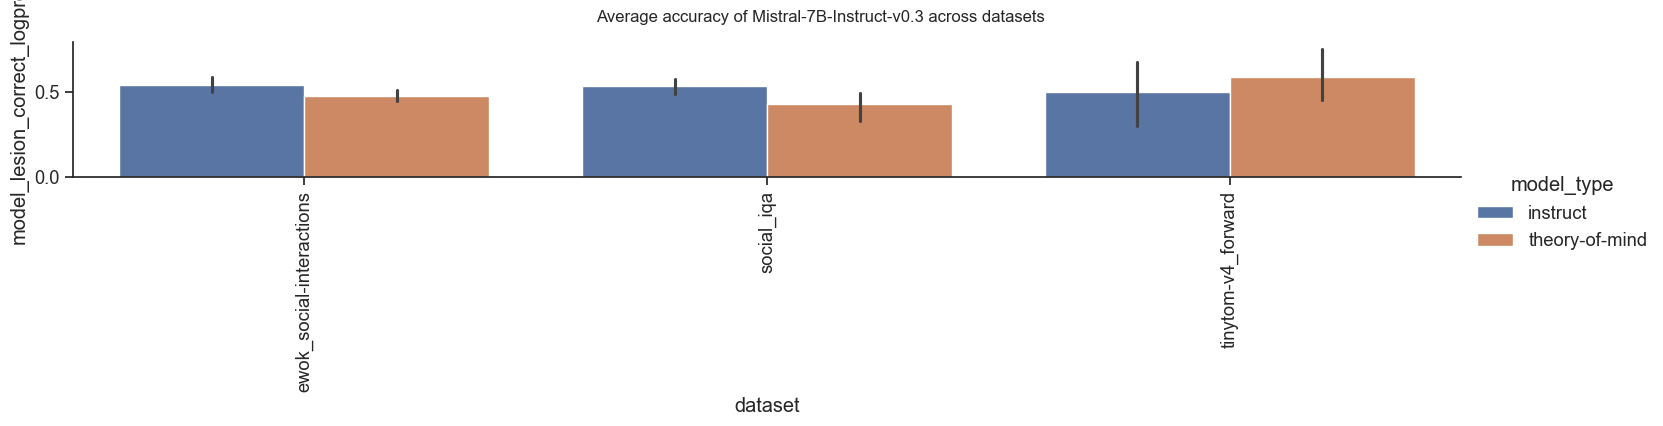

In [ ]:
g_mistral_byDataset = sns.catplot(
    data= merged, # merged_long
    x="dataset",
    y="model_lesion_correct_logprob",
    hue="model_type",
    kind="bar",
    height=2.5,
    aspect=6,
    # order x axis
    order=sorted(["bigtom_forward", "bigtom_backward", "emobench_application", "emobench_understanding_cause", "epitome_fb", "ewok_agent-properties", "ewok_social-interactions", "opentom_location_cg_fo", "social_iqa",  "hufloyd_indirectspeech",  "hufloyd_deceits",  "hufloyd_irony",  "hufloyd_metaphor", "pub_indirectness_classification", "imppres_presupposition", "imppres_implicature", "triangle-copa"]),
    # err_kws={"lw": 1}
)
ax = g_mistral_byDataset.axes[0, 0]
# Rotate x ticks
g_mistral_byDataset.set_xticklabels(rotation=90)
# Add a descriptive title
g_mistral_byDataset.fig.suptitle("Average accuracy of Mistral-7B-Instruct-v0.3 across datasets", fontsize=12)

# Adjust layout so the title doesn't overlap
plt.tight_layout()
plt.subplots_adjust(top=0.85)
# Add individual chance lines for each bar
x_coords = [p.get_x() + p.get_width() / 2 for p in ax.patches]
datasets = merged_long["dataset"].unique()

for x, dataset in zip(x_coords, datasets):
    chance = merged_long[merged_long["dataset"] == dataset]["chance_random"].iloc[0]
    # draw a short horizontal line across the width of one bar
    ax.hlines(y=chance, xmin=x - 0.2, xmax=x + 0.2, colors="k", linestyles="--", alpha=0.6)
    # ax.text(x, chance, f"{chance:.2f}", ha="center", va="bottom", fontsize=8, color="gray")

plt.show()

In [193]:
merged["accuracy"] = merged["model_lesion_correct_logprob"]

<Figure size 1000x600 with 0 Axes>

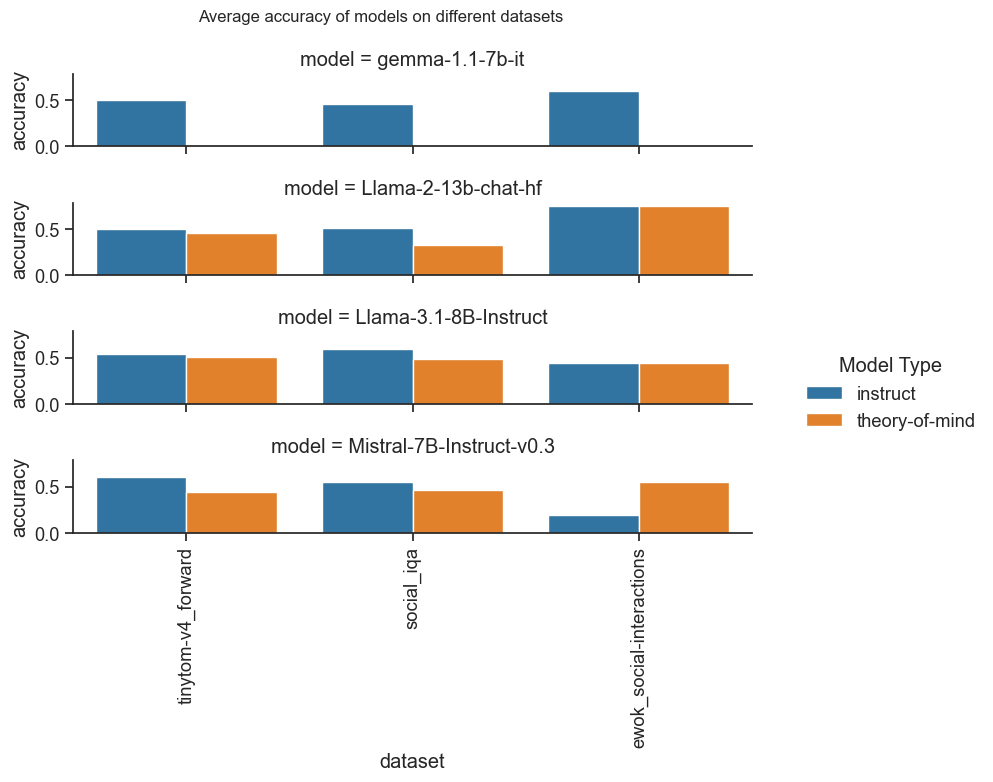

In [194]:
# figsize
plt.figure(figsize=(10, 6))

g_mistral_byDataset = sns.catplot(
    data=merged,
    x="dataset",
    y="accuracy",
    hue="model_type",
    col="model",
    col_wrap=1,                   # adjust # of columns as desired
    kind="bar",
    height=2,
    aspect=3,
    palette="tab10",
    # order model_type axis if needed:
    # order=sorted(merged["model_type"].unique()),
)

# rotate x-labels for readability
# g_mistral_byDataset.set_xticklabels(rotation=90)
g_mistral_byDataset.set_xticklabels([d for d in common_datasets], rotation=90)

# Main title
g_mistral_byDataset.fig.suptitle(
    "Average accuracy of models on different datasets",
    fontsize=12
)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
# ,move legend
sns.move_legend(
    g_mistral_byDataset,
    "center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    title="Model Type"
)

# --- Add chance lines per facet ---
# for ax, dataset in zip(g_mistral_byDataset.axes.flat, g_mistral_byDataset.col_names):

#     # retrieve chance value for this dataset
#     chance = merged.loc[merged["dataset"] == dataset, "chance"].iloc[0]

#     # horizontal line
#     ax.axhline(
#         y=chance,
#         linestyle="--",
#         color="black",
#         alpha=0.6,
#         linewidth=1
#     )

    # optionally annotate the chance value
    # ax.text(0.5, chance, f"{chance:.2f}", ha="center", va="bottom", fontsize=7)

plt.show()


In [43]:
# BLIMP results on mistral lesioned models
mistral_instruct_lesioned_blimp = pd.read_csv("../lesion_test_output/nyu-mll/blimp/Mistral-7B-Instruct-v0.3_network=language_perc=1.0_seed=42.csv")
mistral_base_lesioned_blimp = pd.read_csv("../lesion_test_output/nyu-mll/blimp/Mistral-7B-v0.3_network=language_perc=1.0_seed=42.csv")

In [45]:
mistral_instruct_lesioned_blimp["lesion_prediction_correct"].mean()

0.6063134328358208

In [46]:
mistral_base_lesioned_blimp["lesion_prediction_correct"].mean()

0.6103880597014926

In [244]:
" ".join(list(MODEL_MAP.keys()))

'allenai/OLMo-1B-0g724-hf allenai/OLMo-7B-0724-hf allenai/OLMo-7B-0724-Instruct-hf allenai/OLMo-2-1124-13B meta-llama/Llama-3.2-1B meta-llama/Llama-3.2-3B meta-llama/Llama-3.1-8B meta-llama/Llama-3.1-8B-Instruct meta-llama/Llama-3.1-70B meta-llama/Llama-3.3-70B-Instruct meta-llama/Llama-2-7b-hf meta-llama/Llama-2-7b-chat-hf meta-llama/Llama-2-13b-hf meta-llama/Llama-2-13b-chat-hf meta-llama/Llama-2-70b-hf meta-llama/Llama-2-70b-chat-hf EleutherAI/pythia-2.8b-deduped EleutherAI/pythia-1.4b-deduped EleutherAI/pythia-1b-deduped EleutherAI/pythia-6.9b-deduped EleutherAI/pythia-12b-deduped tiiuae/Falcon3-1B-Base tiiuae/Falcon3-1B-Instruct tiiuae/Falcon3-3B-Base tiiuae/Falcon3-3B-Instruct tiiuae/Falcon3-7B-Base tiiuae/Falcon3-7B-Instruct tiiuae/Falcon3-10B-Base tiiuae/Falcon3-10B-Instruct google/gemma-3-1b-pt google/gemma-3-1b-it google/gemma-3-4b-pt google/gemma-3-4b-it google/gemma-3-270m google/gemma-3-270m-it google/gemma-3-12b-pt google/gemma-3-12b-it google/gemma-3-27b-pt google/gemma-